# NFL Player Performance - Eksplorativna Analiza Podataka

Ovaj notebook predstavlja strukturiranu, kompletnu eksplorativnu analizu podataka za NFL igrače po pozicijama:

QB (quarterback), RB (running back), TE (tight end) i WR (wide receiver).

| Position | Data Source | Method |
|----------|-------------|--------|
| Quarterback | [Pro Football Reference](https://www.pro-football-reference.com) and [NFL Elo](https://www.nfeloapp.com/qb-rankings/) | Selenium web scraper and pre-built dataset |
| Running Back | [Pro Football Reference](https://www.pro-football-reference.com) | Selenium web scraper |
| Tight End | [Pro Football Reference](https://www.pro-football-reference.com) | Selenium web scraper |
| Wide Receiver | [HuggingFace / nflverse](https://huggingface.co/datasets/SebastianAndreu/24679_NFL_WR_Dataset_2025) | Pre-built dataset |

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "core"))

from notebook_setup import *
from notebook_setup import setup, dtype_summary
from missing_data import *
from goal_variable import *
from outliers import *
from awards import *
from corelations import *
from seasonal_trends import *
from year_analysis import *
setup()

In [2]:
datasets = load_datasets()
qb         = datasets["QB (qb_master)"]
rb         = datasets["RB (rb_master)"]
te         = datasets["TE (te_master)"]
wr_seasons = datasets["WR (wr_all_seasons)"]

Skupovi podataka uspesno ucitani:

  QB (qb_master)                                 845 redova  ×  188 kolona
  RB (rb_master)                                 622 redova  ×  115 kolona
  TE (te_master)                                 351 redova  ×   70 kolona
  WR (wr_all_seasons)                           5529 redova  ×  102 kolona


- QB skup ima 845 redova i 188 kolona - najveći broj feature-a zbog kombinacije standardnih sezonskih statistika, naprednih passing metrika, ELO rejting komponenti i snap count podataka. Svaki red = jedna sezona jednog QB-a.
- RB skup ima 622 redova i 115 kolona - uključuje rushing i receiving statistike, napredne metrike poput broken tackles i YBC/YAC, te defensive i snap count kolone.
- TE skup je najmanji sa 351 reda i 70 kolona - fokusiran na receiving i rush statistike tight end-ova.
- WR Seasons je najobimniji skup sa 5.529 redova i 102 kolone - prikupljen iz nflverse/nflfastR izvora i sadrži kontekstualne varijable (situacione metrike, VP sekcije, vremenske uslove).

In [3]:
for name, df in datasets.items():
    print(f"{'_'*70}")
    print(f"  {name}")
    display(df.head(3))

______________________________________________________________________
  QB (qb_master)


,Player,PlayerID,Season,Age,Team,Pos,G,GS,QBrec,Cmp,Att,Cmp%,Yds,TD,TD%,Int,Int%,1D,Succ%,Lng,Y/A,AY/A,Y/C,Y/G,Rate,...,elo_QB Elo,elo_QBR,elo_Rushing,elo_Sacks,elo_Sacks.1,elo_Starts,elo_Success,elo_T,elo_TD%,elo_TD%-INT%,elo_TDs,elo_TDs.1,elo_Total,elo_Total WPA,elo_W,elo_WPA / DB,elo_YAC,elo_YPA,elo_YPC,elo_Yards,elo_Yards.1,elo_aDOT,elo_vs Sticks,Team_Changed,Prev_Season_Yds
0,Josh Allen,AlleJo02,2018,22,BUF,QB,12,11,5-6-0,169,320,52.80,2074,10,3.10,12,3.80,89,37.10,75.00,6.50,5.42,12.30,172.80,67.90,...,136.35,49.80,0.07,28.00,0.01,11.00,0.43,0.00,0.03,-0.01,10.00,8.00,2.33,-0.18,5.00,-0.00,-0.08,6.41,7.86,2044.00,637.00,11.00,1.37,0,0.00
1,Josh Allen,AlleJo02,2019,23,BUF,QB,16,16,10-6-0,271,461,58.80,3089,20,4.30,9,2.00,146,41.70,53.00,6.70,6.69,11.40,193.10,85.30,...,157.14,49.40,0.03,38.00,0.01,16.00,0.45,0.00,0.04,0.02,20.00,9.00,30.56,1.08,10.00,0.00,-0.07,6.74,5.54,3089.00,521.00,9.31,0.02,0,2074.00
2,Josh Allen,AlleJo02,2020,24,BUF,QB,16,16,13-3-0,396,572,69.20,4544,37,6.50,10,1.70,228,56.50,55.00,7.90,8.45,11.50,284.00,107.20,...,294.01,76.60,0.01,26.00,0.04,16.00,0.56,0.00,0.06,0.05,37.00,8.00,207.25,5.30,13.00,0.01,0.01,7.94,5.65,4544.00,441.00,8.49,-0.67,0,3089.00


______________________________________________________________________
  RB (rb_master)


,Player,PlayerID,Season,Age,Team,Lg,Pos,G,GS,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,Rush_Succ%,Rush_Lng,Rush_Y/A,Rush_Y/G,Rush_A/G,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,Rec_Succ%,...,def_FR_TD,def_FR_Yds,def_Fmb,def_PD,def_QBHits,def_Sfty,def_Sk,def_Solo,def_TFL,def_Tkl_Ast,def_Tkl_Comb,def_Tkl_Solo,def_safety_md,def_tackles_loss,snp_Def%,snp_Def_Snaps,snp_Off%,snp_Off_Snaps,snp_ST%,snp_ST_Snaps,snp_defense,snp_offense,snp_special_teams,Team_Changed,Prev_Season_Yds
0,Alvin Kamara,KamaAl00,2017,22,NOR,NFL,RB,16,3,120,728,8,42,50.80,74.00,6.10,45.50,7.50,100,81,826,10.20,5,38,NaN,...,NaN,NaN,1.00,0.00,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.00
1,Alvin Kamara,KamaAl00,2018,23,NOR,NFL,RB,15,13,194,883,14,57,58.20,49.00,4.60,58.90,12.90,105,81,709,8.80,4,31,NaN,...,NaN,NaN,1.00,0.00,0.00,NaN,0.00,0.00,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,728.00
2,Alvin Kamara,KamaAl00,2019,24,NOR,NFL,RB,14,9,171,797,5,32,50.90,40.00,4.70,56.90,12.20,97,81,533,6.60,1,28,NaN,...,NaN,NaN,4.00,0.00,0.00,NaN,0.00,0.00,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,883.00


______________________________________________________________________
  TE (te_master)


,Player,PlayerID,Season,Age,Team,Pos,G,GS,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,Rec_Succ%,Rec_Lng,Rec/G,Rec_Y/G,Catch%,Rec_Y/Tgt,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,Rush_Y/G,...,adv_Rec_PassRtg,adv_Rec_YAC,adv_Rec_YAC/R,adv_Rec_YBC,adv_Rec_YBC/R,adv_Rec_Yds,adv_Rec_aDOT,adv_Rush_1D,adv_Rush_Att,adv_Rush_Att/Br,adv_Rush_BrkTkl,adv_Rush_BrkTkl/A,adv_Rush_YAC,adv_Rush_YAC/A,adv_Rush_YBC,adv_Rush_YBC/A,adv_Rush_Yds,snp_Def%,snp_Def_Snaps,snp_Off%,snp_Off_Snaps,snp_ST%,snp_ST_Snaps,Team_Changed,Prev_Season_Yds
0,Cade Otton,OttoCa00,2022,23,TAM,TE,16,11,65,42,391,9.30,2,23,52.30,35.00,2.60,24.40,64.60,6.00,0,0,0,0,0.00,...,91.20,174.00,4.10,NaN,NaN,391.00,4.90,0.00,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0%,0.00,70%,803.00,25%,107.00,0,0.00
1,Cade Otton,OttoCa00,2023,24,TAM,TE,17,17,67,47,455,9.70,4,27,49.30,27.00,2.80,26.80,70.10,6.80,0,0,0,0,0.00,...,102.50,223.00,4.70,NaN,NaN,455.00,6.70,0.00,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0%,0.00,97%,1064.00,1%,4.00,0,391.00
2,Cade Otton,OttoCa00,2024,25,TAM,TE,14,14,87,59,600,10.20,4,33,51.70,44.00,4.20,42.90,67.80,6.90,1,-4,0,0,-0.30,...,88.30,311.00,5.30,NaN,NaN,600.00,5.50,0.00,1.00,NaN,1.00,1.00,0.00,0.00,-4.00,-4.00,-4.00,0%,0.00,92%,856.00,0%,1.00,0,455.00


______________________________________________________________________
  WR (wr_all_seasons)


,receiver_player_id,receiver_player_name,season,games_played,posteam,targets,receptions,receiving_yards,air_yards,yac,tds,red_zone_targets,end_zone_targets,third_down_targets,fourth_down_targets,high_leverage_targets,explosive_plays,first_downs,second_and_long_targets,third_and_medium_targets,lost_yards_due_to_penalty,yards_Q1,yards_Q2,yards_Q3,yards_Q4,...,leading_pct,wp_var,target_share_std,temp_f,humidity_pct,wind_mph,success_rate,big_play_rate,reception_std,avg_start_yardline,avg_target_depth_vs_qb,pregame_spread,pregame_total,passer_player_id,surface,is_dome,is_rain,is_snow,is_clear,defteam,home_team,away_team,player_team,team_changed,prev_season_rec_yds
0,00-0033908,C.Kupp,2017,16,14,107.00,70.00,938.00,916.00,373.00,6.00,26,0,39,1,51,12.00,46.00,24.00,13.00,0.00,220.00,366.00,130.00,222.00,...,0.88,0.03,0.08,55.06,50.62,3.81,0.66,0.13,9.69,42.99,0.10,1.00,45.75,00-0033106,2.50,0.06,0.12,0.00,0.88,18.56,9.88,8.69,LA,0,0.00
1,00-0033908,C.Kupp,2018,8,0,55.00,40.00,566.00,460.00,303.00,6.00,11,0,14,0,18,9.00,25.00,7.00,2.00,0.00,113.00,220.00,139.00,94.00,...,0.86,0.02,0.11,67.50,56.00,6.00,0.64,0.15,11.46,48.03,-1.18,1.94,49.69,00-0033106,2.38,0.12,0.12,0.00,0.88,18.25,9.75,8.50,LA,0,938.00
2,00-0033908,C.Kupp,2019,16,5,135.00,94.00,1161.00,970.00,538.00,10.00,22,0,51,1,60,21.00,52.00,31.00,19.00,0.00,170.00,441.00,290.00,260.00,...,0.87,0.02,0.13,68.31,50.62,5.00,0.68,0.16,9.01,46.07,-0.99,1.75,47.78,00-0033106,2.38,0.00,0.00,0.00,1.00,14.75,6.81,7.94,LA,0,566.00


### Opis pojedinih kolona po skupu podataka

---

#### QB 

| Kolona | Opis |
|--------|------|
| `Player` / `Season` | Identifikacija igrača i sezone |
| `G` / `GS` | Odigrane utakmice / startovi |
| `Cmp` / `Att` / `Cmp%` | Kompletirana dodavanja / pokušaji / procenat |
| `Yds` / `TD` / `Int` | Passing jardi / touchdowni / interceptions |
| `Y/A` | Jardi po pokušaju |
| `Rate` | NFL Passer Rating |
| `QBR` | ESPN Total QBR (0-100, napredna metrika) |
| `adv_pass_*` | Napredne passing metrike (air yards, pressure, play-action itd.) |
| `elo_*` | ELO rejting komponente (CPOE, WPA, rushing itd.) |
| `snp_Off%` | Procenat offensive snapova |

---

#### RB 

| Kolona | Opis |
|--------|------|
| `Player`  / `Season` | Identifikacija igrača i sezone |
| `Rush_Att` / `Rush_Yds` / `Rush_TD` | Rushing pokušaji / jardi / touchdowni |
| `Rush_Y/A` | Jardi po pokušaju (yards per carry) |
| `Rec` / `Rec_Yds` / `Rec_TD` | Receiving statistike |
| `Scrimmage_Yds` / `Touches` | Ukupni jardi i dodiri lopte (rush + rec) |
| `adv_Rush_BrkTkl` | Broken tackles |
| `adv_Rush_YBC` / `adv_Rush_YAC` | Yards before/after contact |


---

#### TE 

| Kolona | Opis |
|--------|------|
| `Player`  / `Season` | Identifikacija igrača i sezone |
| `G` / `GS` | Odigrane utakmice / startovi |
| `Tgt` / `Rec` / `Rec_Yds` / `Rec_TD` | Targeti / hvatanja / jardi / touchdowni |
| `Rec_Y/R` | Jardi po hvatanju |
| `catch_pct` | Procenat uhvacenih targeta |
| `adv_ADOT` | Average Depth of Target (prosecna dubina targeta) |
| `adv_Rec_YAC` / `adv_Rec_YBC` | Yards after catch / yards before contact |

---

#### WR Seasons

| Kolona | Opis |
|--------|------|
| `receiver_player_name` / `season` | Identifikacija igrača i sezone |
| `targets` / `receptions` / `receiving_yards` / `tds` | Osnovne receiving statistike |
| `catch_rate` / `target_share` | Efikasnost i udeo u timskim targetima |
| `adot` | Average Depth of Target (prosecna dubina targeta) |
| `air_yards` / `yac` | Air jardi i yards after catch |
| `epa` / `wpa` | Expected Points Added / Win Probability Added |
| `red_zone_targets` | Targeti u red zone |
| `temp_f` / `wind_mph` / `surface` | Vremenski uslovi i tip terena |
| `yards_Q1/Q2/Q3/Q4` / `receptions_Q1/.../Q4` | Situacioni splitovi po kvartalu i win probability bucketima |
| `pregame_spread` / `pregame_total` | Kontekstualni podaci - spread, total |

In [4]:
display(dtype_summary(datasets))

,float64,int64,object
QB,163,16,9
RB,91,15,9
TE,43,19,8
WR,81,17,4


- Većina kolona su tipa `float64` - numeričke statistike sa mogućim `NaN` vrednostima.
- Kategorijske kolone poput `Player`, `Team`, `PlayerID`, `surface`, `awards` itd. su tipa `object` (string).

---
## Analiza Nedostajućih Vrednosti

Pregled ukupnog broja i procenta `NaN` vrednosti po skupu podataka, kao i vizualizacija kolona s najviše nedostajućih vrednosti.

In [5]:
display(null_summary(datasets))

,Skup,Ukupno ćelija,Null ćelija,Null %,Kolona s nullovima,Ukupno kolona
0,QB,158860,57521,36.21,167,188
1,RB,71530,33089,46.26,92,115
2,TE,24570,7085,28.84,46,70
3,WR,563958,0,0.00,0,102


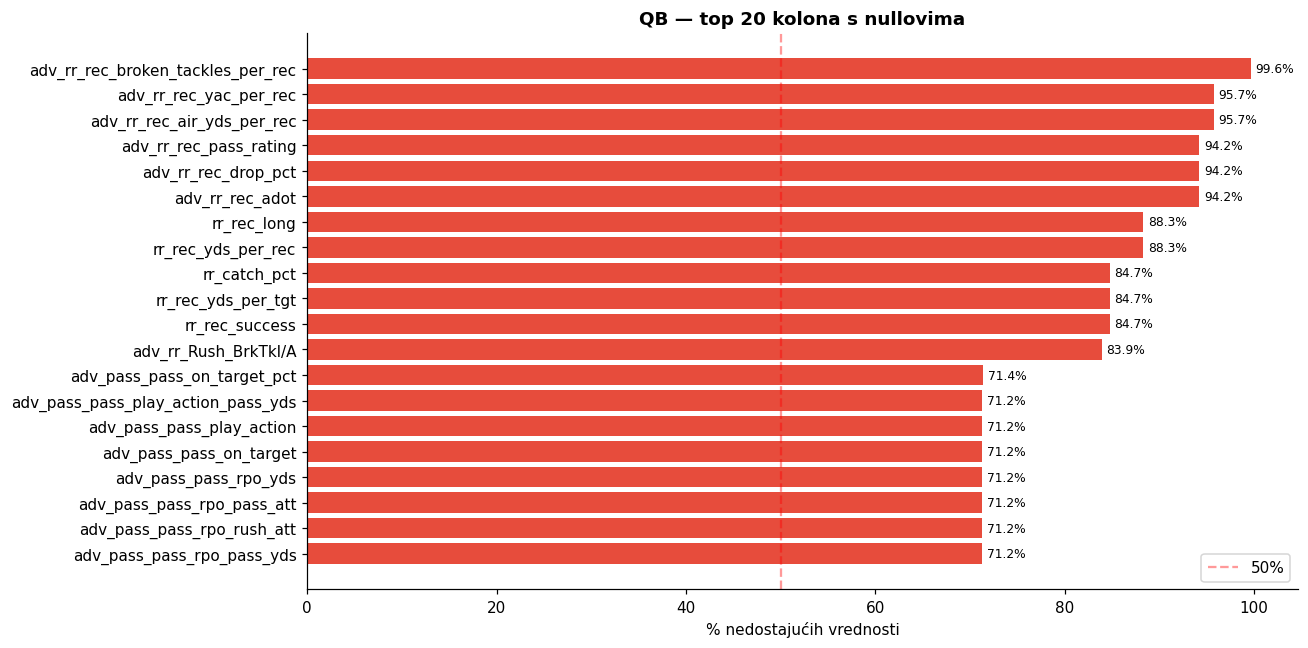

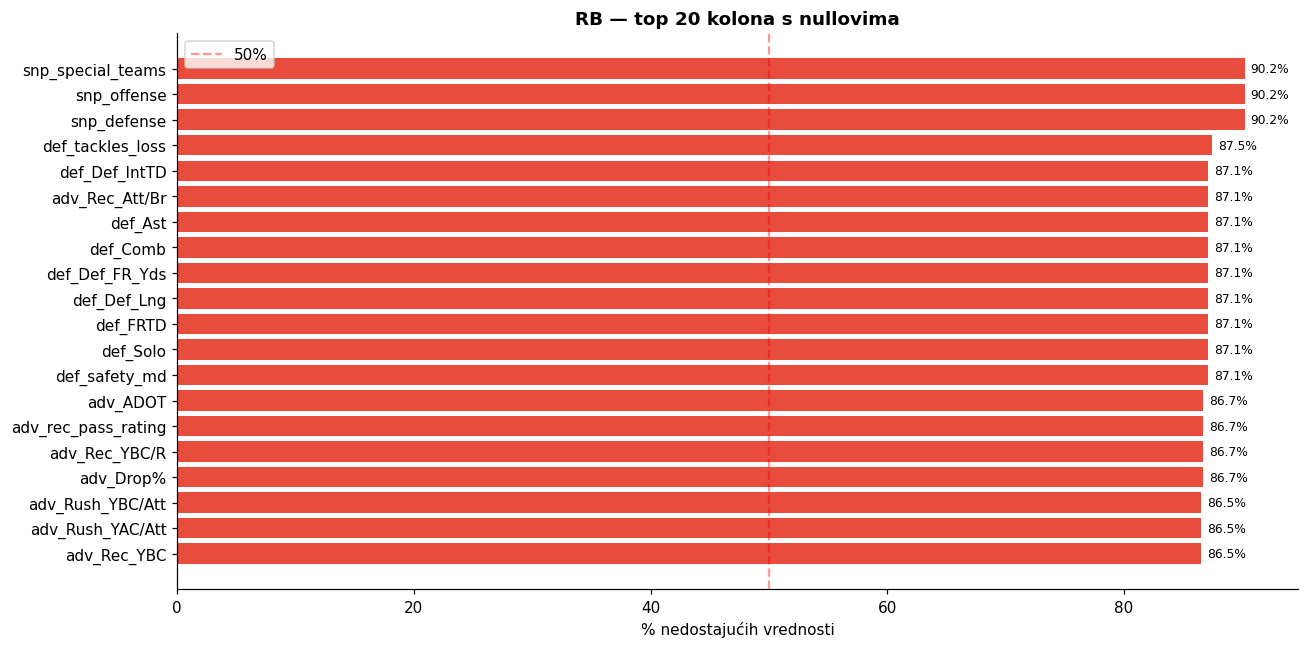

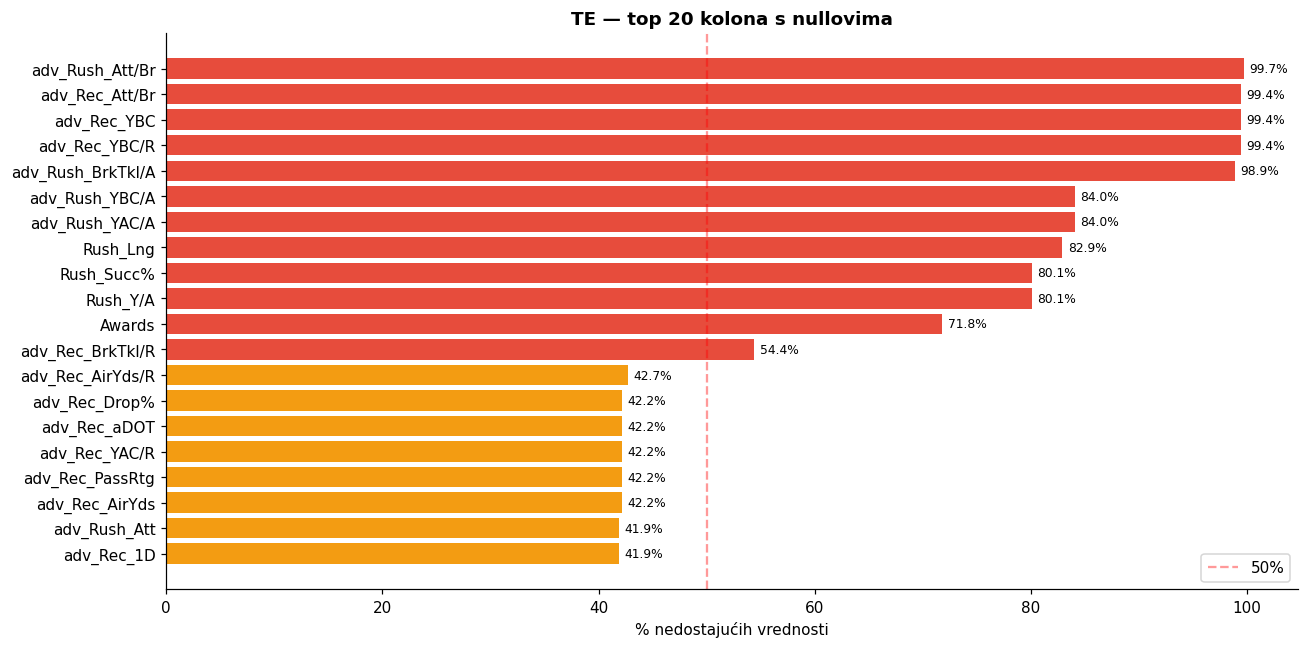

WR: nema nedostajućih vrednosti.


In [6]:
for name, df in datasets.items():
    plot_missing(df, name.split("(")[0].strip())

Visok procenat null vrednosti u ovim kolonama nije greška u podacima - to je posledica prirode same pozicije. Statistike koje za neku poziciju gotovo i ne postoje jednostavno neće biti popunjene.


 Na primer, QB skupu kolone poput `adv_rr_rec_drop_pct` ili `adv_rr_rec_yac_per_rec` odnose se na receiving metrike - QB praktično nikad nije targetovan kao receiver, pa su te vrednosti null.


Ove kolone su u skupu podataka prisutne jer se koristi isti šablon kolekcije podataka za sve igrače, ali pri modeliranju će biti isključene ili ignorisane kao nebitne za predviđanje performansi te pozicije.

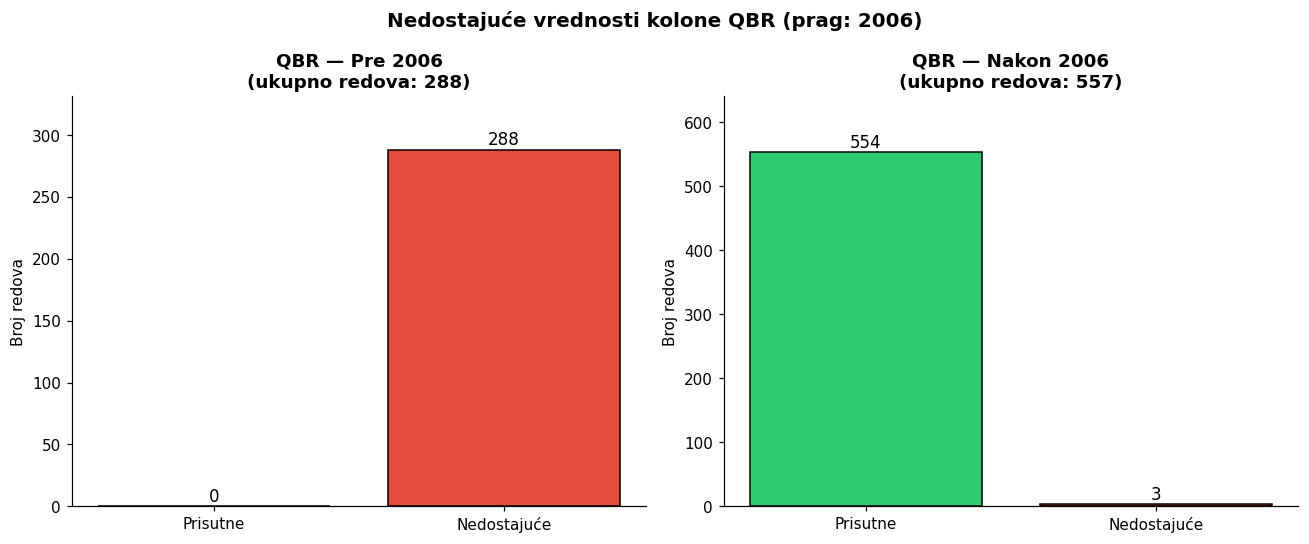

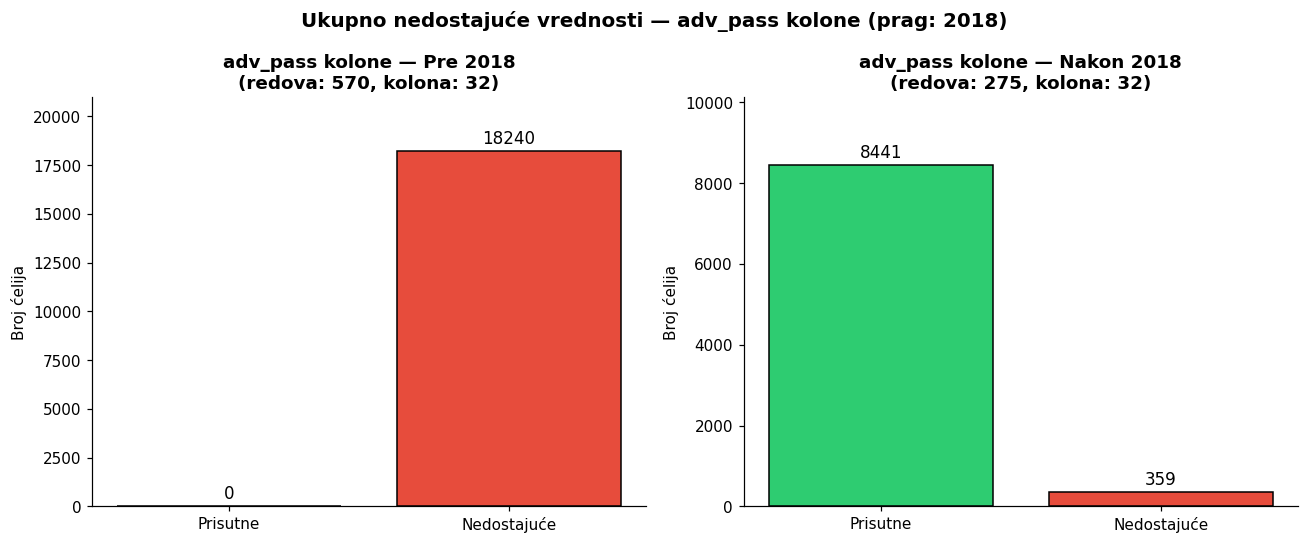

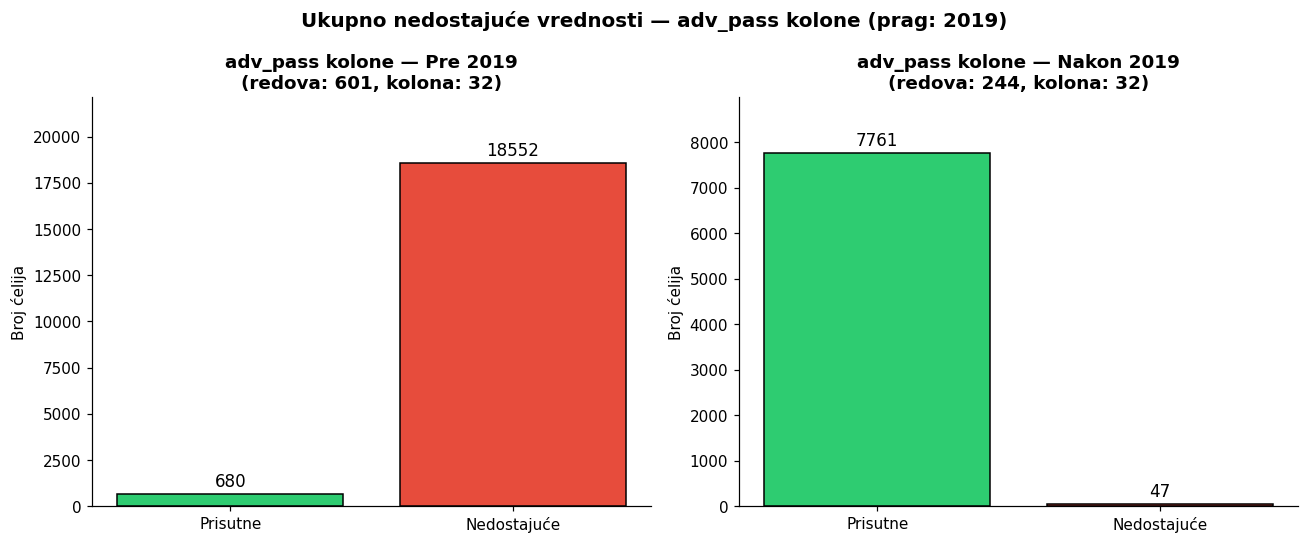

In [7]:
adv_pass_cols = [c for c in qb.columns if c.startswith("adv_pass")]

plot_col_missing_by_year(qb, col="QBR", threshold=2006)
plot_col_group_missing_by_year(qb, cols=adv_pass_cols, threshold=2018, group_label="adv_pass")
plot_col_group_missing_by_year(qb, cols=adv_pass_cols, threshold=2019, group_label="adv_pass")



QBR (prag: 2006)

ESPN Total QBR metrika uvedena je 2006. godine, što objašnjava zašto svih 288 QB sezona pre 2006. nema QBR vrednost (100% null). Nakon 2006. samo 3 od 557 redova nemaju QBR. Ovo je strukturalni nedostatak podataka uslovljen datumom uvođenja metrike, a ne greškom u prikupljanju.

---
adv_pass kolone (prag: 2018)

Pro Football Reference je 2018. godine uveo prvi set naprednih passing statistika (`adv_pass` kolone). Pre te godine nijedna od ovih kolona nije postojala, pa je prisutnost podataka za sezone pre 2018. ravna 0% - svi redovi su null. Nakon 2018. većina `adv_pass` kolona je popunjena, što potvrđuje da se radi o strukturalnom nedostatku vezanom za datum uvođenja metrika, a ne o greškama u prikupljanju.

---
adv_pass kolone (prag: 2019)

Iako su napredne passing statistike uvedene 2018., skup kolona je proširen 2019. godine dodatnim metrikama. Kolone poput play action yards, play action attempts, run-pass option (RPO) attempts i yards, on-target throws, on-target throw % i druge nisu postojale u sezoni 2018. i počele su se bežiti tek od 2019. To objašnjava zašto grafik s pragom 2019. pokazuje još manji broj nedostajućih vrednosti  - jer su sve `adv_pass` kolone (uključujući i one dodane 2019.) tada potpuno dostupne, dok u sezoni 2018. te novije kolone još uvek imaju null vrednosti.


---
## Distribucija ciljnih varjiabli

Sledi provera distribucije ciljnih varijabli za QB, RB, TE i WR pozicije kroz sva četiri skupa, kako bismo imali uvid u raspodelu podataka pre modelovanja.

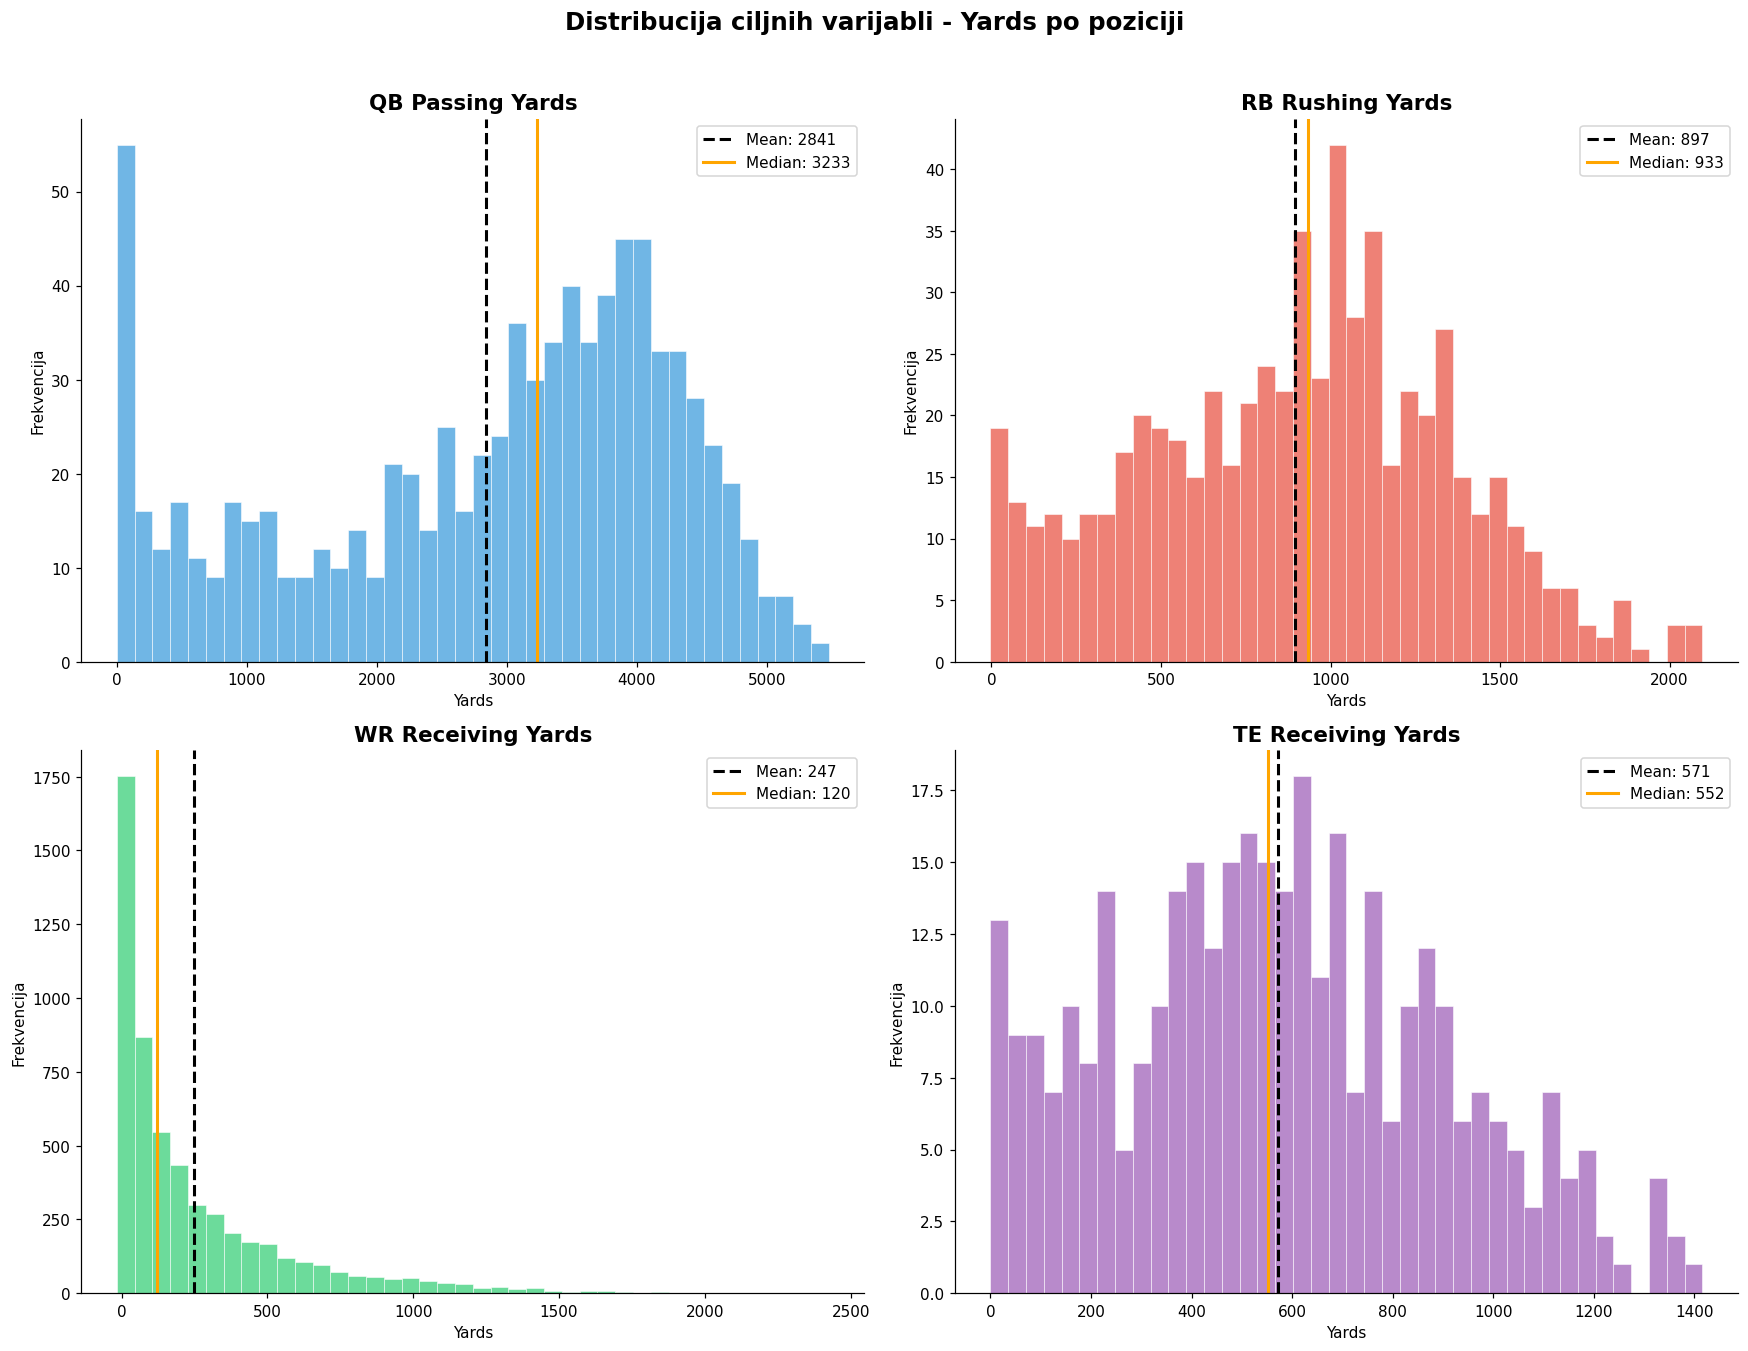

In [8]:
plot_data = [
    (qb,         "Yds",              "QB Passing Yards",   "#3498db"),
    (rb,         "Rush_Yds",         "RB Rushing Yards",   "#e74c3c"),
    (wr_seasons, "receiving_yards",  "WR Receiving Yards", "#2ecc71"),
    (te,         "Rec_Yds",          "TE Receiving Yards", "#9b59b6"),
]
plot_target_dist(datasets, plot_data)

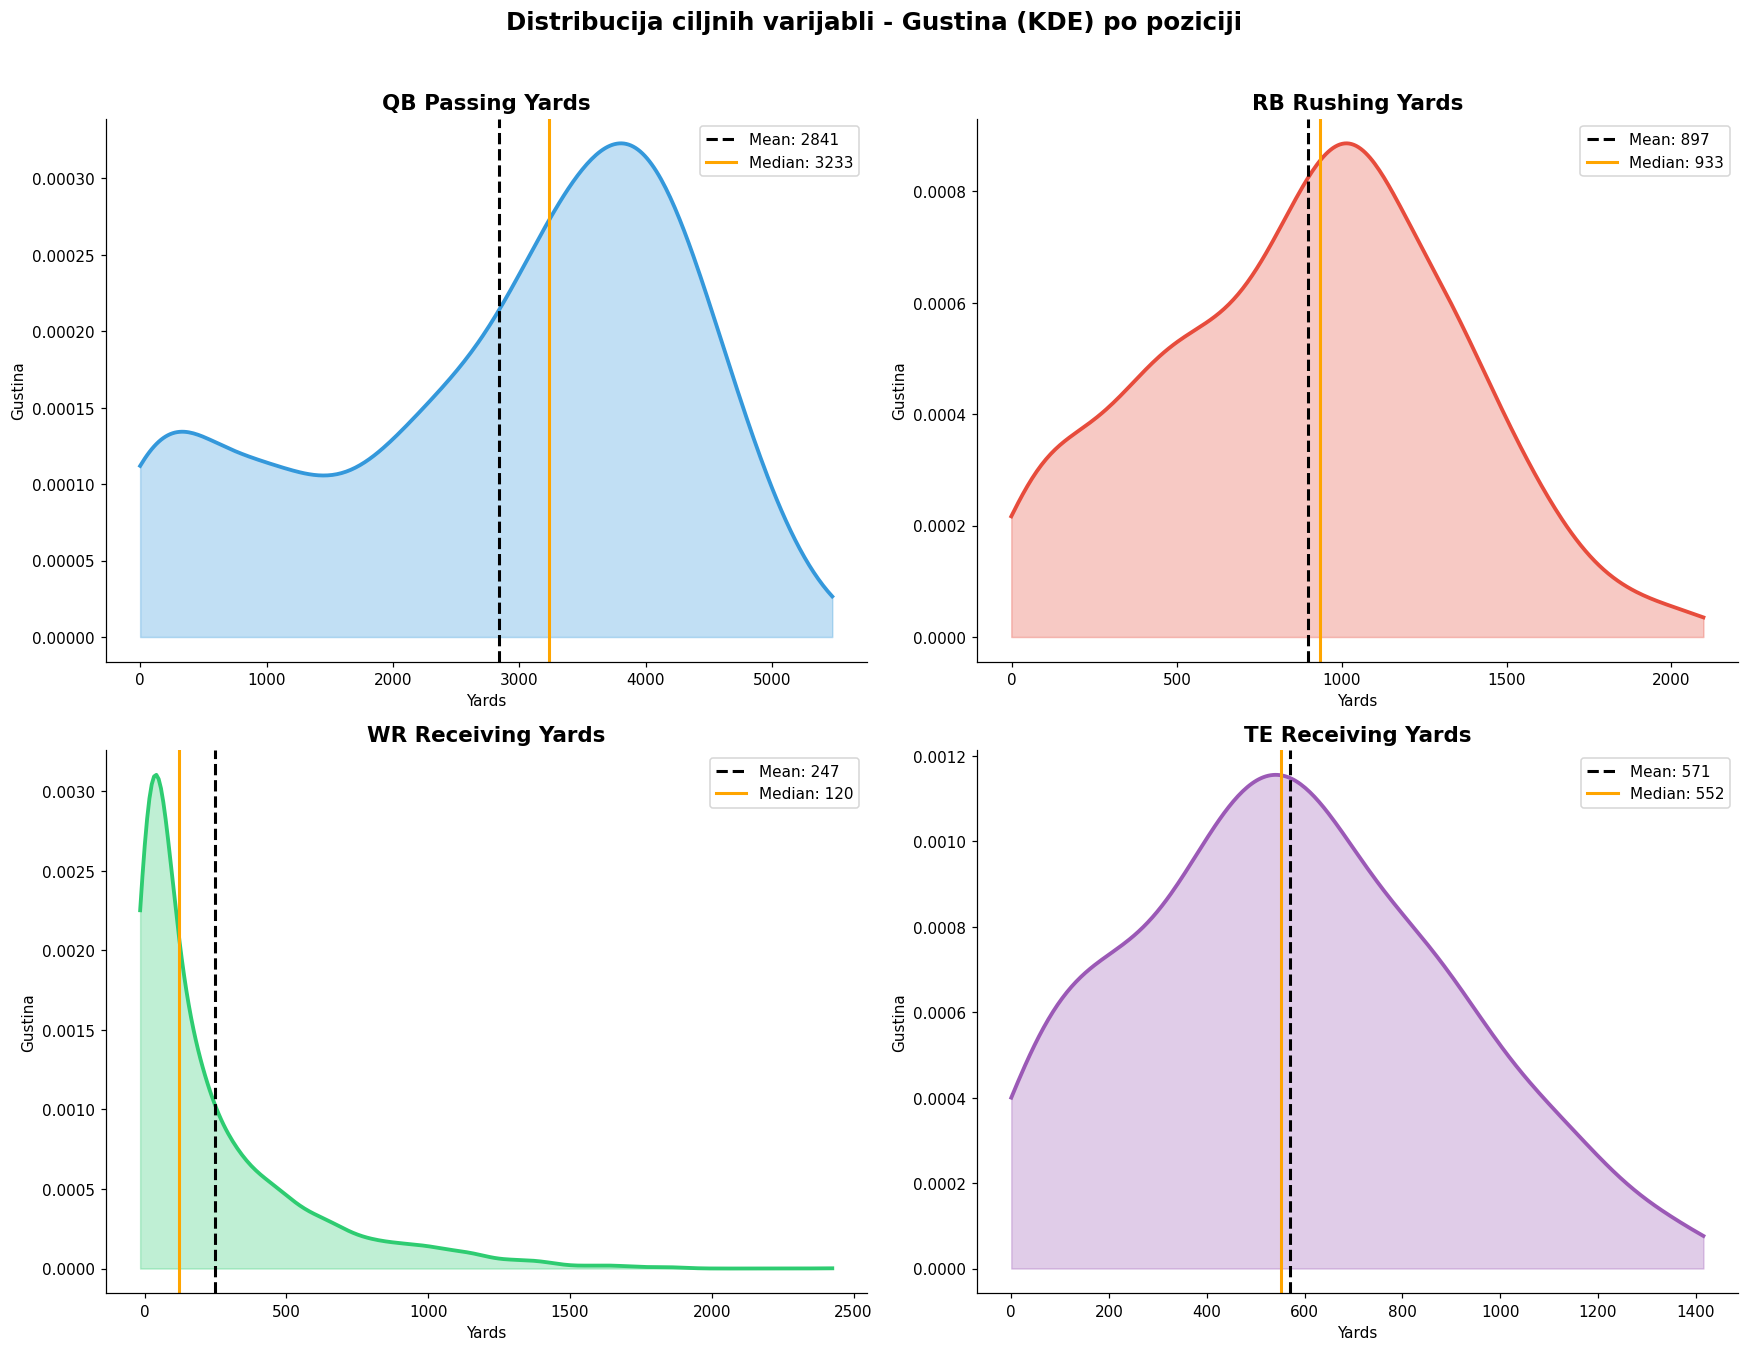

In [9]:
plot_data = [
    (qb,         "Yds",             "QB Passing Yards",   "#3498db"),
    (rb,         "Rush_Yds",        "RB Rushing Yards",   "#e74c3c"),
    (wr_seasons, "receiving_yards", "WR Receiving Yards", "#2ecc71"),
    (te,         "Rec_Yds",         "TE Receiving Yards", "#9b59b6"),
]

plot_target_kde(plot_data)

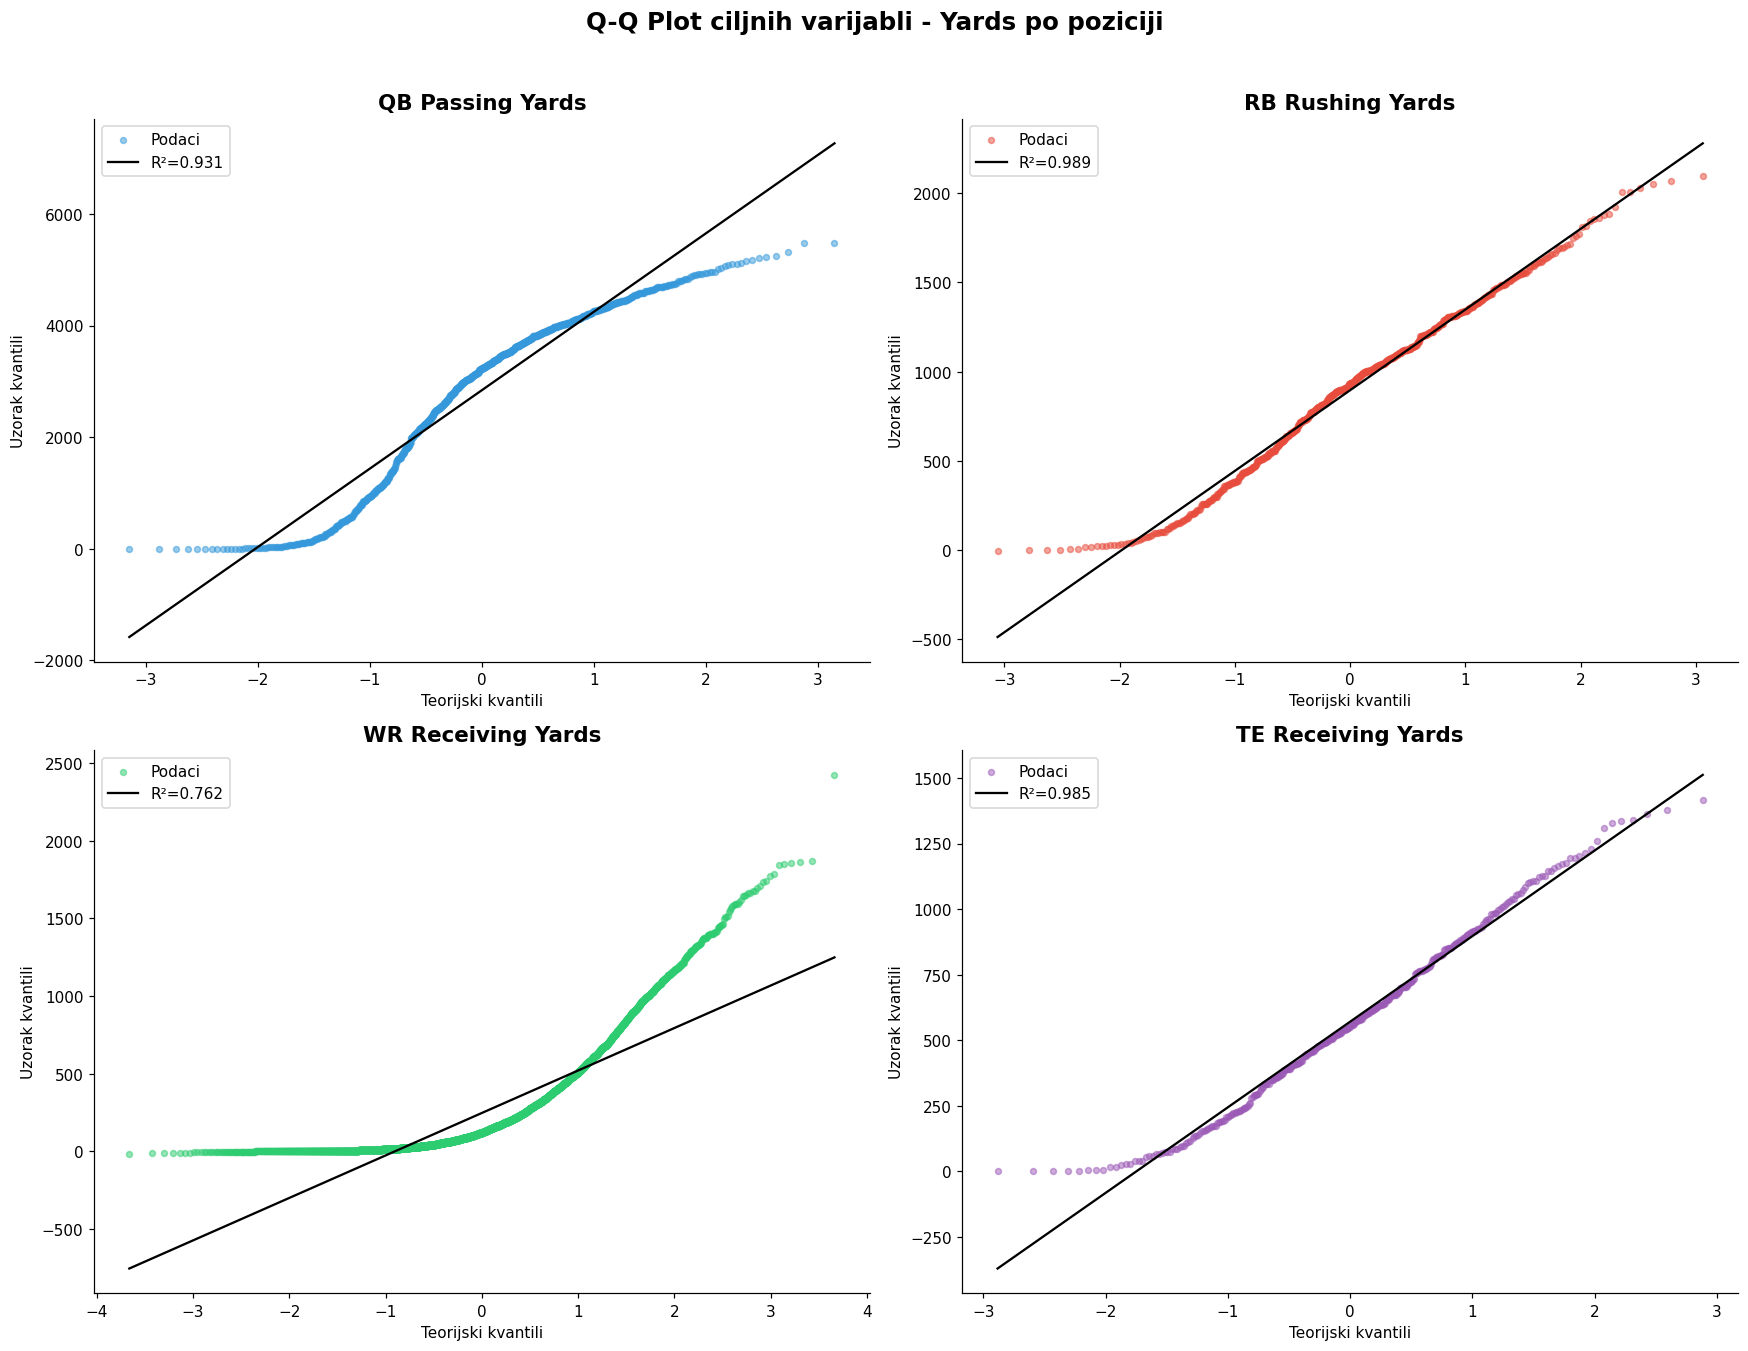

In [10]:
plot_data = [
    (qb,         "Yds",             "QB Passing Yards",   "#3498db"),
    (rb,         "Rush_Yds",        "RB Rushing Yards",   "#e74c3c"),
    (wr_seasons, "receiving_yards", "WR Receiving Yards", "#2ecc71"),
    (te,         "Rec_Yds",         "TE Receiving Yards", "#9b59b6"),
]
plot_target_qq(plot_data)

### Analiza distribucije ciljnih varijabli



RB (Rushing Yards) i TE (Receiving Yards) pokazuju približno normalnu distribuciju - većina igrača se grupiše oko proseka, sa simetričnim repovima. Q-Q plotovi to potvrđuju visokim R² vrednostima (RB ≈ 0.99, TE ≈ 0.98), što znači da su ove varijable pogodne za linearnu regresiju bez transformacija.


QB (Passing Yards) pokazuje bimodalnu distribuciju - pored glavnog vrha (starteri sa 2500-4500 jardi), postoji sekundarni vrh blizu 0-500 jardi. Ovaj drugi vrh nastaje zbog backup QB-ova i igrača koji su se povredili, pa imaju jako mali broj odigranih utakmica. Bez tih zapisa, distribucija bi bila približno normalna. Ovim outlierima ćemo se posvetiti u sekciji za obradu outliera.

WR (Receiving Yards) ima izrazito desno nagnutu (right-skewed) distribuciju - veliki broj igrača sa minimalnom ulogom (mali broj targeta, malo jardi) i mali broj elitnih receivera koji akumuliraju ogromne jardaže. Ovo je tipičan power-law obrazac u sportu. Mean je značajno veći od medijana, što potvrđuje pozitivni skew. Za modelovanje, primenjujemo logaritamsku transformaciju kako bismo normalizovali distribuciju.

| Pozicija | Tip distribucije | Predvidivost (Normalnost) | Ključna karakteristika |
|----------|-------------------|---------------------------|------------------------|
| QB | Bimodalna | Srednja (R²≈0.93) | Jasna podela na startere i rezerve |
| RB | Normalna | Visoka (R²≈0.99) | Najstabilnija varijabla za linearnu regresiju |
| WR | Power-law / Skewed | Niska (R²≈0.76) | Veliki jaz između elite i ostatka lige |
| TE | Normalna  | Visoka (R²≈0.98) | Konzistentan učinak većine igrača |


Sledi prikaz Pareto krive (power law) za wr data set. 

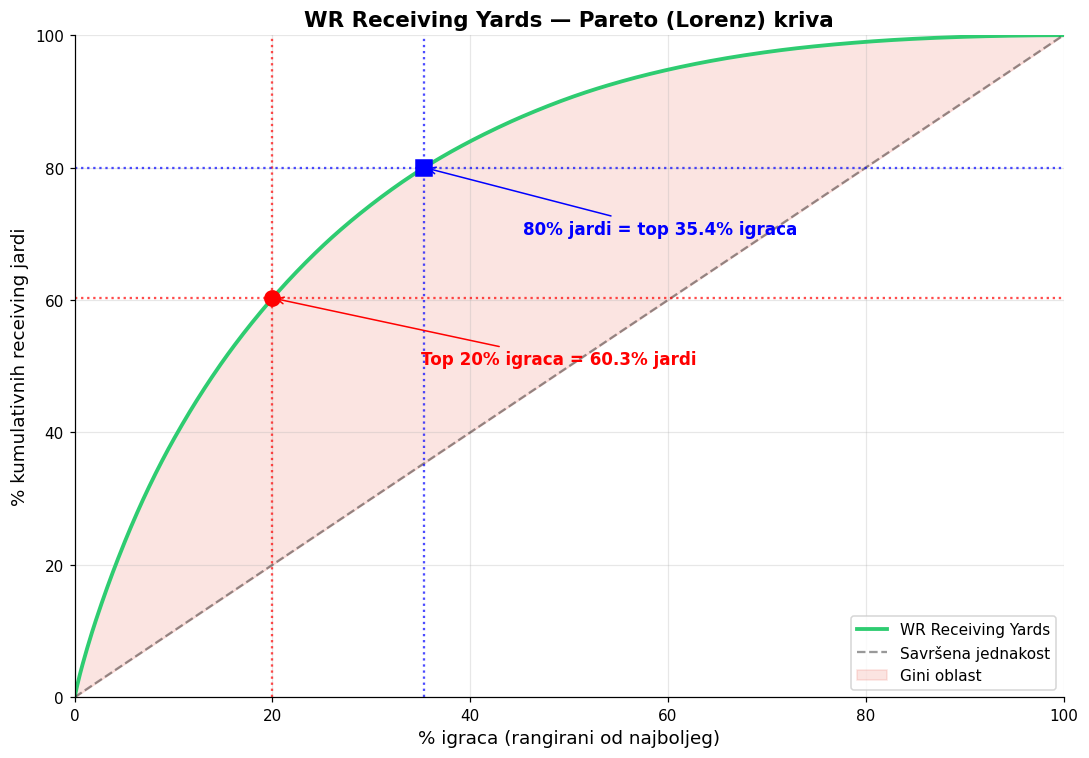

In [11]:
plot_pareto_lorenz(wr_seasons)

Lorenzova kriva potvrđuje izrazitu nejednakost u WR produkciji: top 20% receivera akumulira oko 60% svih receiving jardi, dok je za 80% ukupne jardaže dovoljno samo oko 35% najboljih igrača. Velika površina između krive i linije savršene jednakosti (Gini oblast) ukazuje na visok Gini koeficijent, što znači da mali broj elitnih receivera dominira metrikom, dok većina igrača (donjih 60-70%) ima zanemariv doprinos. 

Ovo nije tačan Pareto odnos 80/20, ali je veoma blizu i tipično je za visokokonkurentne sisteme poput profesionalnog sporta. Za modelovanje, to znači da će predviđanja biti precizna za igrače u gornjem delu distribucije, ali nepouzdana za igrače van top 35% - što opravdava primenu log transformacije.


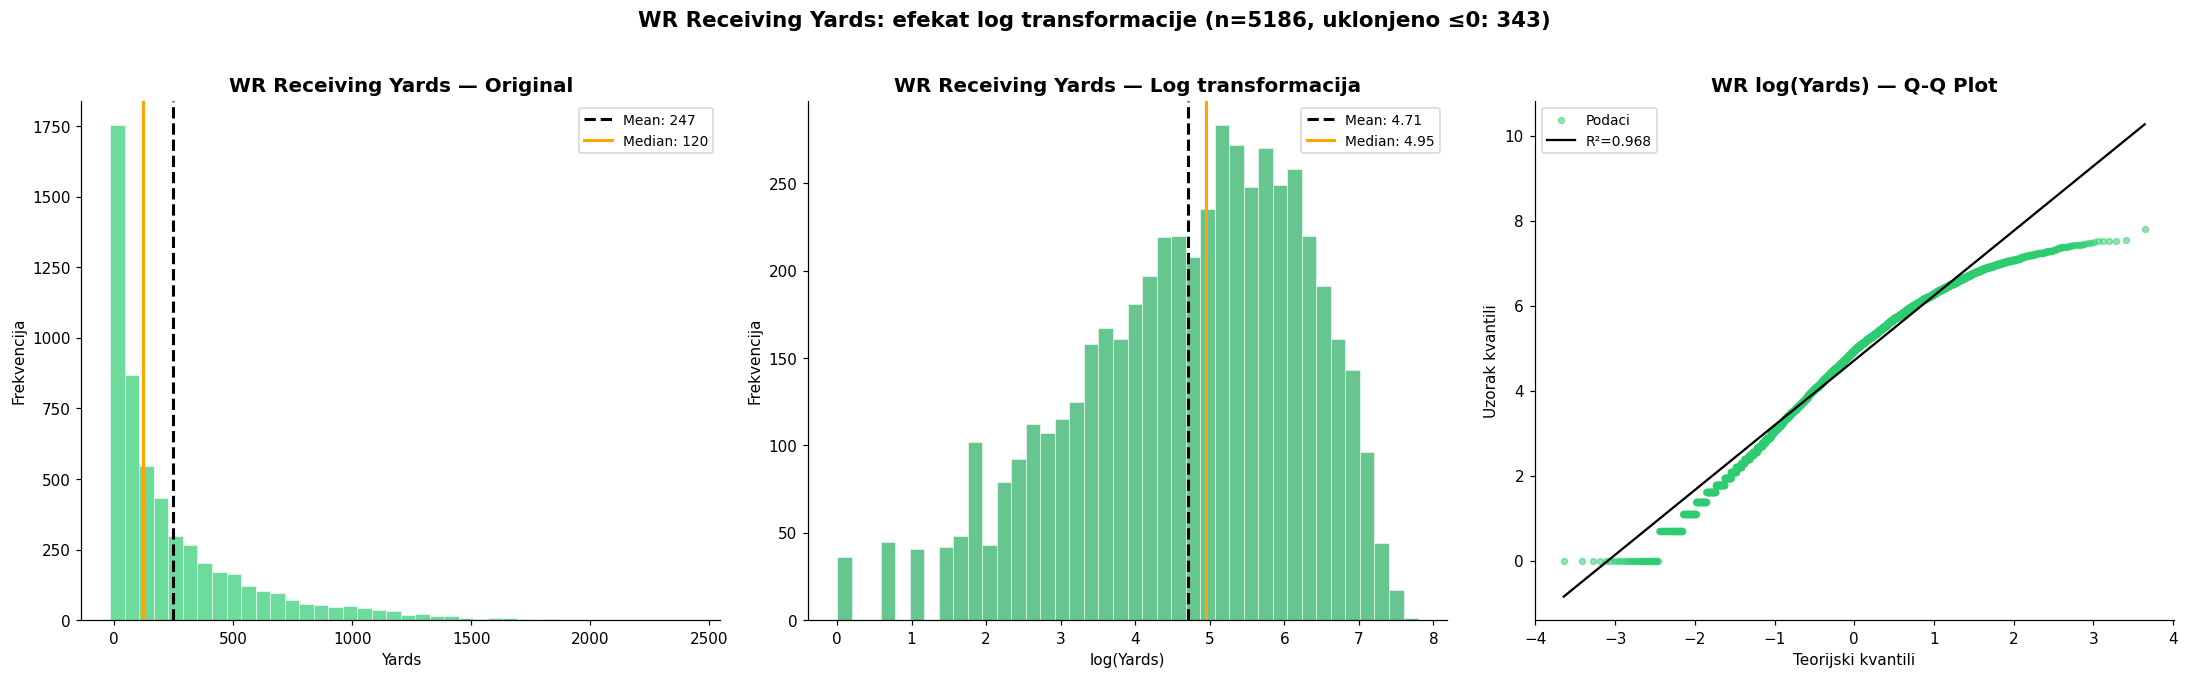

R² pre:   0.762
R² nakon: 0.968


In [12]:
plot_wr_log_transform(wr_seasons)


---
## Analiza i Tretman Outliera

### 1. Detekcija outliera - Z-score vs IQR (sirove ukupne yarde)

Primjenjujemo dve klasične metode na ukupne sezonske jarde svake pozicije:
- Z-score: outlier ako |z| > 3 (više od 3 standardne devijacije od proseka).
- IQR: outlier ako je vrednost ispod Q1 − 1.5·IQR ili iznad Q3 + 1.5·IQR.

In [13]:
outlier_targets = {
    "QB": (qb,         "Yds"),
    "RB": (rb,         "Rush_Yds"),
    "TE": (te,         "Rec_Yds"),
    "WR": (wr_seasons, "receiving_yards"),
}
z_summary, iqr_summary = outlier_summary(outlier_targets)

print("Z-score detekcija (|z| > 3):")
display(z_summary)
print("\nIQR detekcija (1.5 x IQR):")
display(iqr_summary)

Z-score detekcija (|z| > 3):


,Pozicija,Kolona,N,Outliera (|z|>3),% outliera
0,QB,Yds,845,0,0.00
1,RB,Rush_Yds,622,0,0.00
2,TE,Rec_Yds,351,0,0.00
3,WR,receiving_yards,5529,114,2.06



IQR detekcija (1.5 x IQR):


,Pozicija,Kolona,N,Q1,Q3,IQR,Donja granica,Gornja granica,Outliera,% outliera
0,QB,Yds,845,1799.00,3983.00,2184.00,-1477.00,7259.00,0,0.00
1,RB,Rush_Yds,622,554.50,1213.20,658.80,-433.60,2201.40,0,0.00
2,TE,Rec_Yds,351,335.00,805.00,470.00,-370.00,1510.00,0,0.00
3,WR,receiving_yards,5529,30.00,345.00,315.00,-442.50,817.50,391,7.07


Sledi prikaz outliera pomoću box plot grafova.

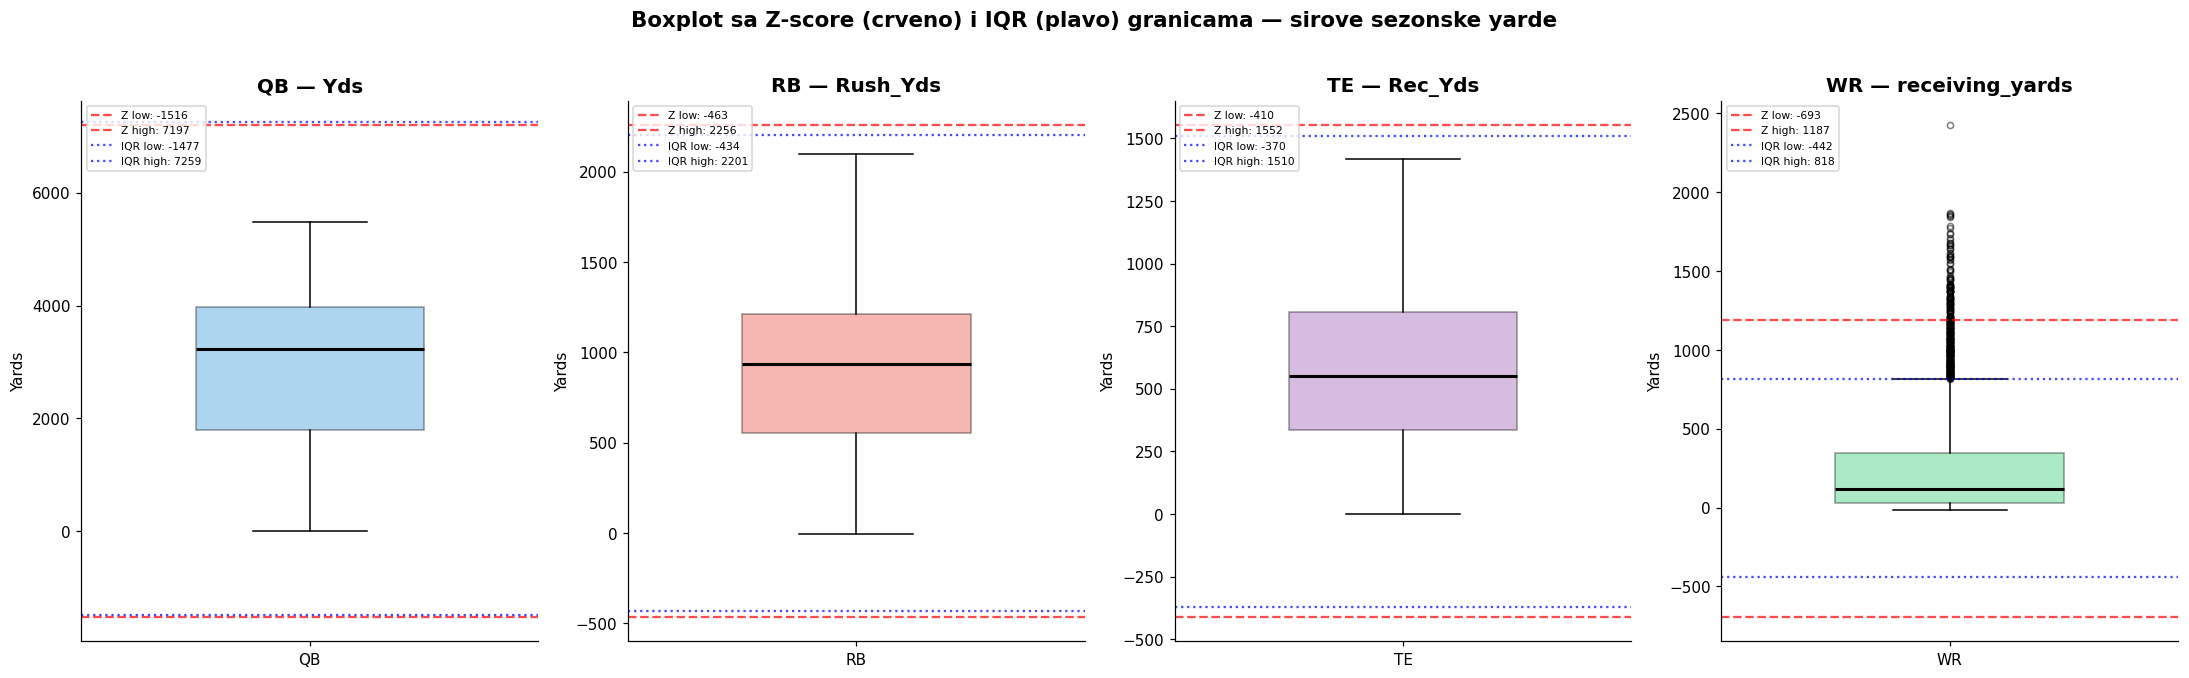

In [14]:
plot_outlier_boxplots(outlier_targets, z_threshold=3)

### Zapažanja iz inicijalne detekcije

Na sirovim sezonskim jardima, ni Z-score ni IQR ne detektuju outliere kod QB i RB - jer bimodalna (QB) i široka distribucija razvlače standardnu devijaciju i IQR toliko da sve tačke ostaju unutar granica.

Kod WR IQR detektuje čak 391 (7%) outliera, ali to su u stvari legitimni igrači s visokom produkcijom - problem je u desno nagnutojem (skewed) distribuciji. 

Problem: sirove sezonske yarde mešaju dva različita efekta:
1. Kvalitet igrača - koliko je dobar po utakmici
2. Kvantitet nastupa - koliko utakmica je odigrao (povrede, rezerve)

Zato u sljedećem koraku:
- QB: uklanjamo sezone gdje igrač nije nijednom startovao (GS = 0 → čisti backup-i), a zatim koristimo Yds / G (jardi po utakmici) da normalizujemo za povrede
- RB, TE: koristimo per-game normalizaciju (Rush_Yds / G, Rec_Yds / G**)
- WR: primenjujemo log transformaciju na receiving_yards, a zatim detektujemo outliere na log skali

### 2. Tretman QB bimodalne distribucije

QB distribucija ukupnih jardi ima dva vrha: jedan oko 0–500 (backup QB-ovi koji nikad nisu startovali) i drugi oko 3000–4500 (regularni starteri). Backup-i koji nisu nijednom startovali (GS = 0) nemaju smislenu sezonsku statistiku za predviđanje performansi i trebaju biti isključeni.

Za preostale QB-ove (koji su barem jednom startovali), koristimo Yds / G (jardi po odigranoj utakmici) umesto ukupnih sezonskih jardi. Ovo osigurava da igrači koji su se povredili ili propustili deo sezone ne budu nepravedno klasifikovani kao outlieri.

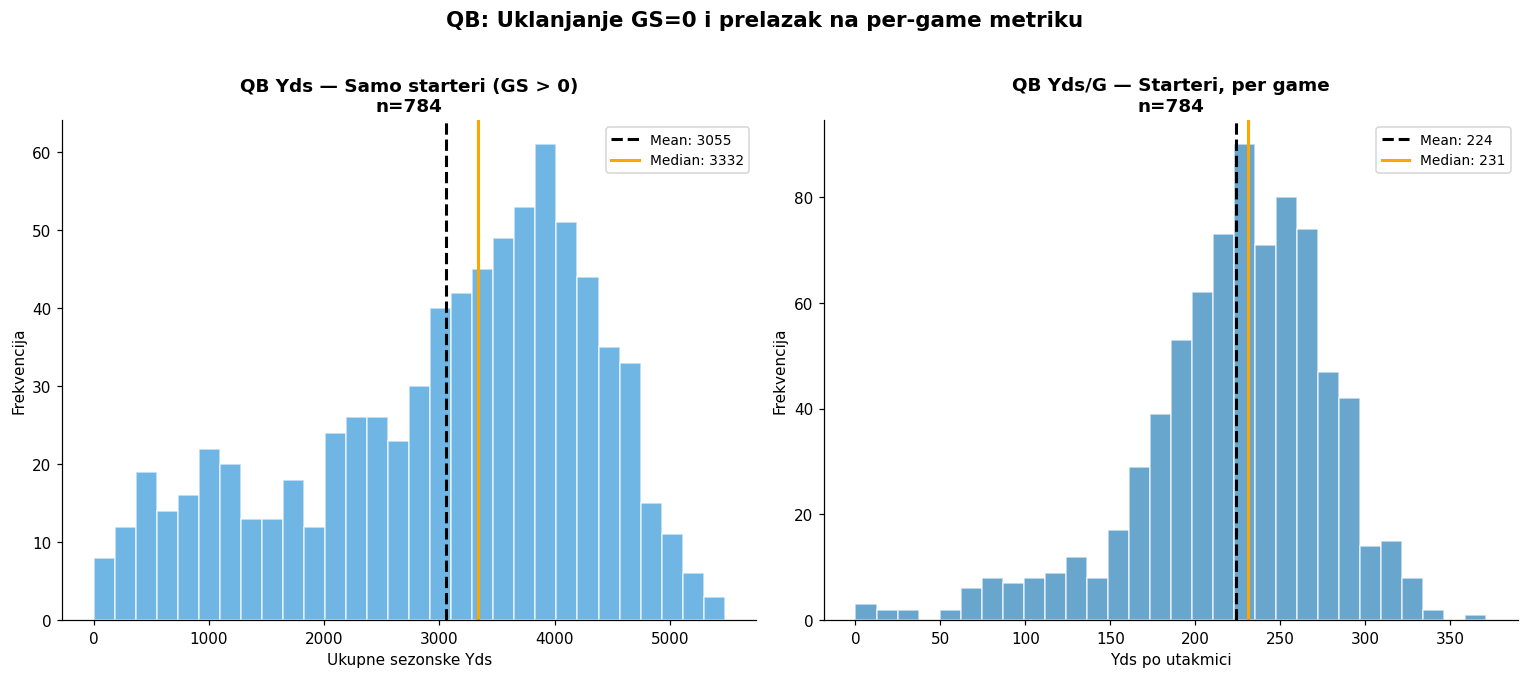

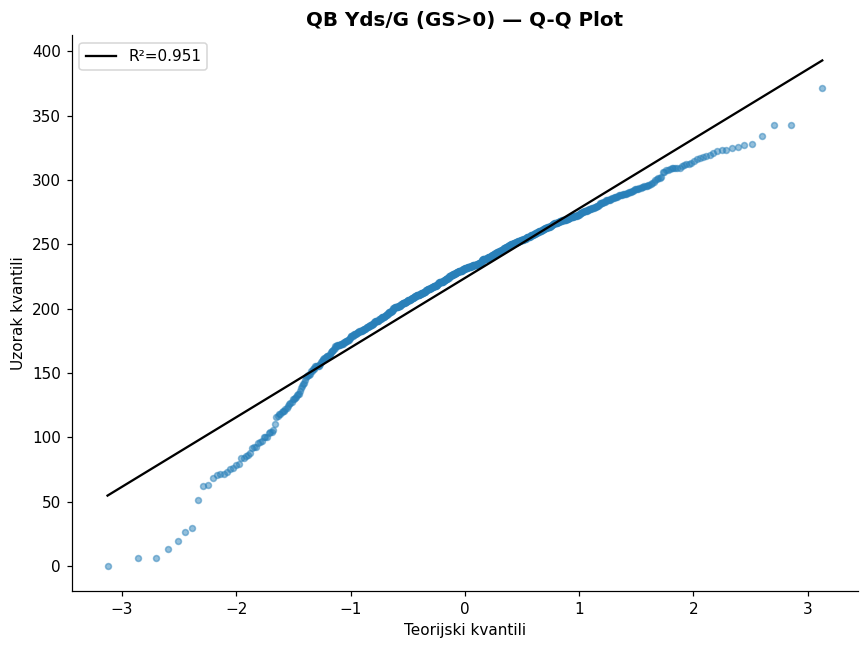

R² (Yds/G, GS>0): 0.951


In [15]:
plot_qb_bimodal(qb)
plot_qb_qqplot(qb)

Uklanjanje 61 QB sezone (GS=0, 7.2%) eliminira prvi vrh bimodalne distribucije. Preostala distribucija je unimodalna sa blagim levim repom (igrači koji su startovali ali se povredili rano u sezoni). 

Prelazak na Yds/G dodatno normalizuje tu razliku: sad svaka sezona predstavlja prosječne performanse po utakmici, bez obzira koliko utakmica je igrač propustio. R² raste sa 0.948 na 0.951, potvrđujući bolji fit na normalnu distribuciju.





### 3. WR: Outlier detekcija na log(receiving_yards)

Kako je prethodno ustanovljeno, WR distribucija je izrazito right-skewed. Log transformacija normalizuje distribuciju, pa outlier detekcija na log skali daje smislenije rezultate - izdvaja samo zaista ekstremne sezone, ne čitavu gornju polovinu lige.

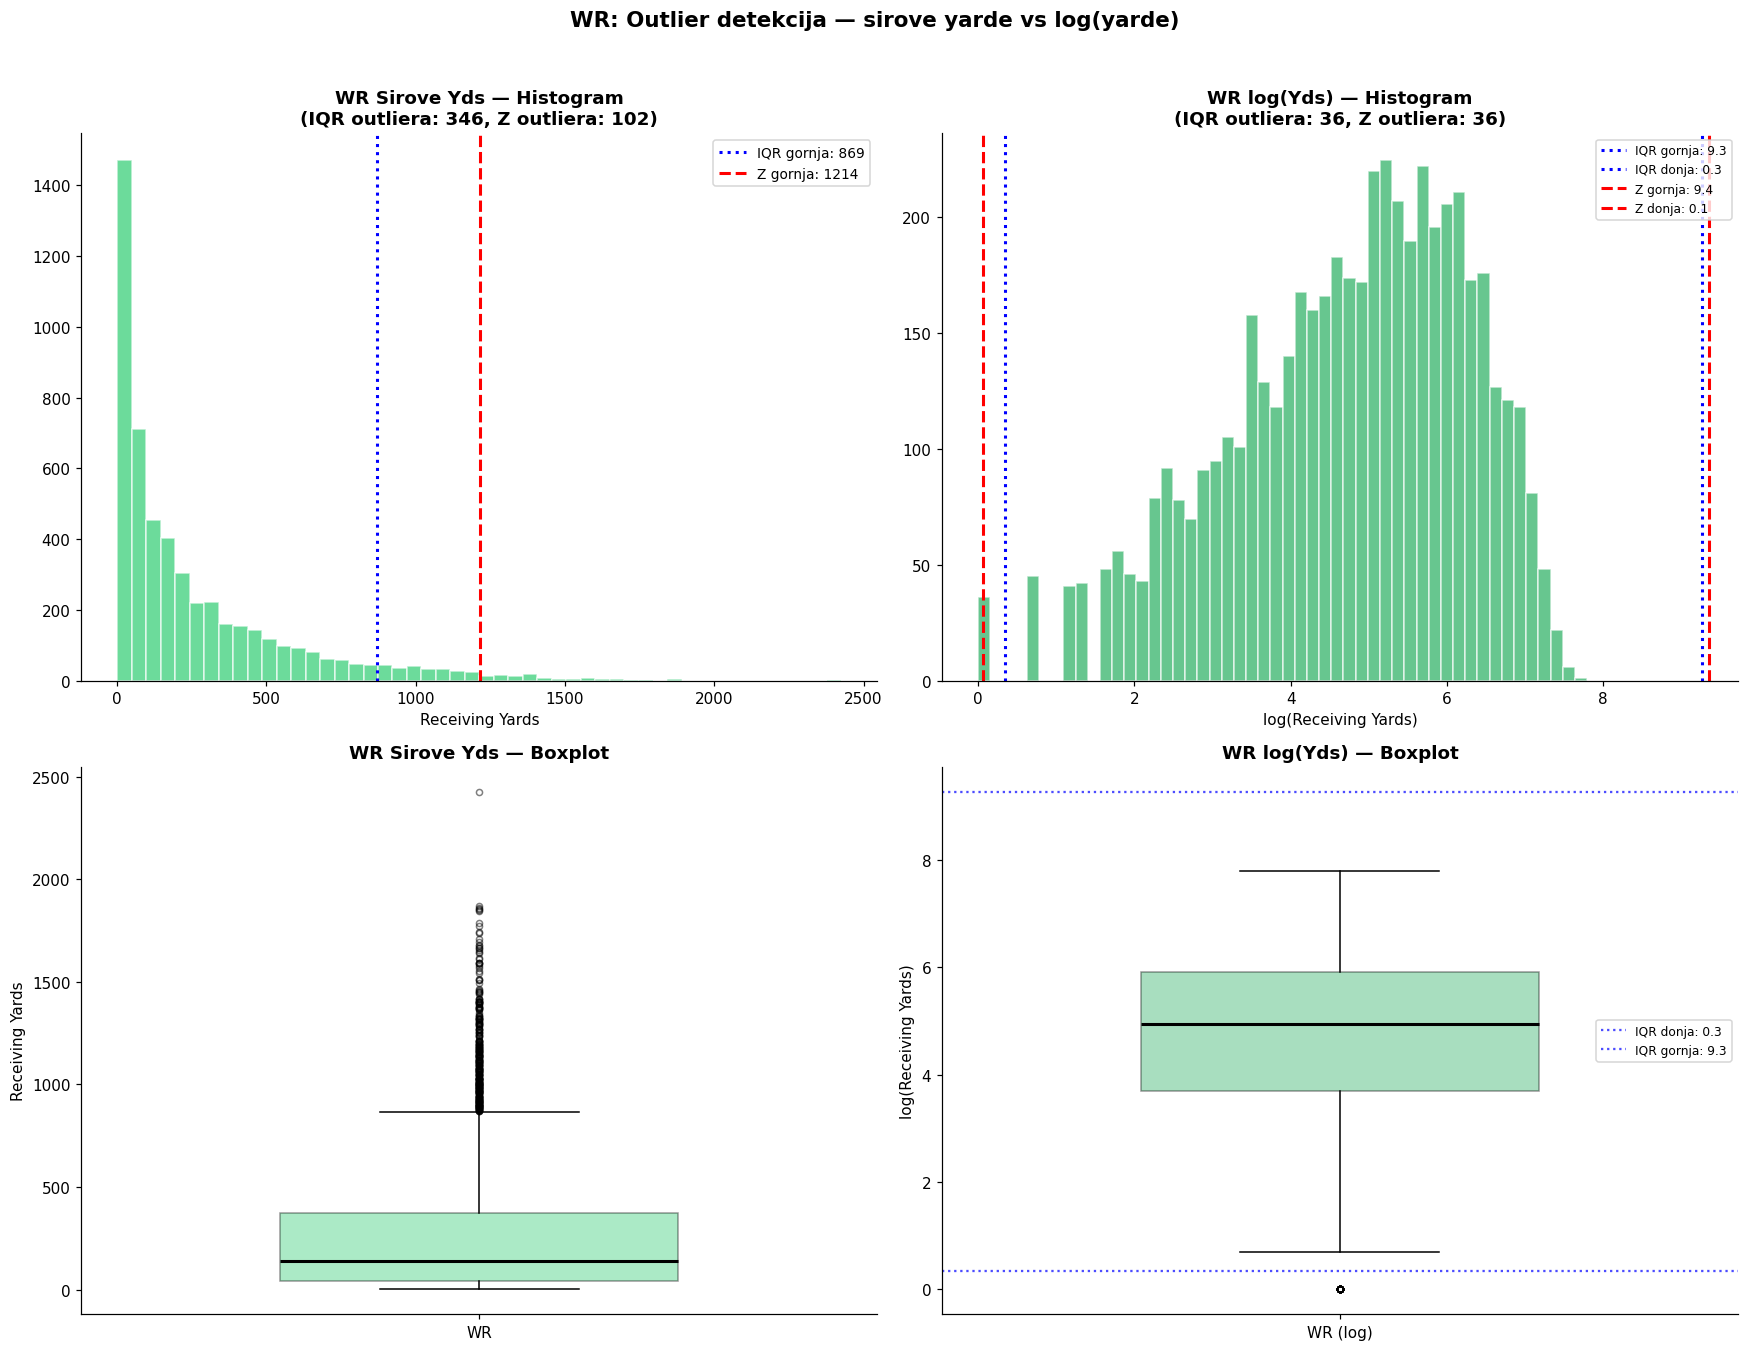

,Skala,N,Z outliera,IQR outliera,Z %,IQR %
0,Sirove Yds,5186,102,346,1.97,6.67
1,log(Yds),5186,36,36,0.69,0.69


In [16]:
plot_wr_log_outliers(wr_seasons, z_threshold=3)
display(wr_log_outlier_table(wr_seasons, z_threshold=3))


---
## Ne-numeričke Kolone i Analiza Nagrada

Pregled ne-numeričkih (kategorijskih / string) kolona u svakom skupu podataka, te pie chart analiza koje se nagrade pojavljuju kod QB, RB i TE igrača.


In [17]:
for name, df in datasets.items():
    pos = name.split("(")[0].strip()
    cols = df.select_dtypes(exclude="number").columns.tolist()
    cols_str = ", ".join(cols) if cols else "Nema ne-numeričkih kolona"
    
    print(f"**{pos}** ({len(cols)} columns): {cols_str}")
    print("_" * 92) 

**QB** (9 columns): Player, PlayerID, Team, Pos, QBrec, Awards, snp_Def%, snp_Off%, snp_ST%
____________________________________________________________________________________________
**RB** (9 columns): Player, PlayerID, Team, Lg, Pos, awards, snp_Def%, snp_Off%, snp_ST%
____________________________________________________________________________________________
**TE** (8 columns): Player, PlayerID, Team, Pos, Awards, snp_Def%, snp_Off%, snp_ST%
____________________________________________________________________________________________
**WR** (4 columns): receiver_player_id, receiver_player_name, passer_player_id, player_team
____________________________________________________________________________________________


U narednim fazama pripreme podataka, planiramo da eliminišemo kolone koje predstavljaju isključivo metapodatke (poput ID brojeva i imena igrača) ili marginalne aspekte igre, kao što je procenat snepova u specijalnim timovima. Budući da specijalni timovi čine zanemarljiv udeo u igri nosilaca napada, njihovo uključivanje bi samo unelo nepotreban šum u model. Fokus će biti zadržan isključivo na varijablama koje direktno utiču na ofanzivnu produkciju i stabilnost podataka.

Ona koja je korisna su awards jer su nagrade ključan signal za buduće performanse - igrači koji su već dokazani kroz Pro Bowl, All-Pro ili MVP glasanja imaju tendenciju održavanja visokog nivoa igre.

### Analiza nagrada


In [18]:
award_map = {
    'QB': ('Awards', qb),
    'RB': ('awards', rb),
    'TE': ('Awards', te),
}
awards_summary(award_map)

PREGLED SVIH VRSTA NAGRADA U DATASETU (QB + RB + TE)

Nagrada                       QB     RB     TE   UKUPNO
-------------------------------------------------------
PB                           262    152     92      506
AP-1                          40     52     27      119
AP-2                          37     39     20       96
AP MVP-1                      32      8      0       40
AP MVP-2                      26      5      0       31
AP OPoY-2                     24      7      0       31
AP OPoY-3                     20      9      0       29
AP OPoY-1                     14     15      0       29
AP OPoY-4                     20      7      1       28
AP MVP-3                      14      7      0       21
AP OPoY-5                      9      6      2       17
AP ORoY-1                      8      7      0       15
AP CPoY-3                      8      4      2       14
AP MVP-4                       8      6      0       14
AP MVP-5                      11      2      0    

Vidimo da ima dosta zapisa u koloni za nagrade, ali nisu svi ti zapisi dodeljene nagrade, nego se beleži ranking u glasanju za odredjenu nagradu, tako da ako je neko bio npr. bio 11. u glasanju za Offensive player of the Year to nama nije znacajno. 

Takodje ima nagrada poput Comeback Player of the yaer koja nam isto nije znacajna ona je subjektivna i ne odražava nužno čistu veštinu. Ona nagrađuje napredak u odnosu na lošu prethodnu sezonu ili povredu, što diskriminiše konstantno elitne igrače koji nemaju od čega da se "vraćaju"

### Odabir nagrada
Koristićemo 5 posebnih metrika za nagrade koji su prikazani ispod:

In [19]:
award_map = {
    'QB': ('Awards', qb),
    'RB': ('awards', rb),
    'TE': ('Awards', te),
}
awards_category_summary(award_map)

________________________________________________________________________________
BROJ SEZONA SA NAGRADOM PO POZICIJI (od ukupno QB=845, RB=622, TE=351)

Kategorija             |         QB |         RB |         TE
-------------------------------------------------------------
Pro Bowl (PB)          |  262 ( 31.0%) |  152 ( 24.4%) |   93 ( 26.5%)
All-Pro 1st Team       |   40 (  4.7%) |   52 (  8.4%) |   28 (  8.0%)
All-Pro 2nd Team       |   37 (  4.4%) |   39 (  6.3%) |   20 (  5.7%)
TOP 5 MVP              |   92 ( 10.9%) |   28 (  4.5%) |    0 (  0.0%)
TOP 5 OPoY             |   89 ( 10.5%) |   46 (  7.4%) |    4 (  1.1%)
-------------------------------------------------------------


### Pie chart analiza nagrada

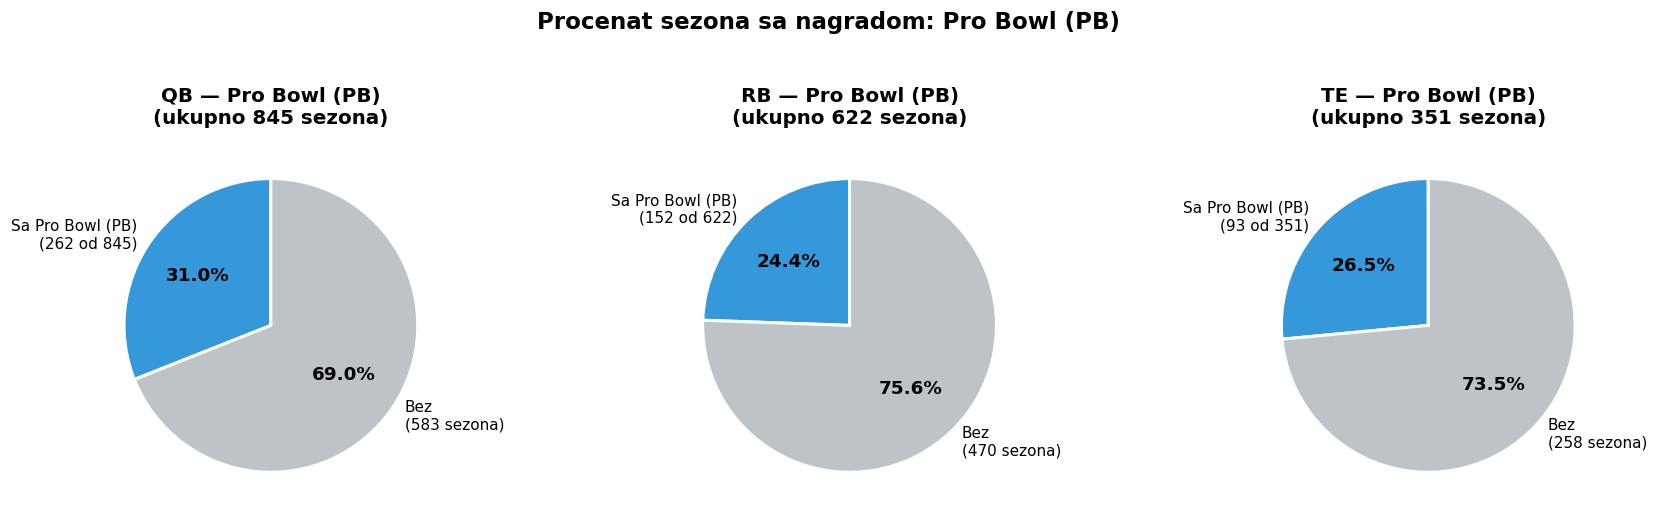

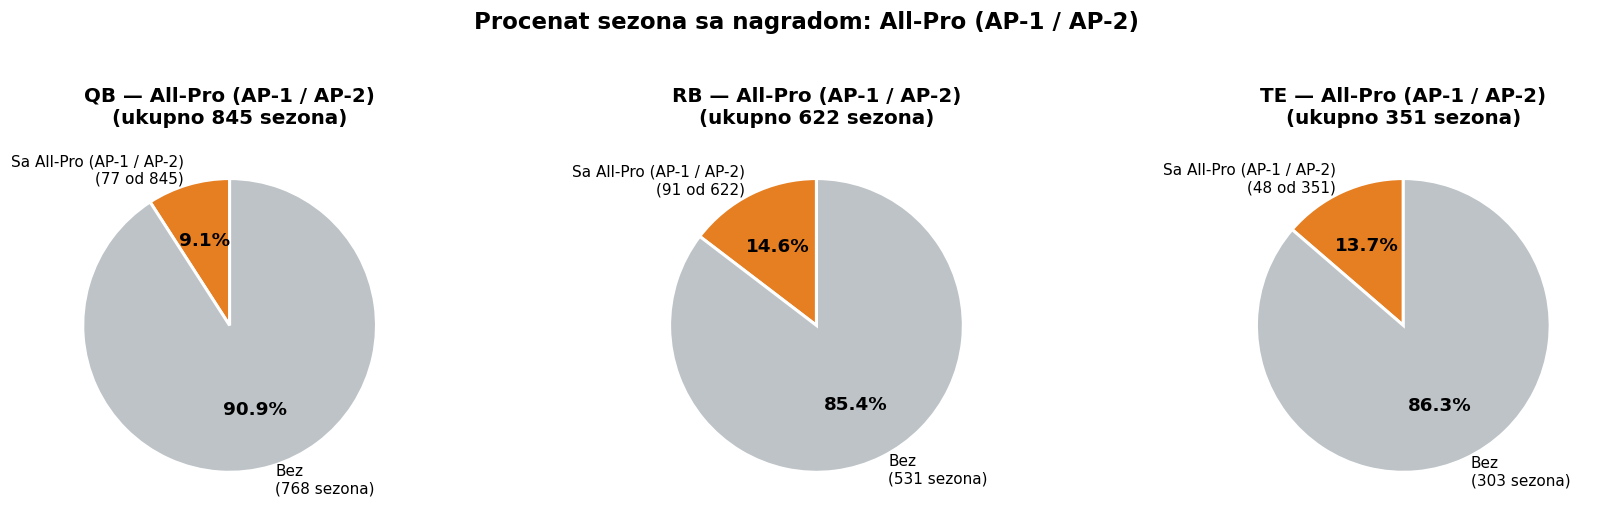

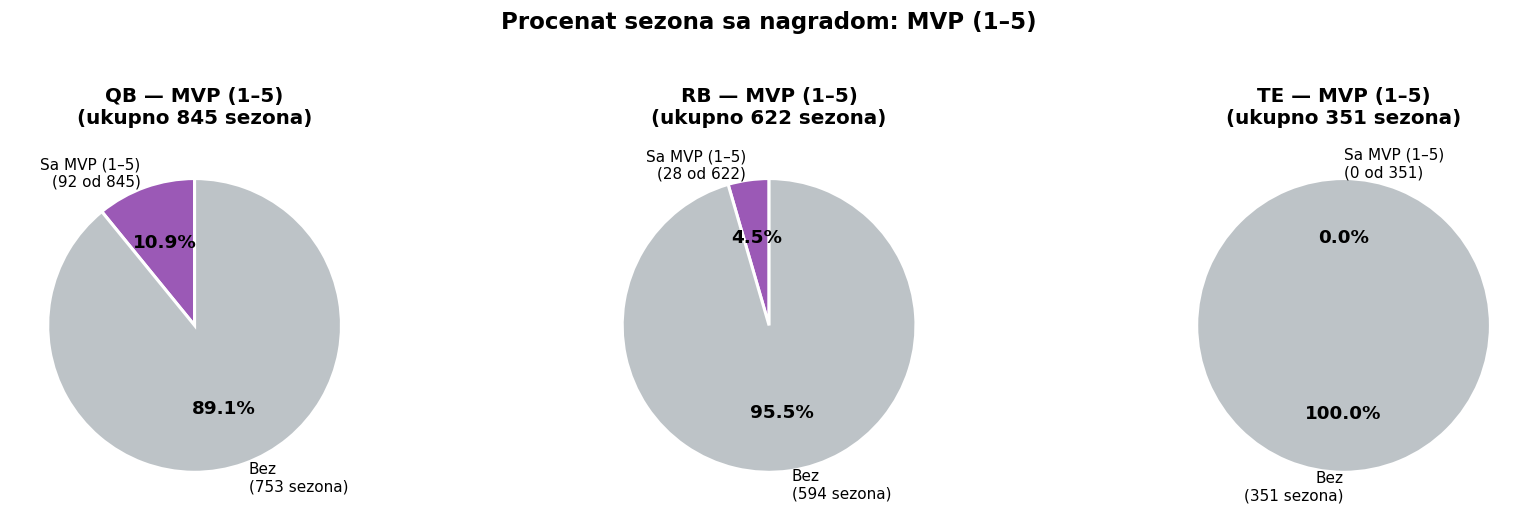

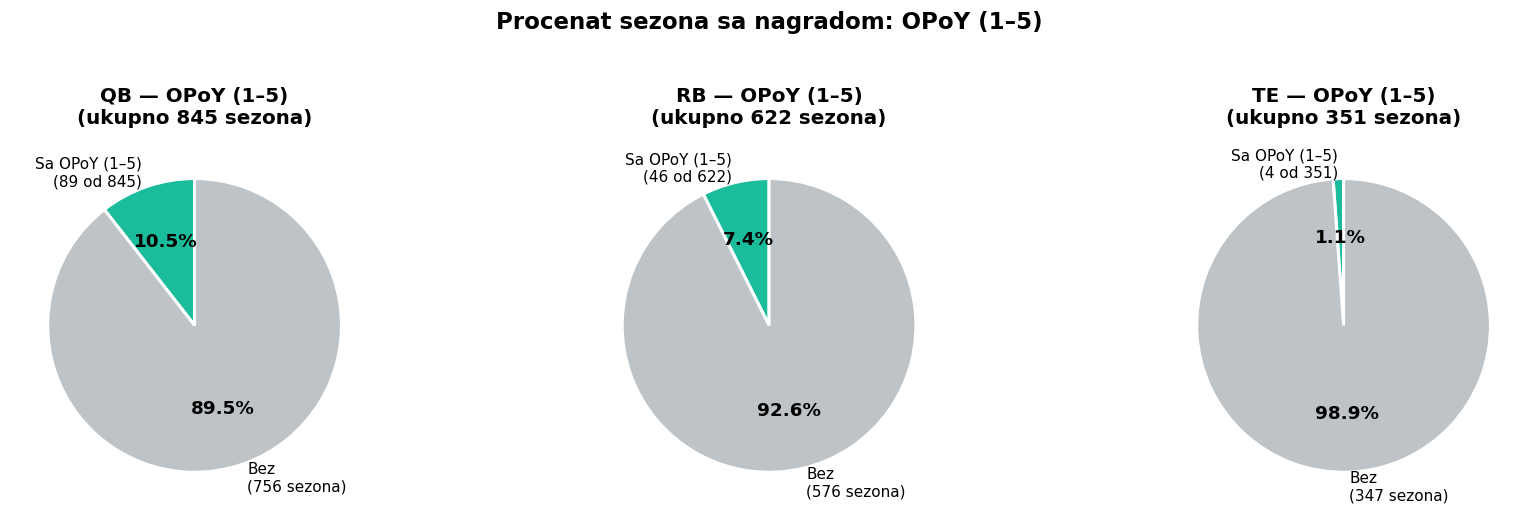

In [20]:
award_map = {
    "QB": ("Awards", qb),
    "RB": ("awards", rb),
    "TE": ("Awards", te),
}
plot_awards_pie(award_map)

### Zaključak - Nagrade kao Feature za Predikciju

Pie chartovi prikazuju procenat sezona (redova) u kojima se pojavljuje svaka nagrada od ukupnog broja sezona za datu poziciju:

- Pro Bowl (PB) je najčešća nagrada - pojavljuje se u značajnom procentu sezona, posebno kod QB-ova.
- All-Pro (AP-1, AP-2) je znatno ređa - vrlo mali procenat sezona nosi ovu oznaku, što je čini ekskluzivnijim signalom kvaliteta.
- MVP i OPoY nagrade su ekstremno retke na nivou sezona, ali su izuzetno jak indikator vrhunske igre.

Ove nagrade se koriste kao feature u modelovanju jer sezona sa nagradom signalizira vrhunsku igru i pomaže modelu da prepozna obrasce koji vode ka budućim performansama.

Nakon smanjivanja broja razlićitih klasa unutar award kolone, zbog malog broja različitih kolona smo se odlčili za one hot encoding.

---
## Korelacije


U nastavku su prikazane analize korelacija između varijabli, predstavljene kroz matrice korelacije i pair plot vizualizacije.

### QB - Korelaciona Matrica

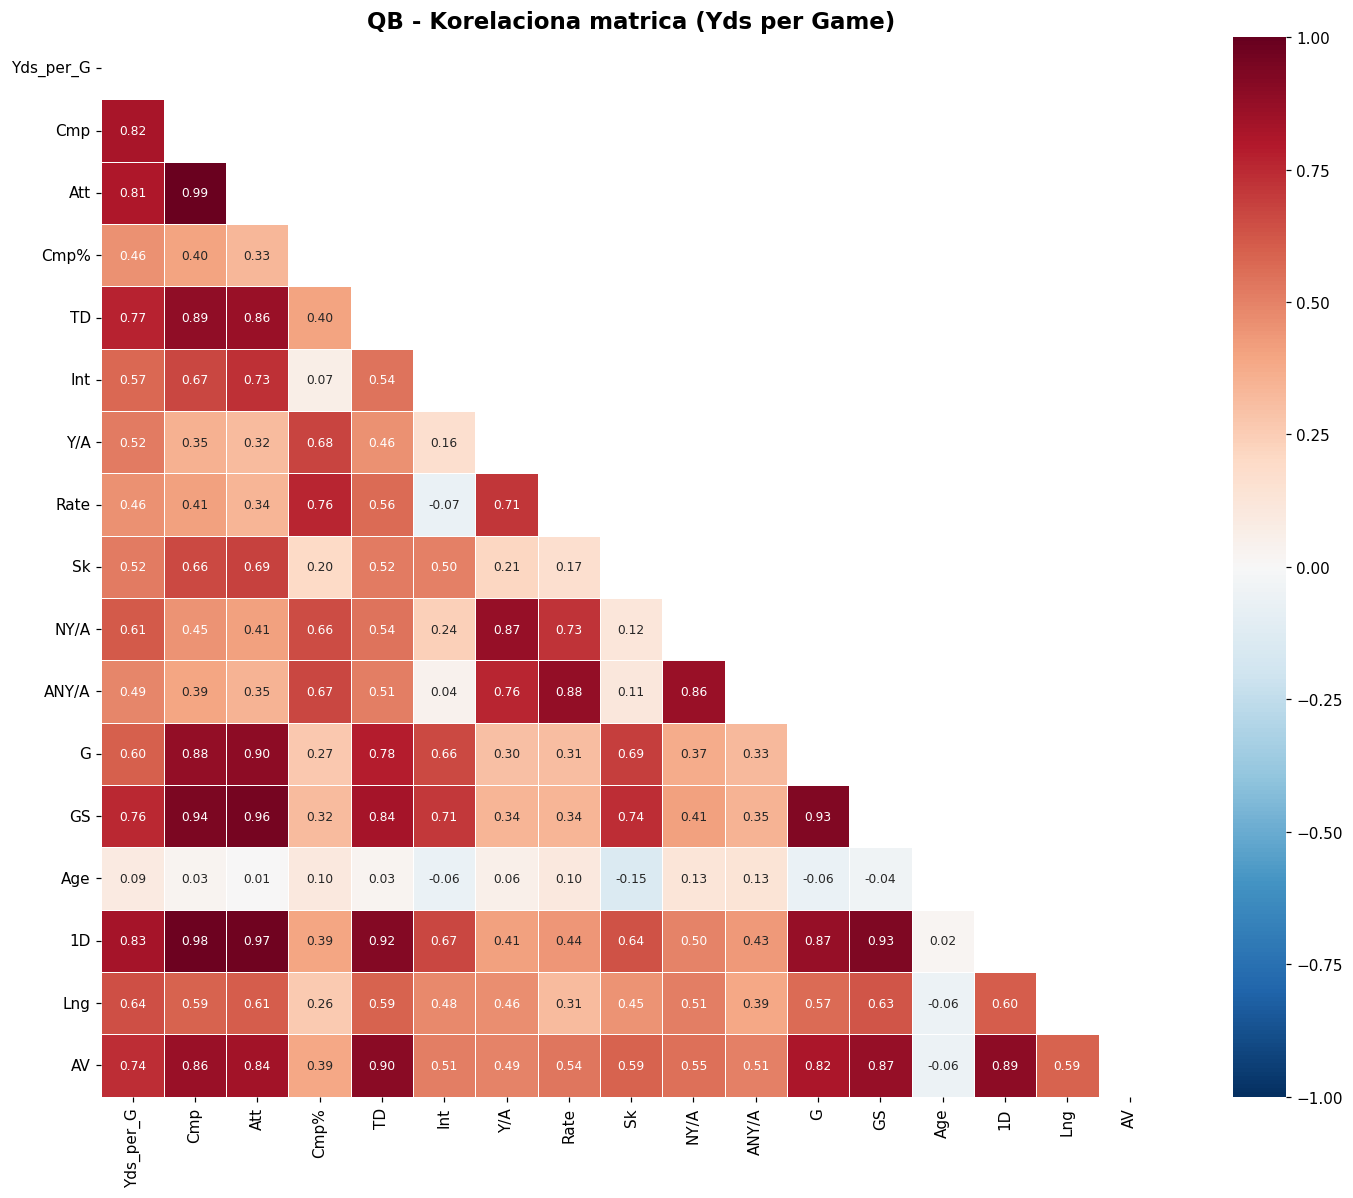

In [21]:
plot_qb_correlation_heatmap(qb)

**Zaključak:**
- Najjače korelacije: `Att` (pokušaji), `Cmp` (kompletirana dodavanja), `GS` (games started), `1D` (prvi downi). Ovo je logično – više pokušaja = više yardi.
- Passer Rating (`Rate`) ima umeren pozitivan odnos, što znači da efikasnost sama po sebi ne garantuje visoke yarde – volumen je ključan.
- Interceptions (`Int`) nema veliku korelaciju sa drugim statistikama, čak i sa statistikama efikasnosti, poput passer rating-a, što je možda neočekivano.
- `Age` pokazuje minimalnu korelaciju sa performansama, što ukazuje da starost nema toliki uticaj na QB produktivnost kao kod ostalih pozicija.

### RB - Korelaciona Matrica

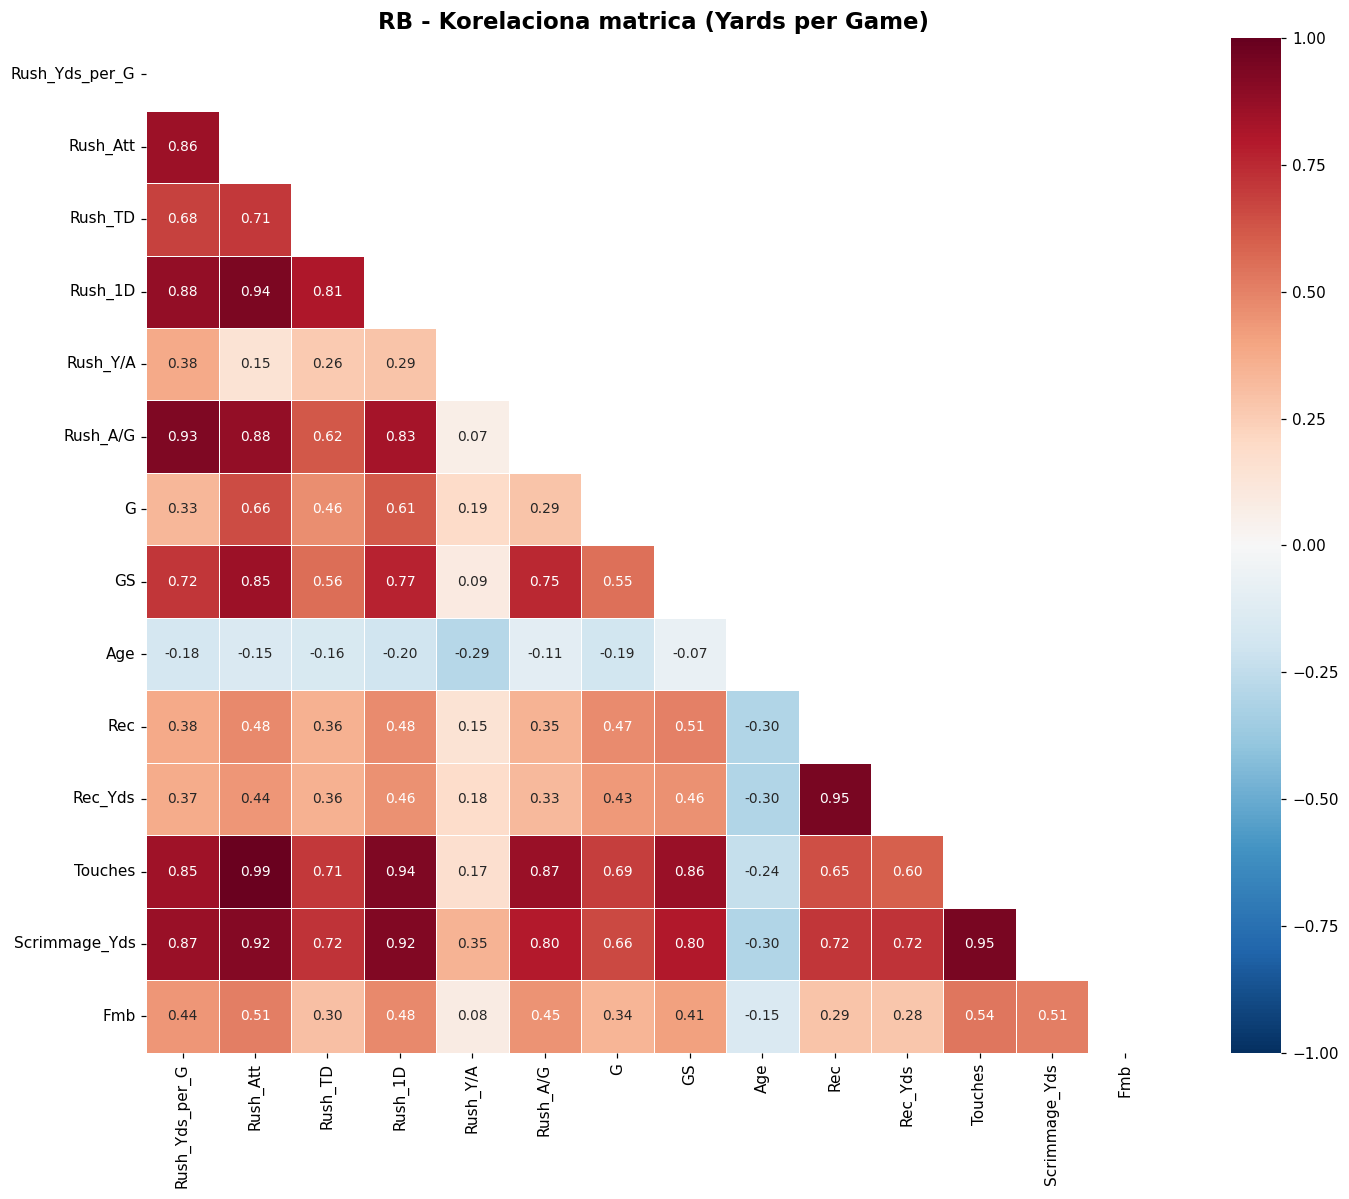

In [22]:
plot_rb_correlation_heatmap(rb)

**Zaključak:**
- Rush yards po utakmici (`Rush_Yds_per_G`) direktno korelira sa volume metrikama (`Rush_Att`, `Touches`) i ukupnom produktivnošću (`Scrimmage_Yds`).
- `Rush_Y/A` (yards per attempt) ne znači puno za yards po utakmici jer volumen igra dominantniju ulogu - prosek ostaje stabilan, ali ga je teško održati na velikoj zapremini pokušaja.
- Receiving metrike (`Rec`, `Rec_Yds`) ne pokazuju značajnu korelaciju sa rushing performansama, što potvrđuje da su ove dve dimenzije igre međusobno nezavisne.
- `Age` ima obrnuto proporcionalan uticaj na yarde, i to je posebno izrazito kod RB pozicije - za razliku od QB-a, gdje starost ima minimalan efekat, RB igrači vidno gube produktivnost sa godinama.

### WR - Korelaciona Matrica

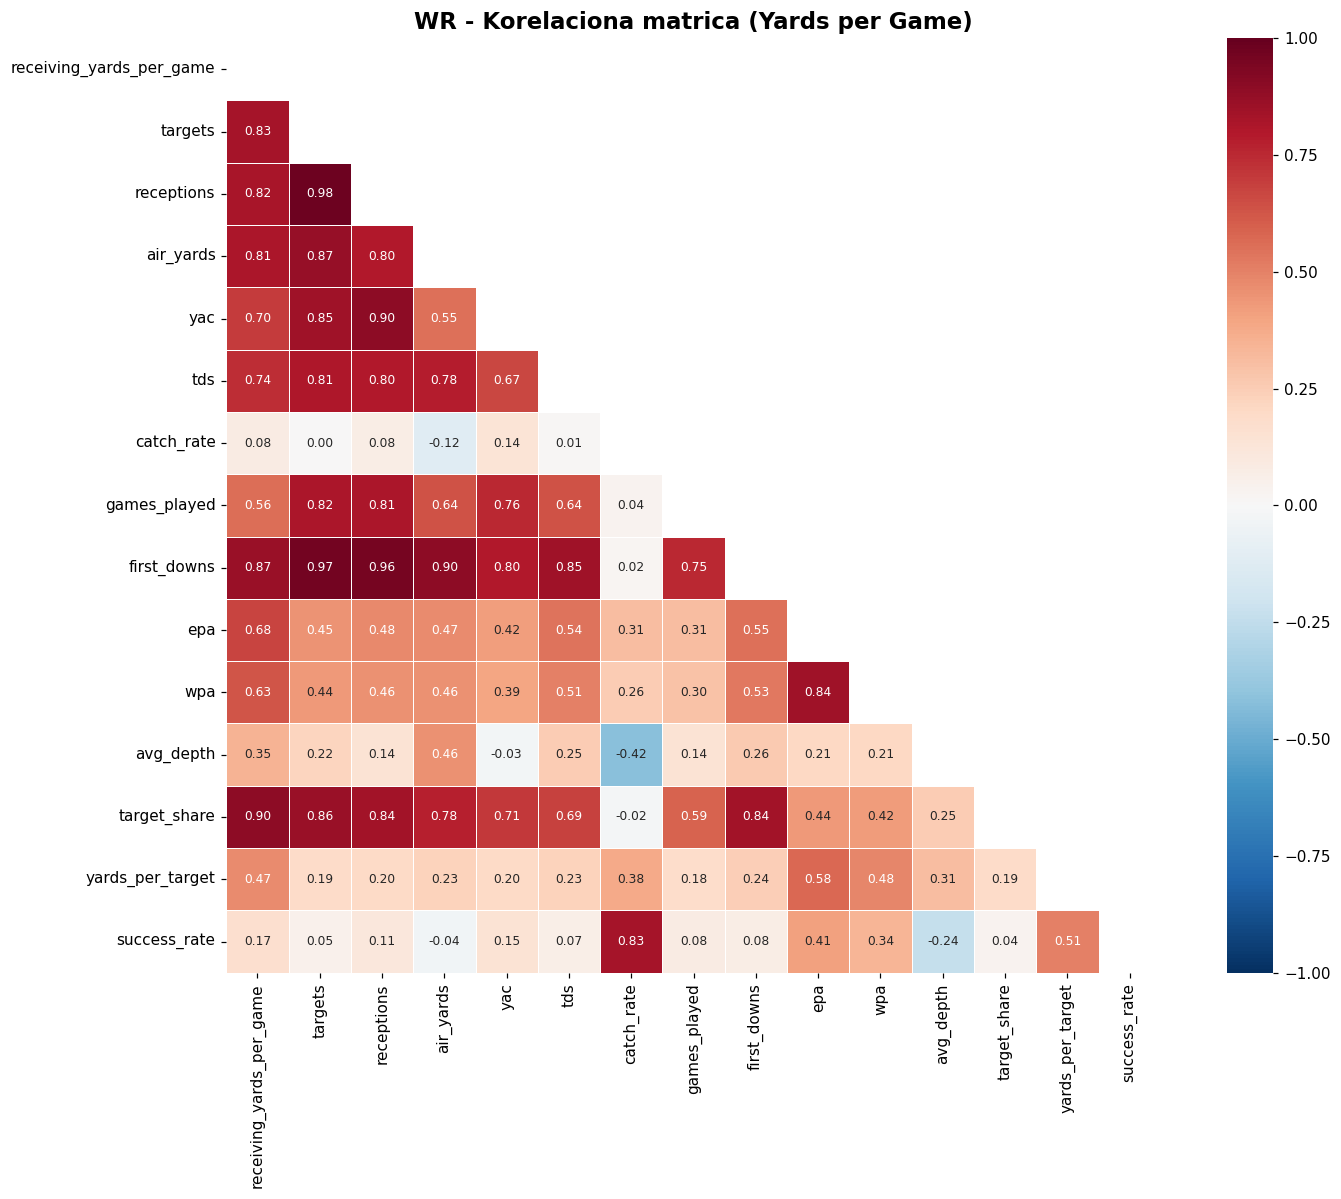

In [23]:
plot_wr_correlation_heatmap(wr_seasons)

**Zaključak:**
- Receiving yards po utakmici (`receiving_yards_per_game`) ima najjaču korelaciju sa `targets` i `receptions`, što potvrđuje važnost volume-based upotrebe.
- Postoji i jaka korelacija između `receiving_yards_per_game` i `first_downs` te `target_share` - receiver koji pomera lance i osvaja nove prve downove dobija veći udeo u timskim targetima, što direktno rezultira većom jardažom.
- Neke kvalitativne metrike imaju značajan uticaj na yarde - `air_yards` pokazuje snažnu korelaciju, dok druge kao što je `catch_rate` praktično nema korelaciju sa yards/game, što ukazuje da sam procenat hvatanja ne određuje jardažu.
- Postoji jasna i očigledna obrnuta korelacija između `catch_rate` i `avg_depth` (dublje rute = manji procenat hvatanja), kao i između `avg_depth` i `success_rate` (veća dubina targeta smanjuje stopu uspešnih play-va).


### TE - Korelaciona Matrica

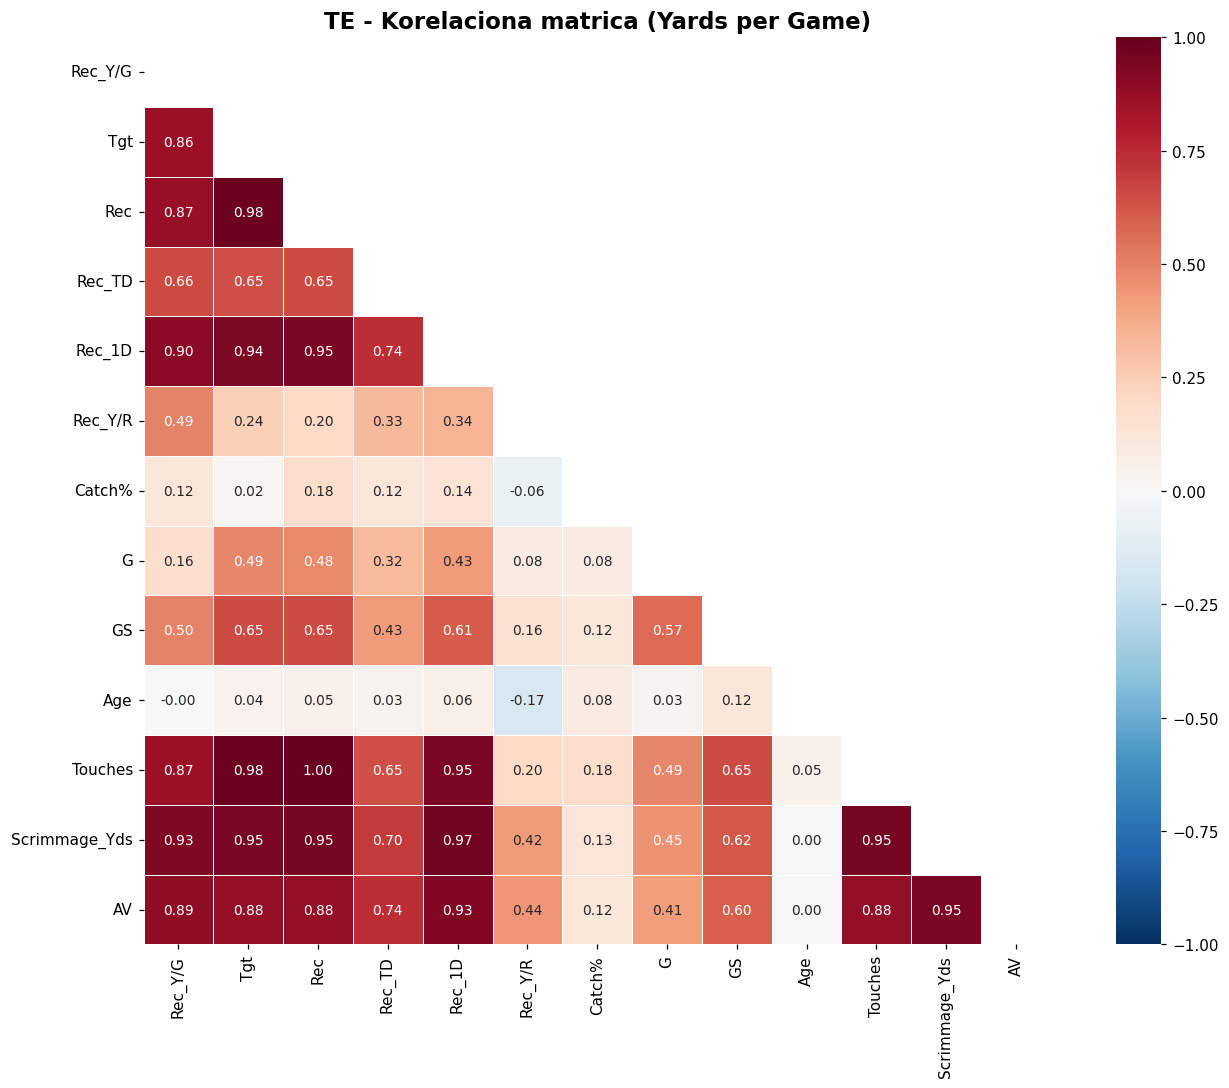

In [24]:
plot_te_correlation_heatmap(te)

**Zaključak:**
- Receiving yards po utakmici (`Rec_Yds_per_G`) kod TE pozicije direktno korelira sa `Tgt` (targets) i `Rec` (receptions), sličnom mehanikom kao kod WR.
- `Rec_Y/R` (yards per reception) pokazuje umerenu korelaciju, što ukazuje da su eksplozivniji TE igrači efikasniji u generisanju yardi.
- `Age` kod TE pozicije ne pokazuje korelaciju za razliku od RB pozicije, mada vidi se smanenje eksplozivnosti jer opada Y/R, ali zato TE pozicija je takva da ih bolje blokiranje drži na terenu duže u karijeri i iskustvo pomaze da ostale statistike ne opadaju sa godinama.

**Ključni uvid za modeliranje:**
- Kod svih četiri skupa podataka primjećuje se visoka međusobna korelacija između feature kolona (multikolinearnost) - volume metrike  međusobno su snažno korelisane. Ovo direktno utiče na stabilnost linearnih modela jer koeficijenti postaju nestabilni i teški za interpretaciju. Zbog toga će regularizacioni modeli (Lasso, Ridge, ElasticNet) biti posebno važni.

## Pair Plot - Vizuelna dopuna matrice korelacije

Pair plot prikazuje sve parove scatter plotova za odabrane numeričke varijable, sa distribucijama na dijagonali. Ovo omogućava brzu identifikaciju i vizuelnu dopunu matrice korelacije


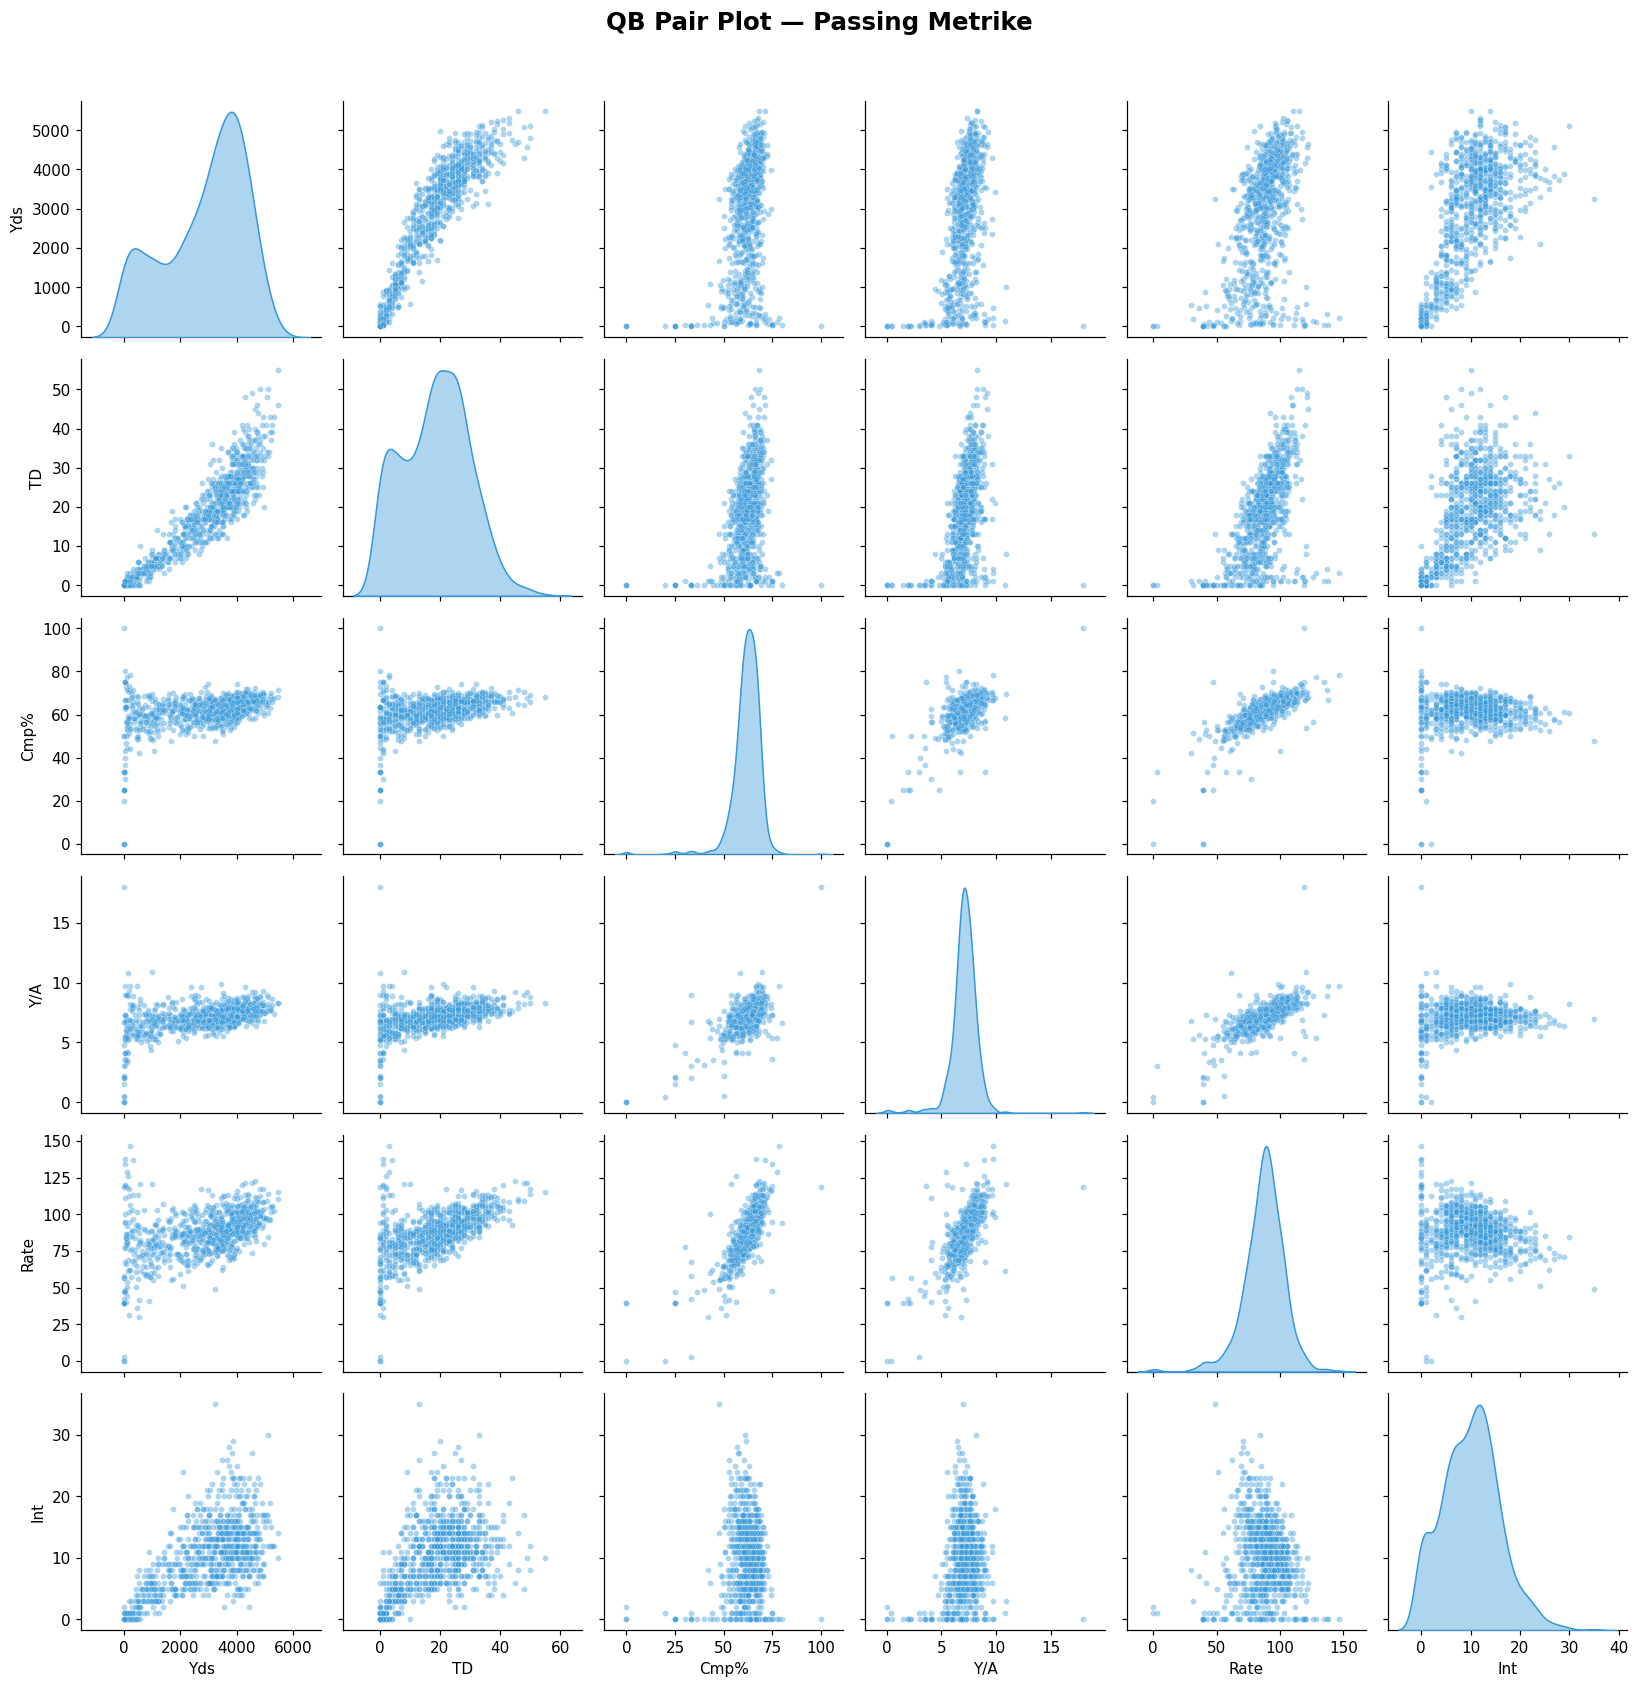

In [25]:
plot_qb_pairplot(qb)

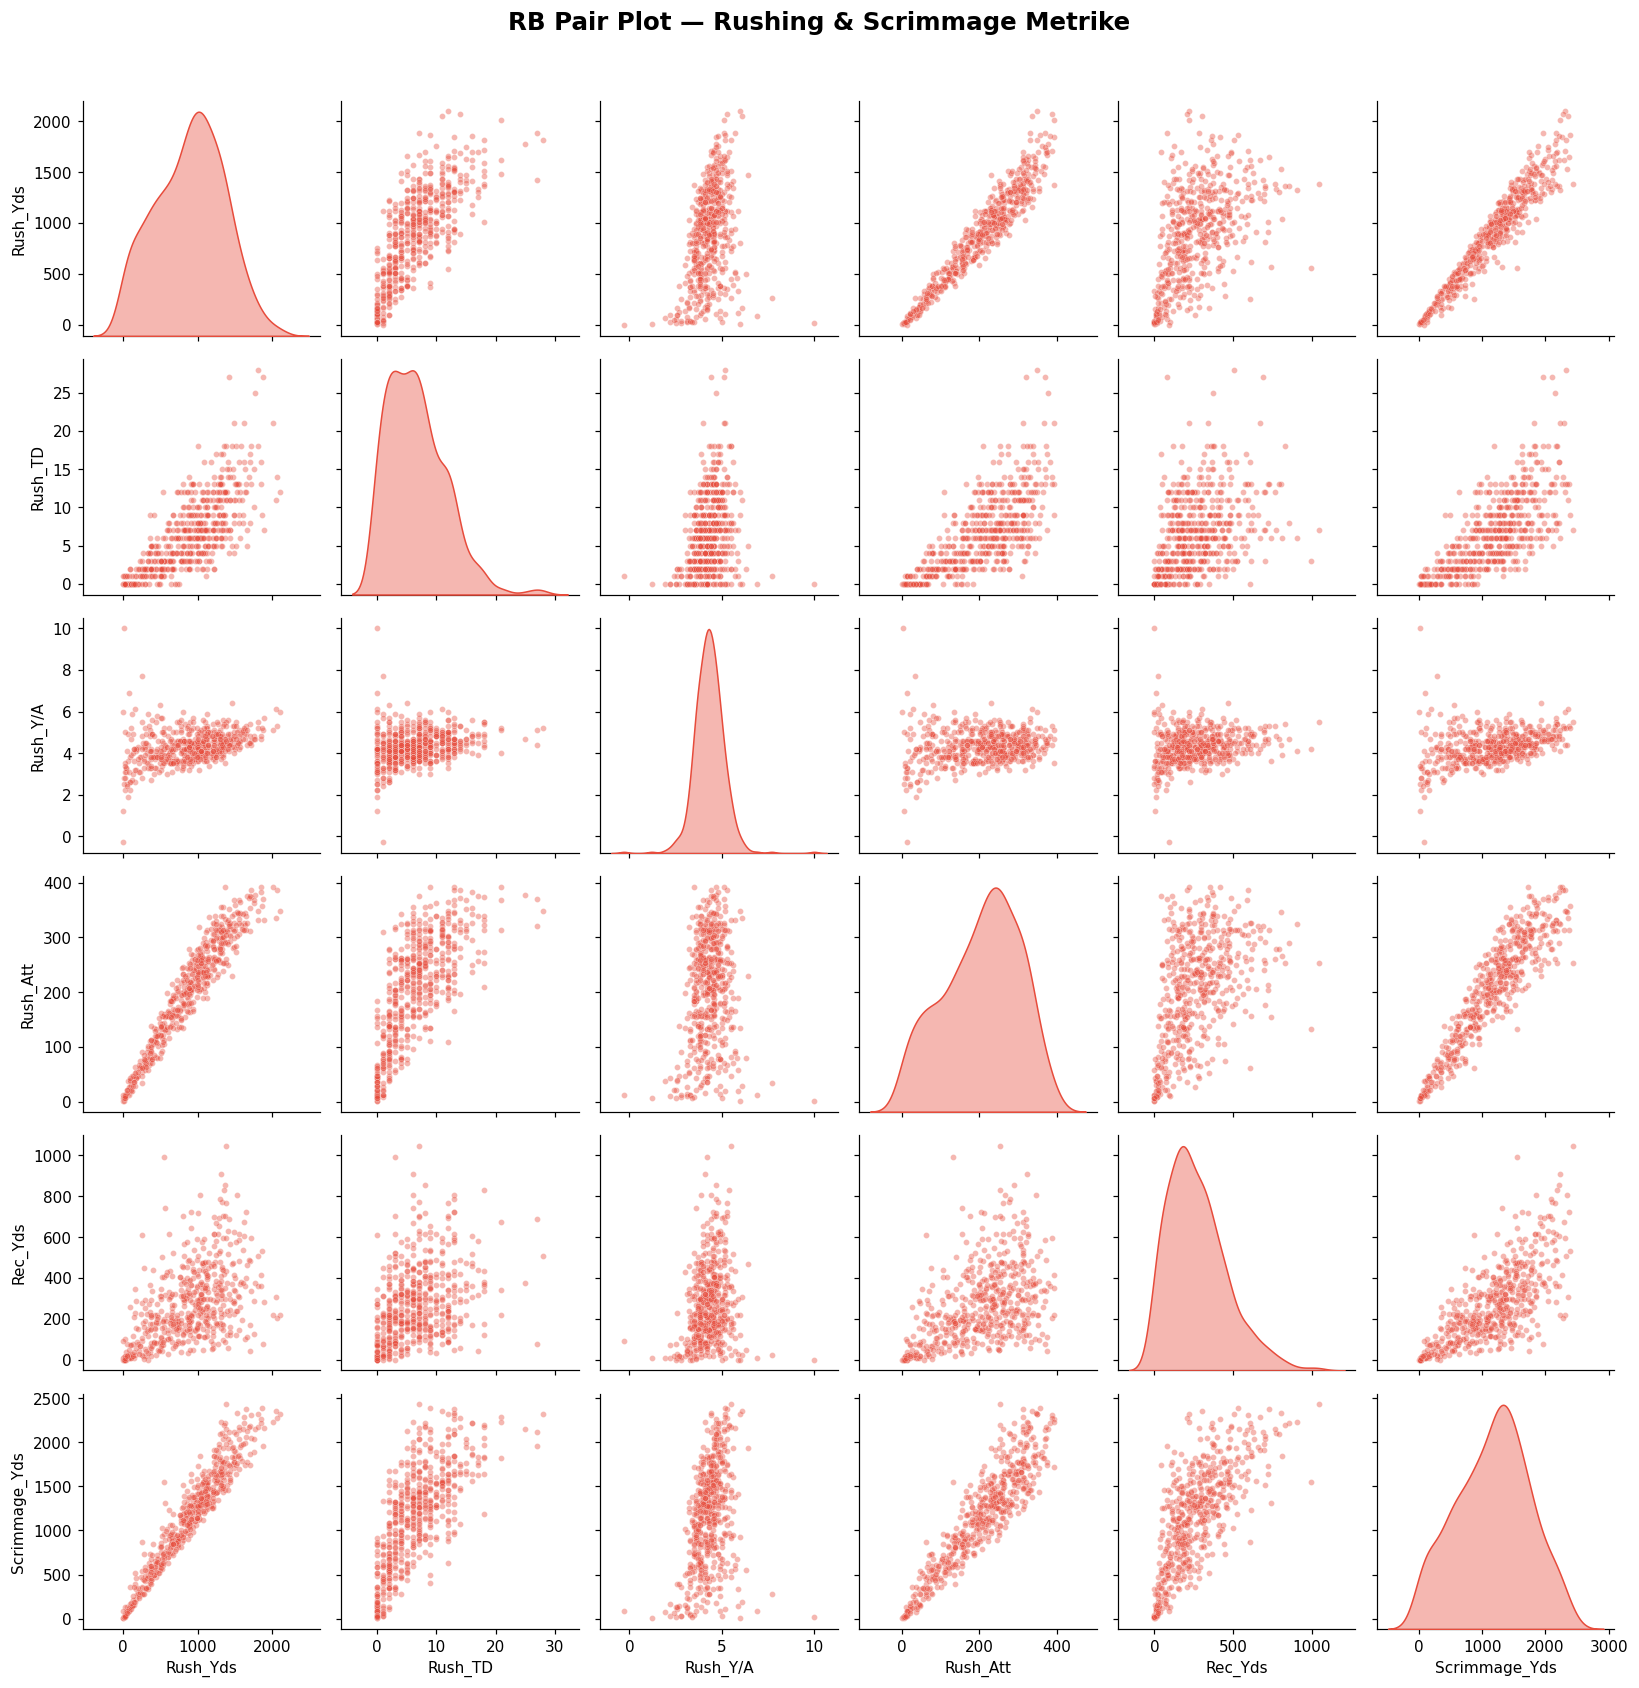

In [26]:
plot_rb_pairplot(rb)

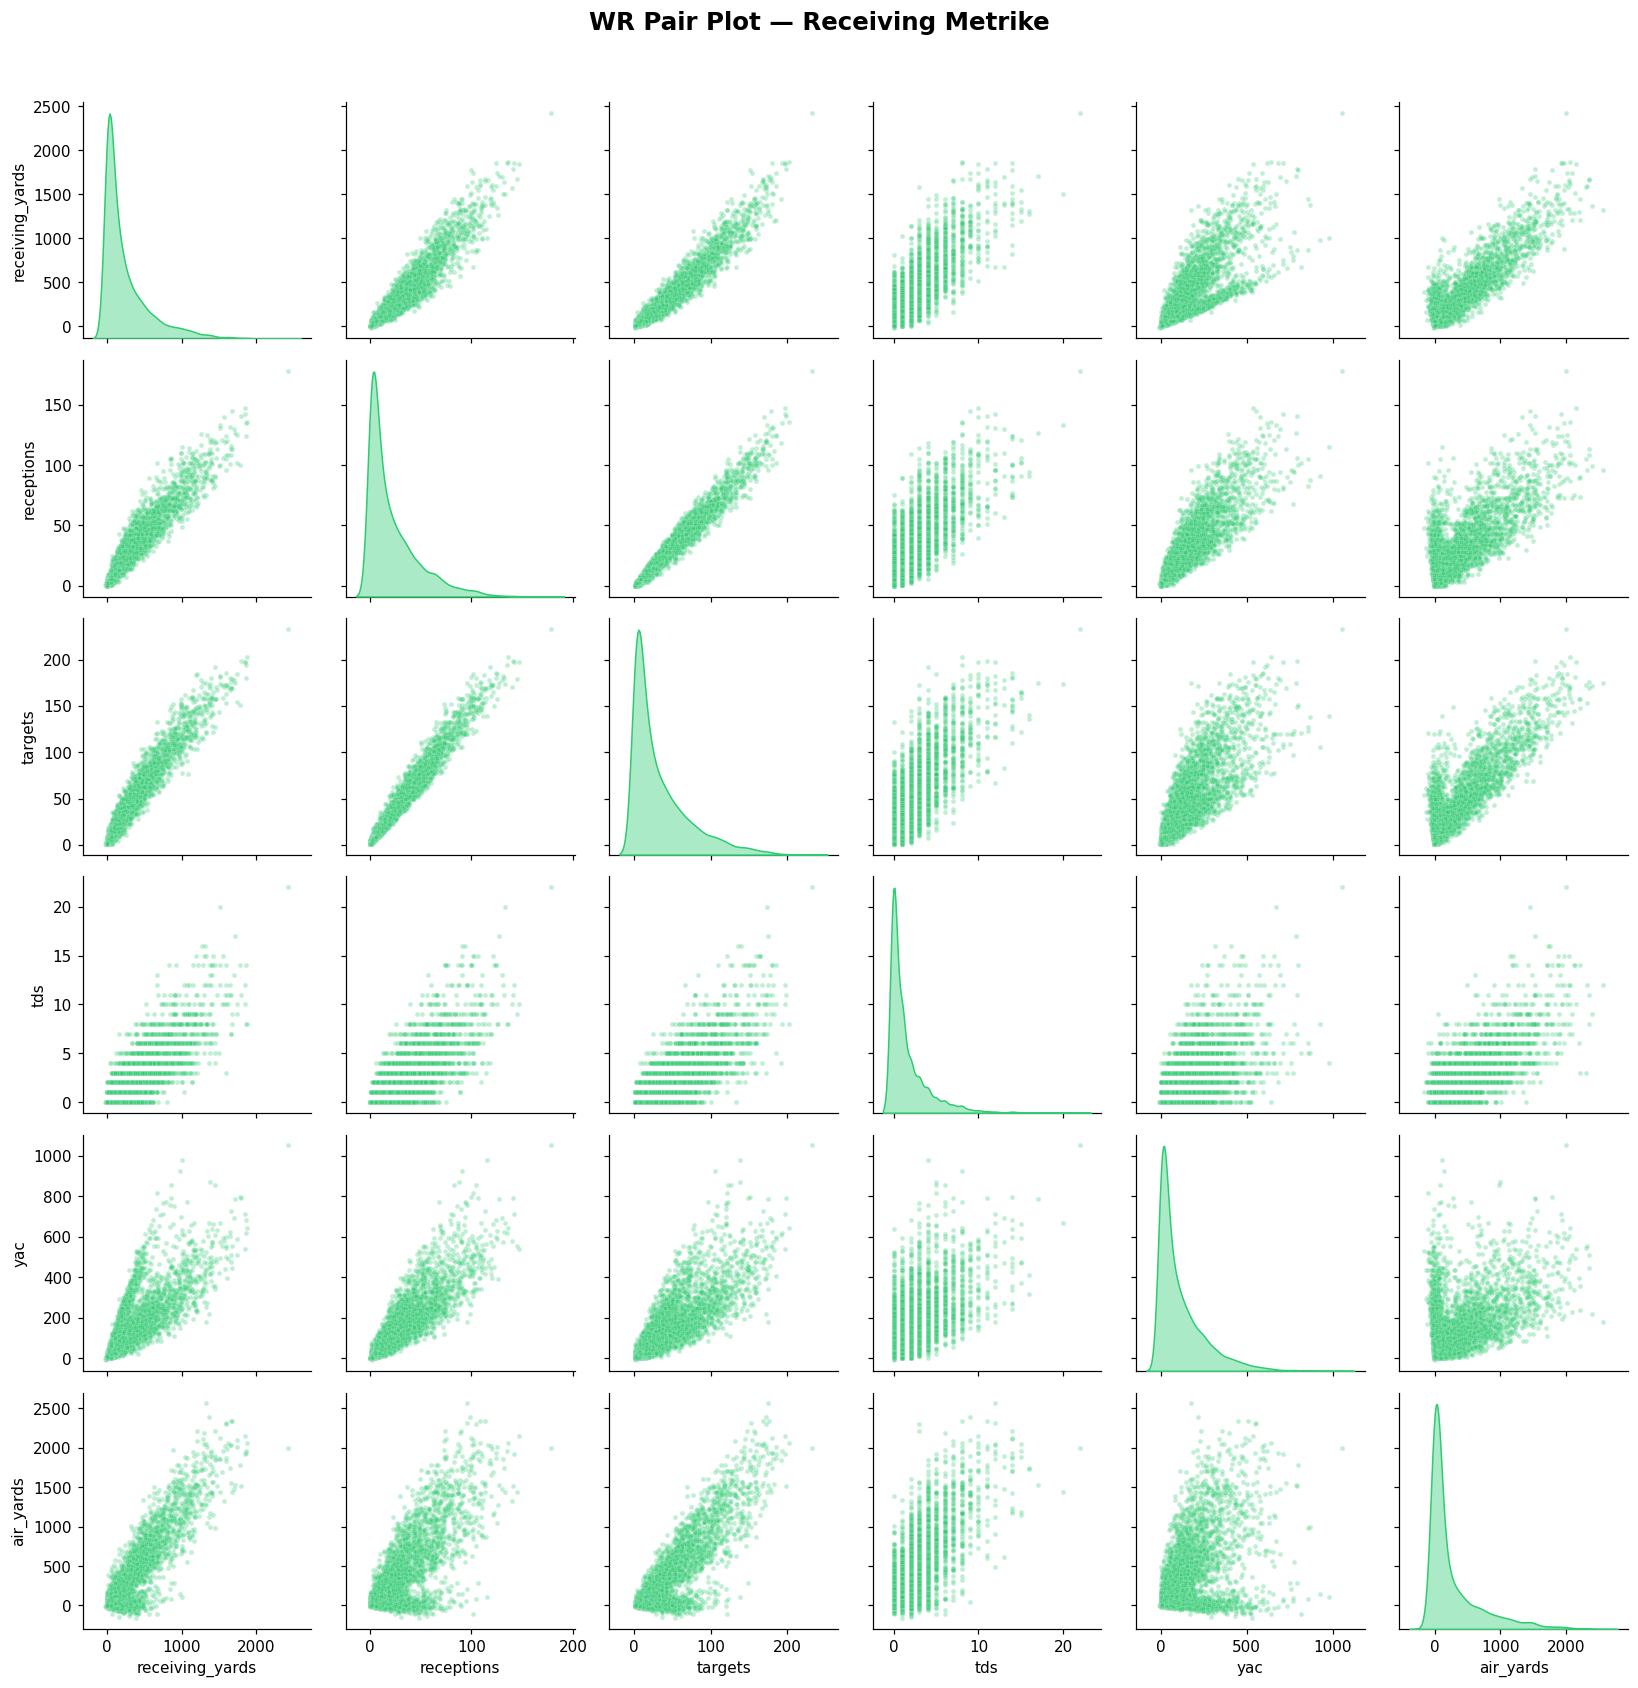

In [27]:
plot_wr_pairplot(wr_seasons)

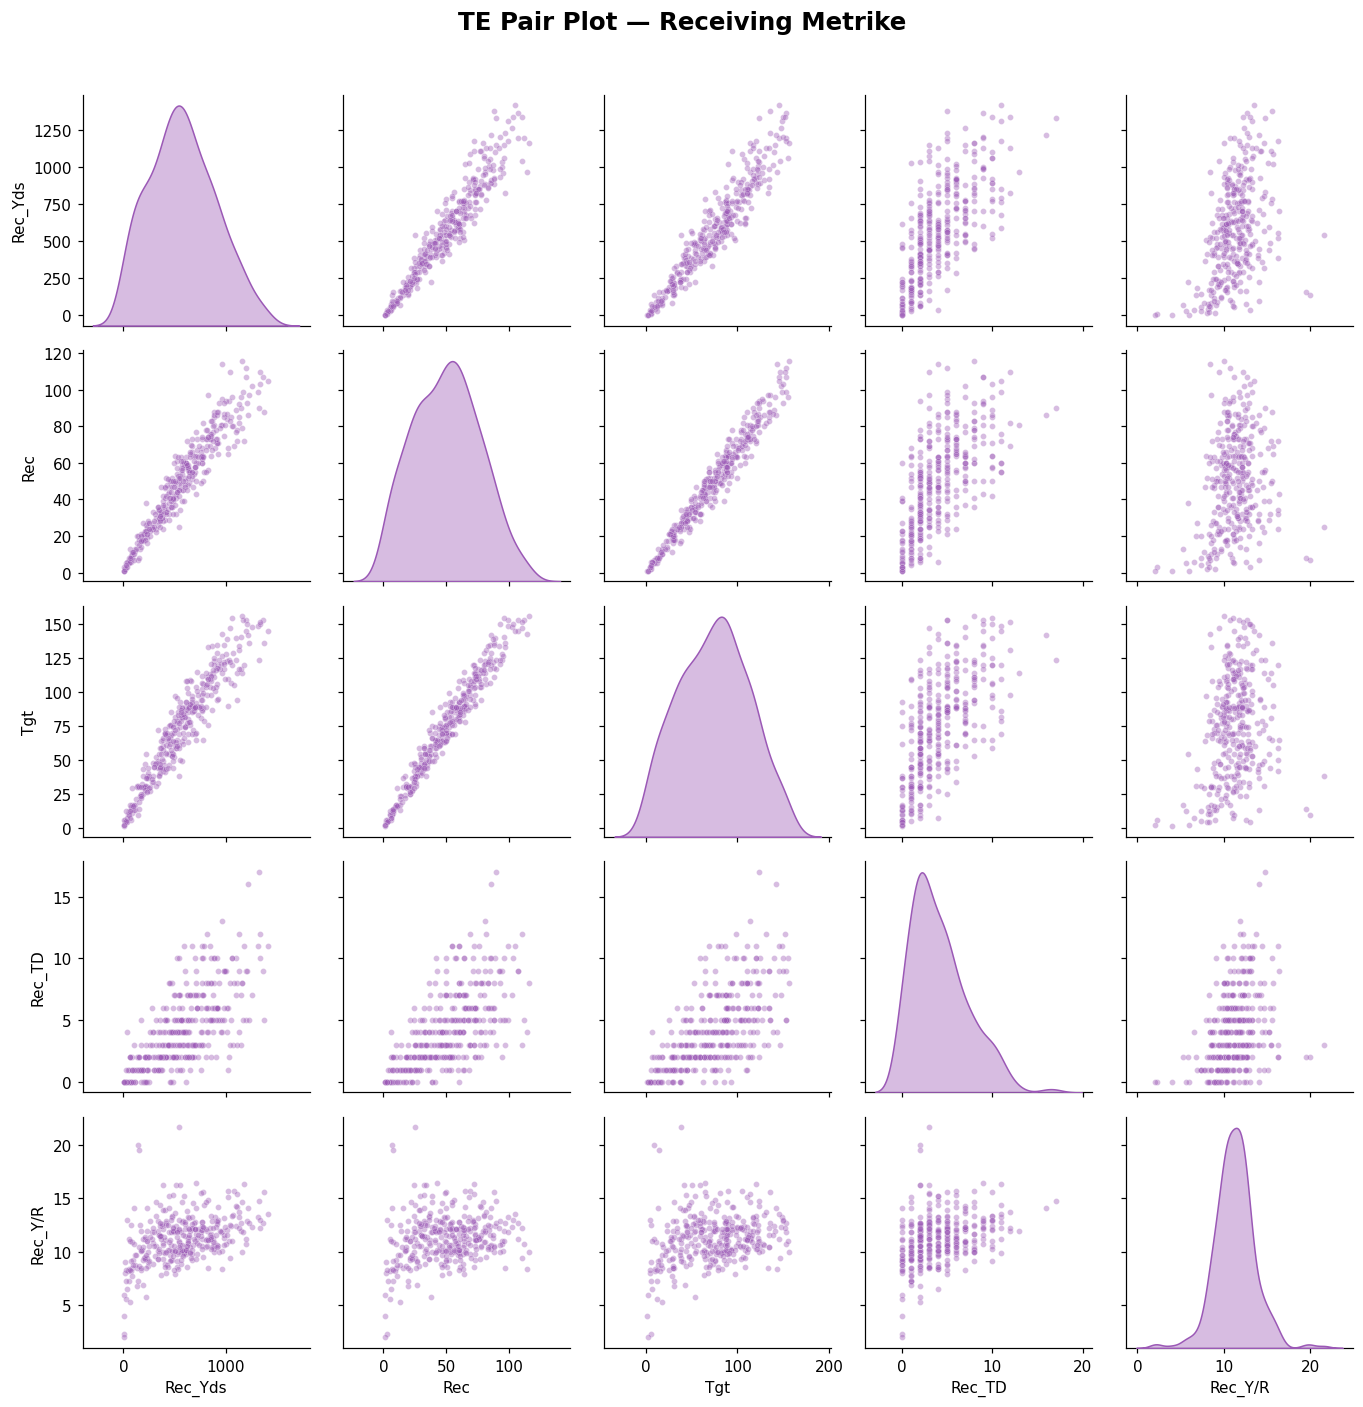

In [28]:
plot_te_pairplot(te)

---
## Trendovi po sezonama


Sledi analiza passing i rushing yardi kroz sezone preko box plota i line plota

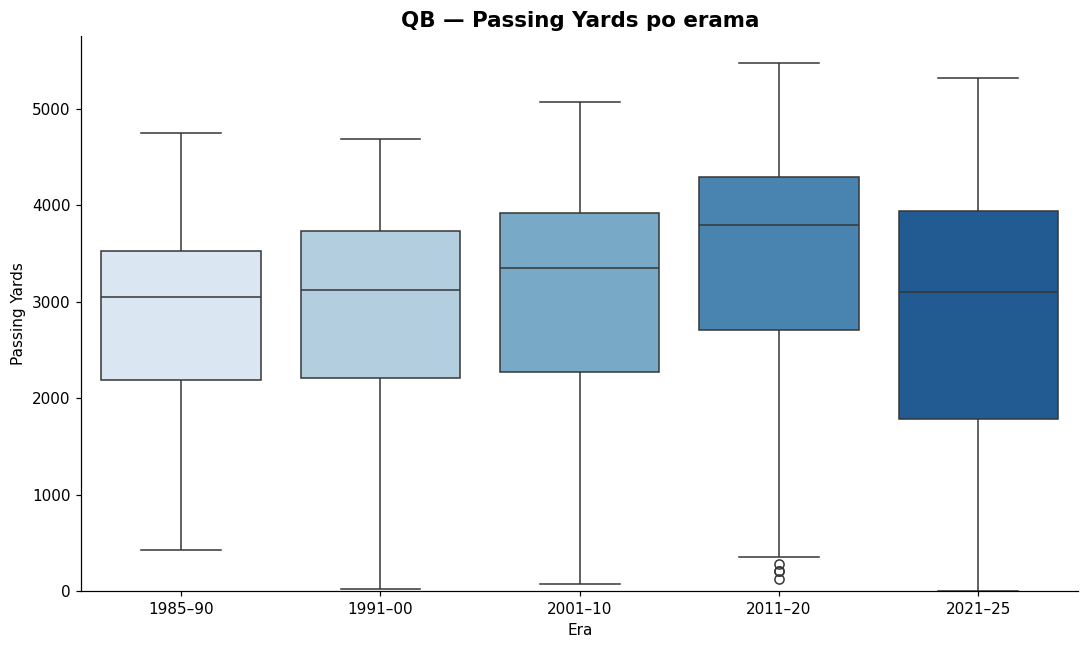

In [29]:
plot_qb_yards_by_era(qb)

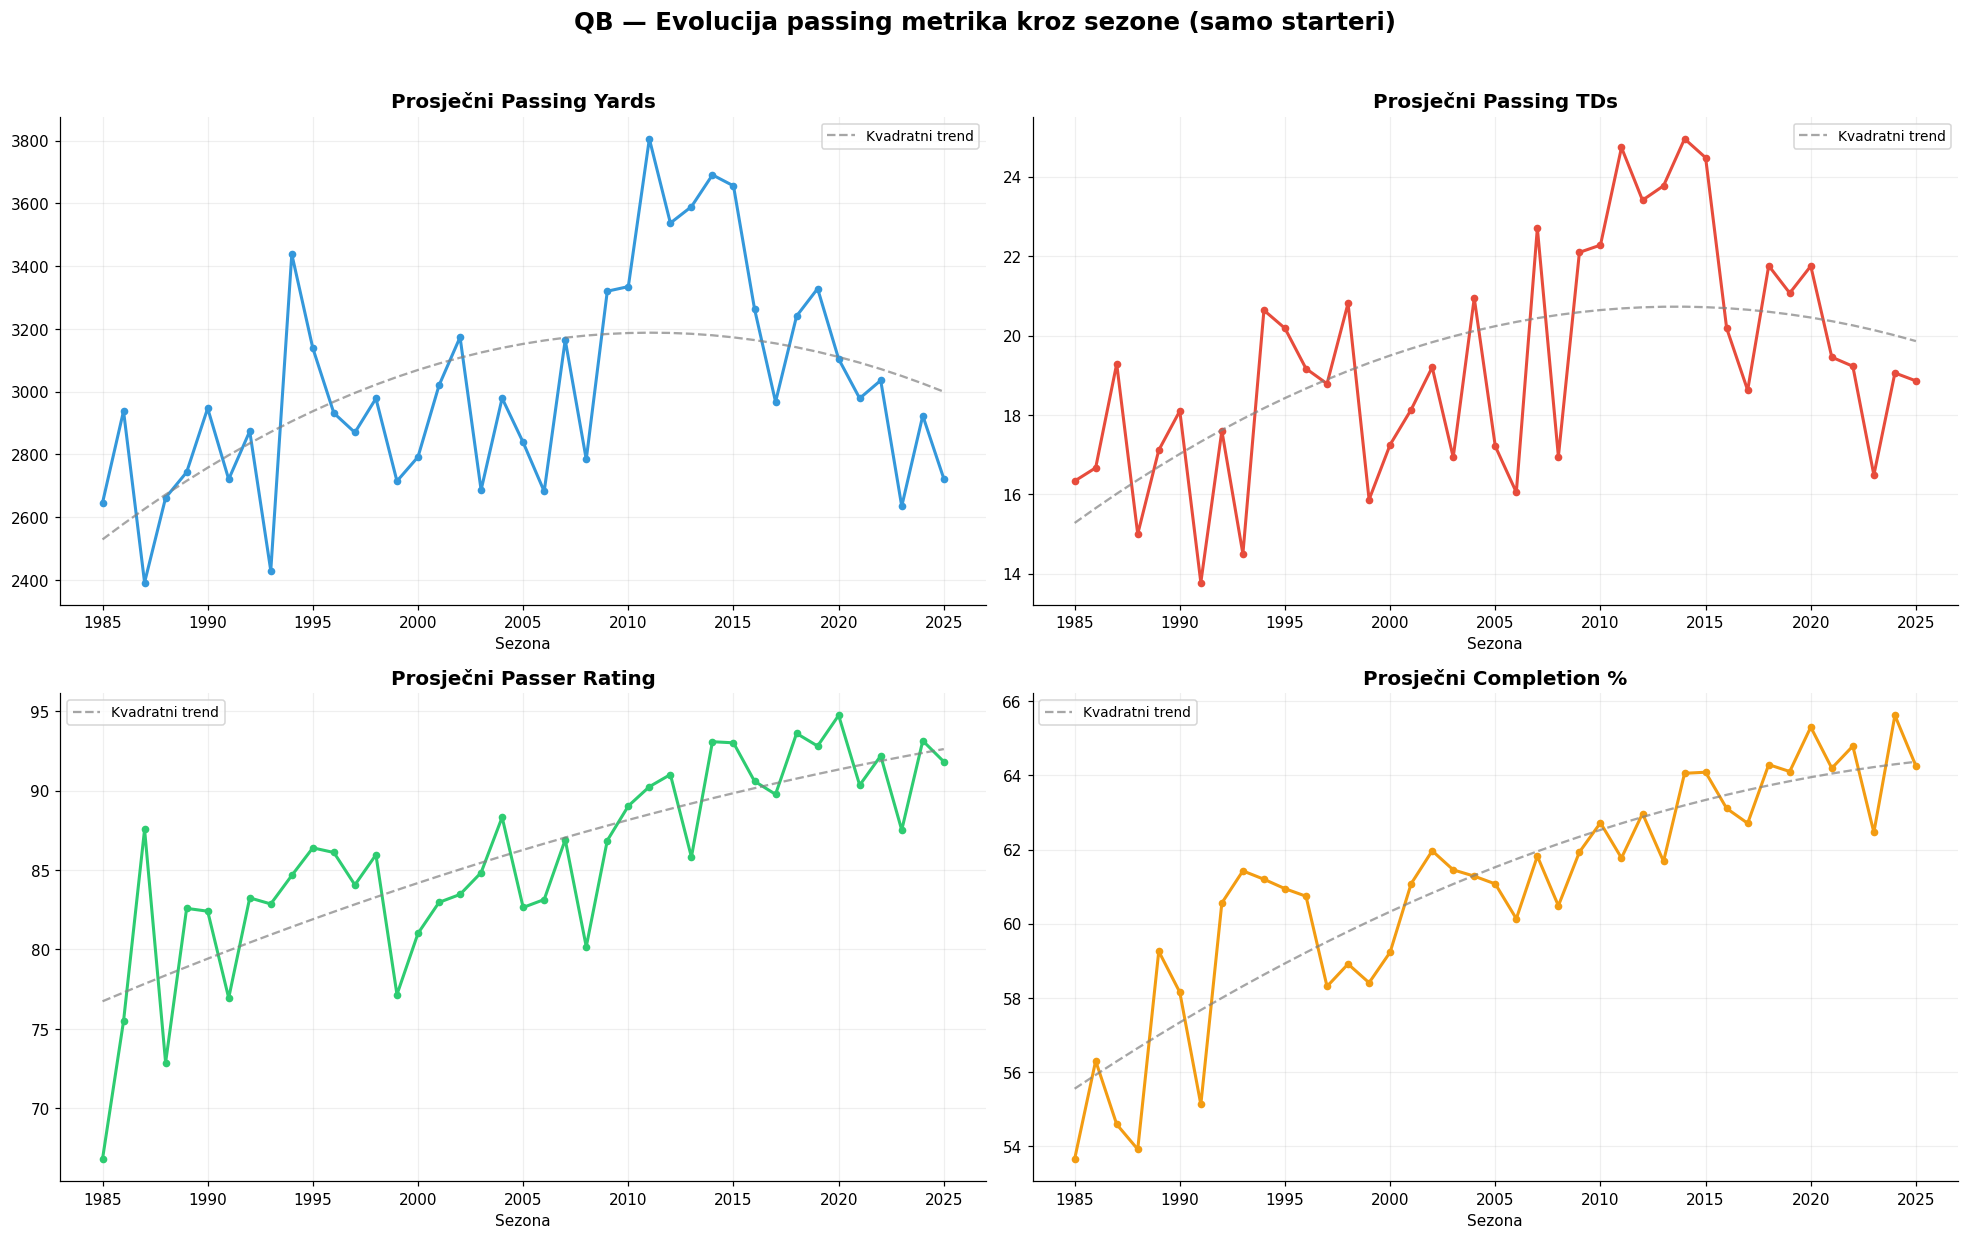

In [30]:
plot_qb_passing_trends(qb)

**QB (Passing Yards)**
- Passing igra pokazuje konstantan rast kroz decenije. NFL pravila sve više favorizuju passing ofanzivu (zaštita QB-a, ograničenja na kontakt sa receiverima), što se direktno odražava na rast prosečnih passing jardi.
- Boxplot po erama jasno pokazuje pomak medijana passing jardi naviše: od ~3000 Yds u eri 1985–90 do ~3500+ Yds u eri 2011–20. Kvadratni trend na Yds, TD, Rate i Cmp% pokazuje ubrzanje rasta nakon 2010., što se poklapa sa uvođenjem strožih pravila o kontaktu sa receiverima.
- Od 2021. godine primećuje se blago smanjenje prosečnih passing jardi i TD, uz istovremeni rast Completion% i passer ratinga. Verovatno objašnjenje je adaptacija odbrana - sve češće korišćenje two-high safety šema i fokus na limitiranje dubokih pasova, čime se smanjuje eksplozivnost passing igre. Kako je passing postao znatno produktivniji od run game-a, odbrane su strateški preusmerile resurse na njegovo zaustavljanje. Istovremeno, povećanje prosečne startne pozicije napada (bolji field position) može doprineti kraćim napadačkim sekvencama i manjim ukupnim yardama.

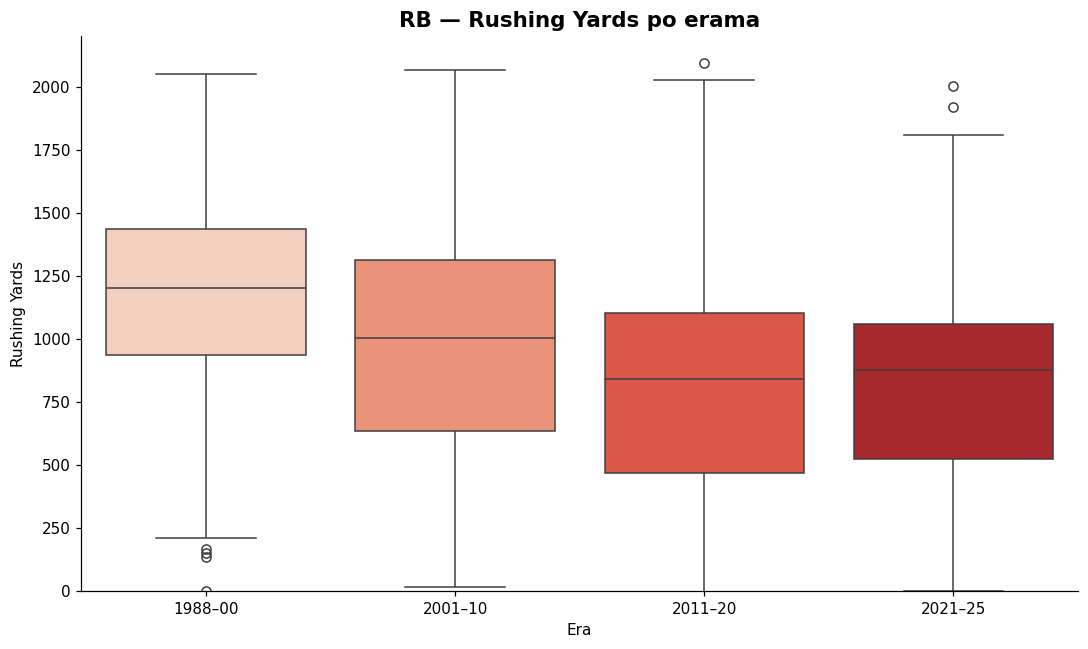

In [31]:
plot_rb_yards_by_era(rb)

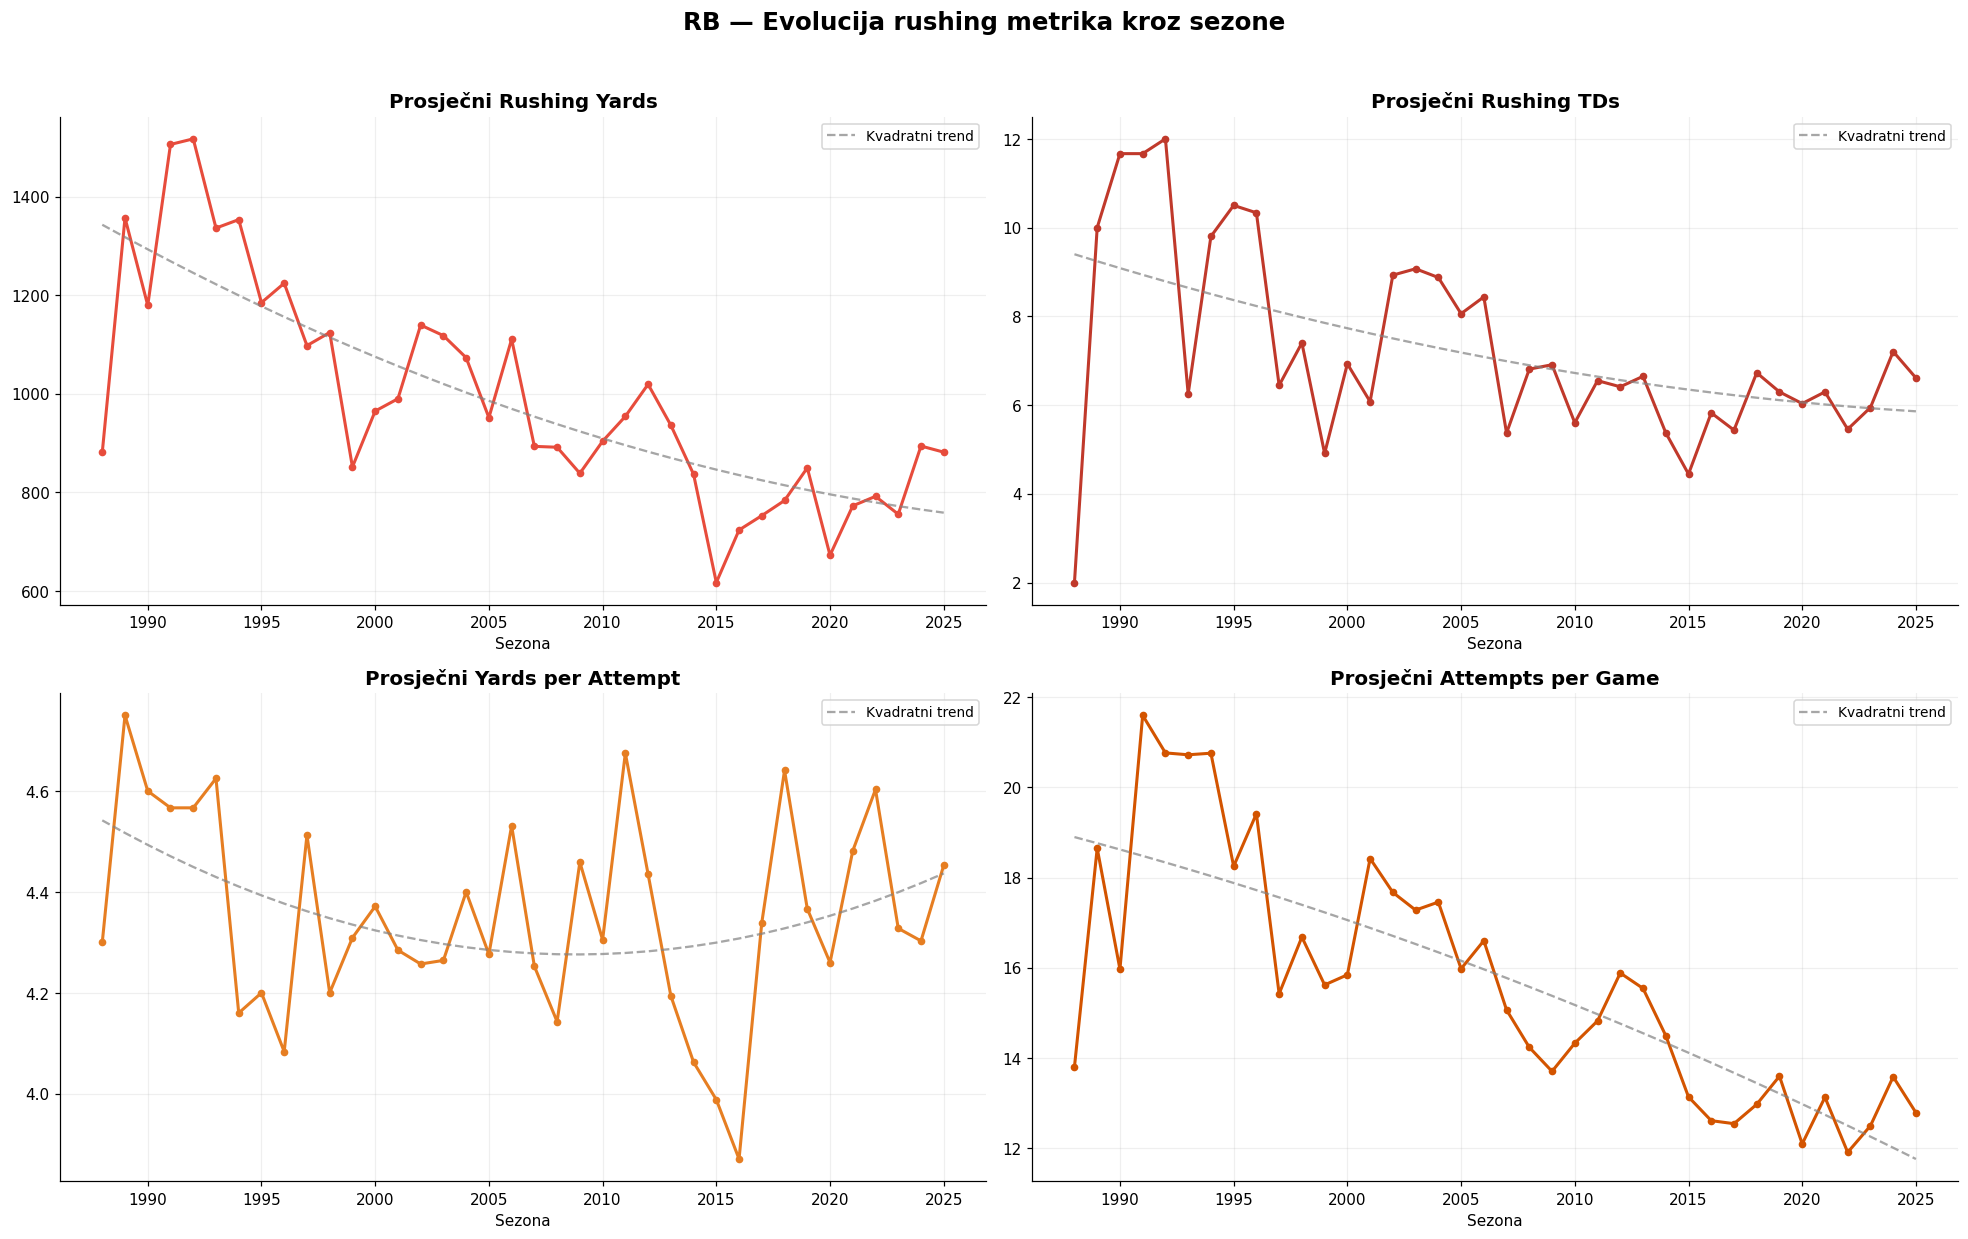

In [32]:
plot_rb_rushing_trends(rb)

**RB (Rushing Yards)**
- Kod RB pozicije primetan je gotovo konstantan pad rushing jardi kroz ere, što je posledica istorijskog prelaska sa run-orijentisane na pass-orijentisanu ofanzivu. Kako je passing igra postajala dominantna, uloga klasičnog RB-a u generisanju velikih yardi se smanjivala.

- U poslednjih nekoliko godina primećuje se blag rast rushing jardi, što se može povezati sa fokusom odbrana na zaustavljanje passing igre. Veći broj two-high šema i pokrivanja protiv pasa otvara više prostora za run game, što dovodi do blagog oporavka rushing produkcije.

---
## Najbolje pojedinačne sezone po yardima

Ovde je prikazan horizontalni bar chart za Top 10 sezona svake pozicije - samo regular season statistika (bez playoffa).

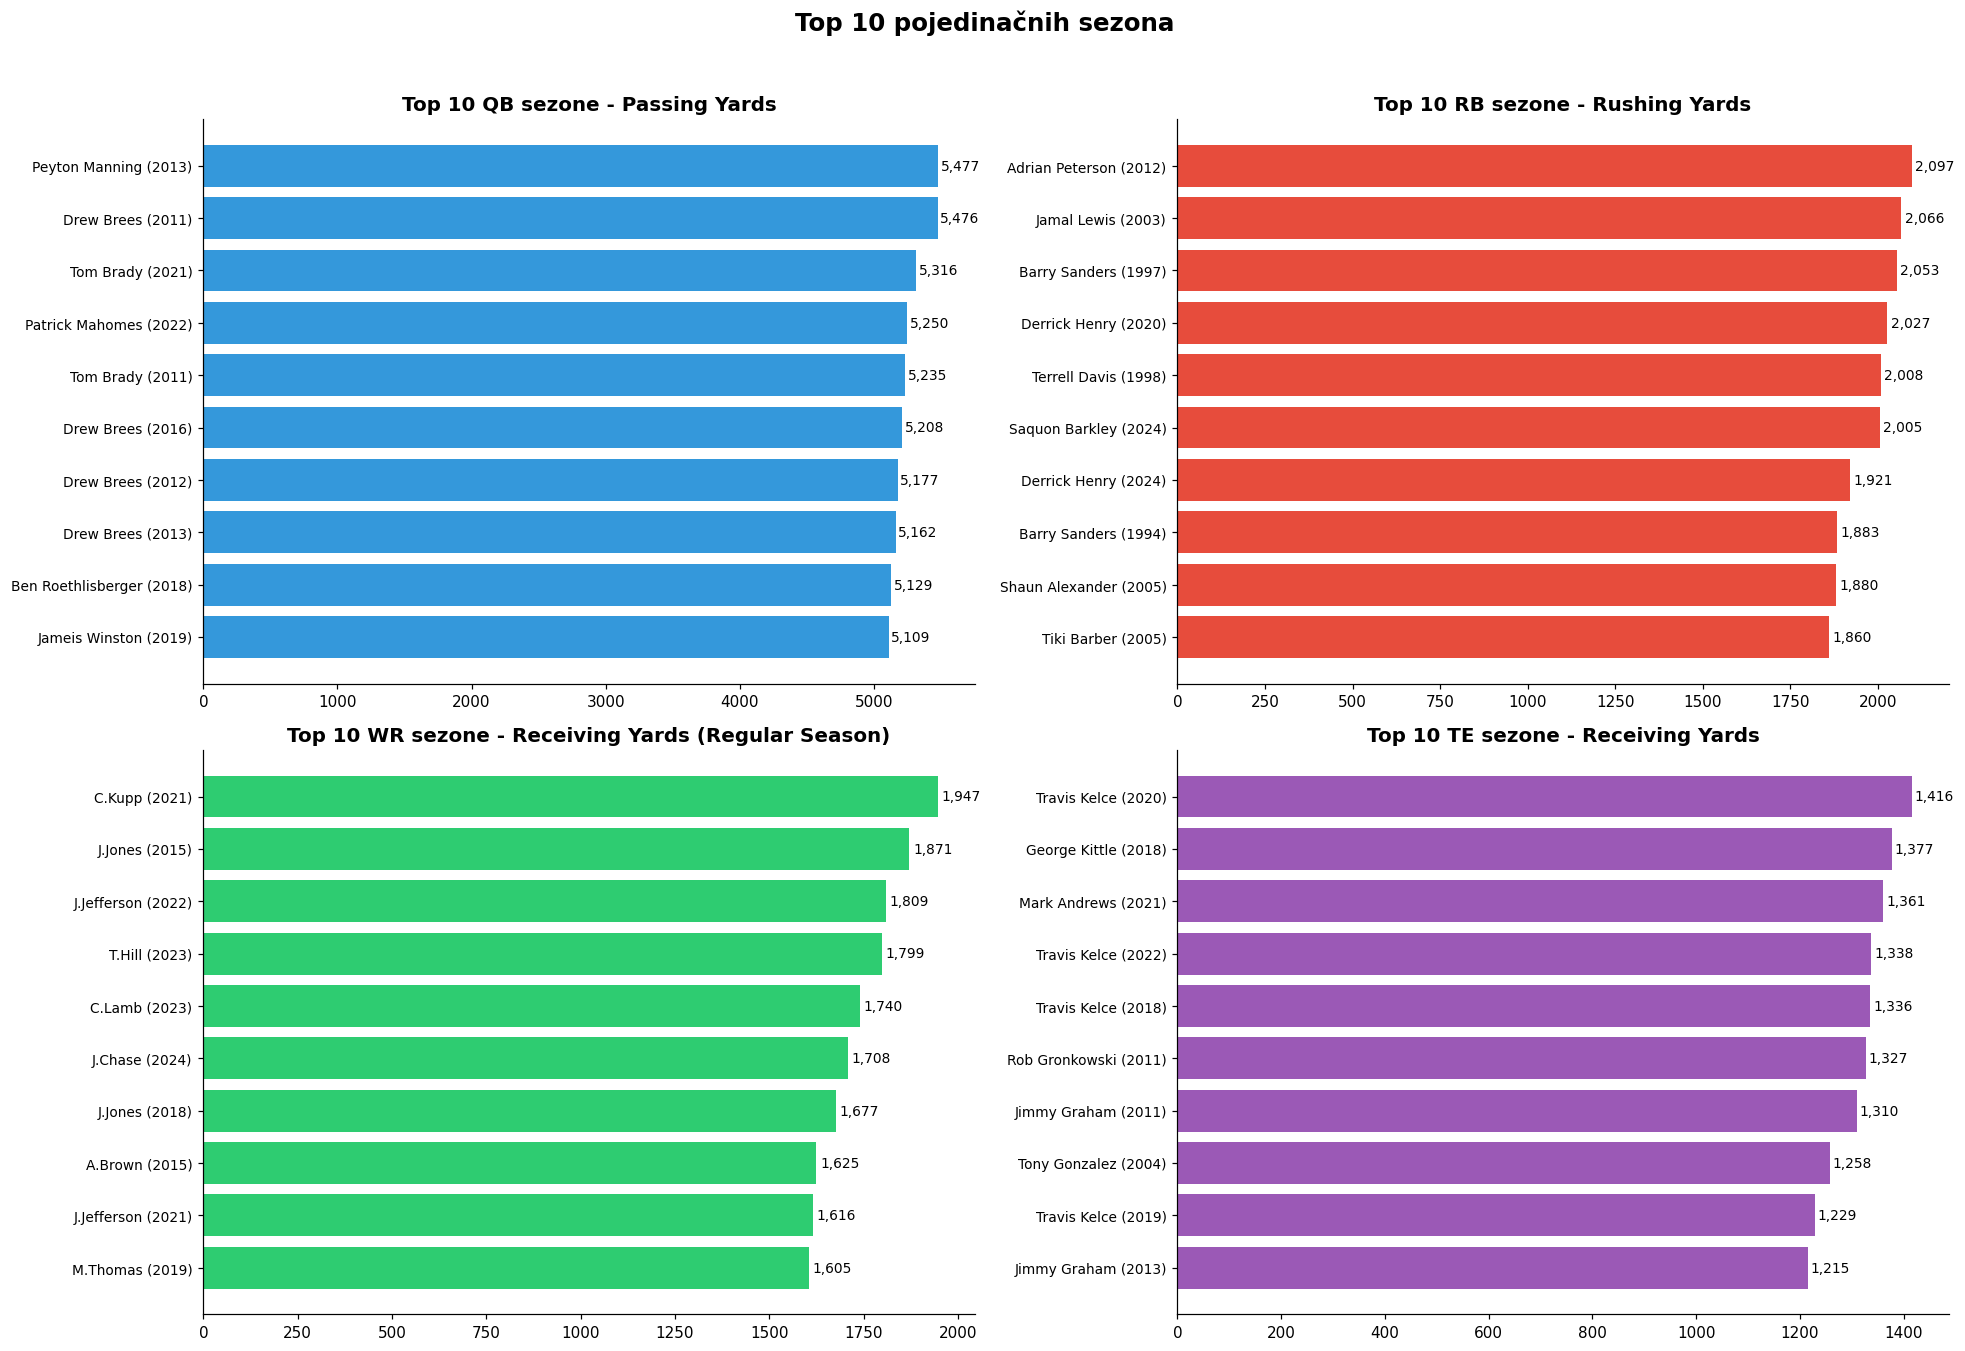

In [33]:
plot_top10_seasons(qb, rb, te, wr_seasons)
wr_seasons = datasets["WR (wr_all_seasons)"]

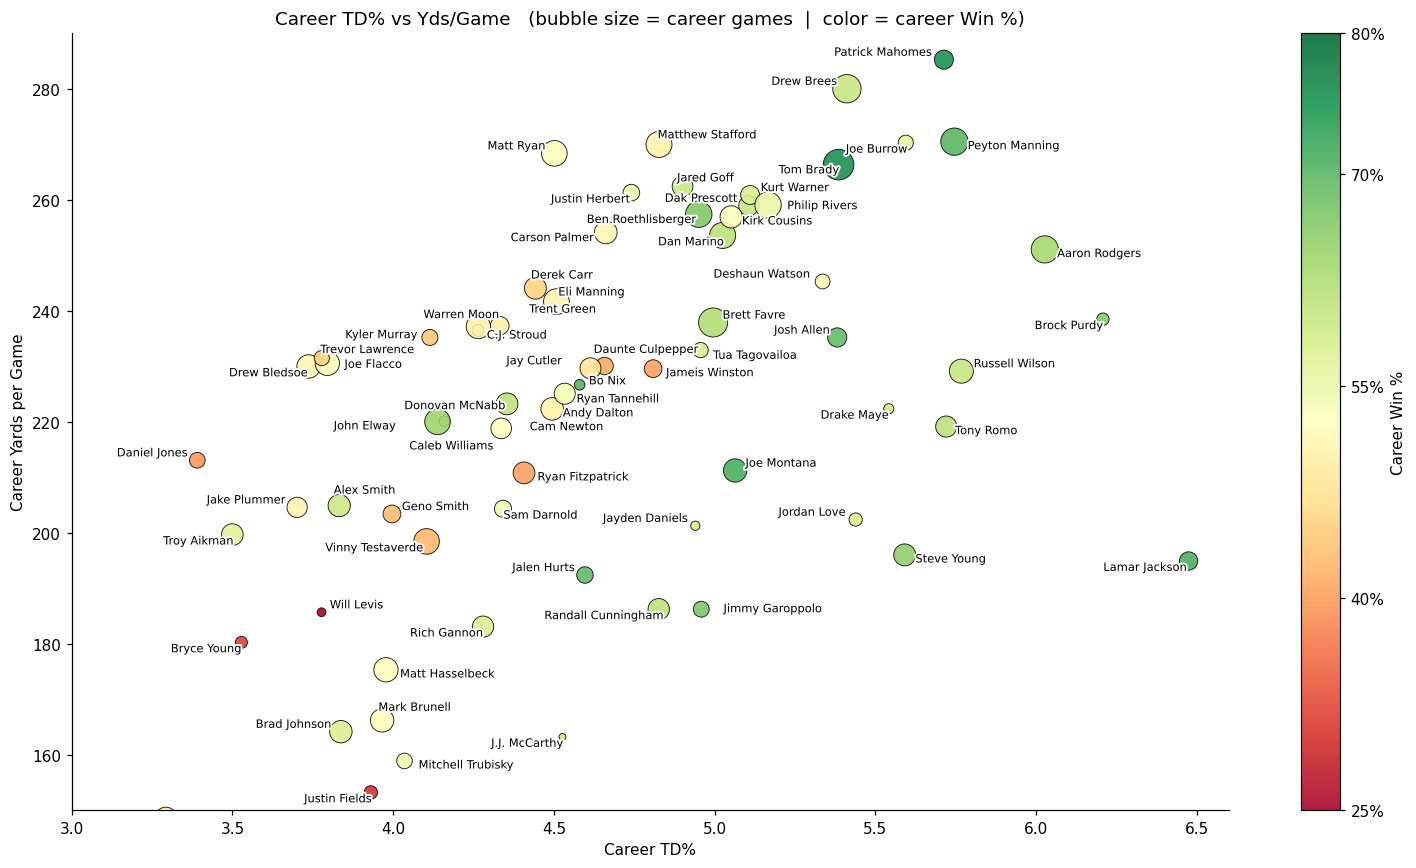

In [34]:
plot_qb_career_scatter(qb)

---
## Analiza kroz godine za pojedinca

### QB – Passing Yards kroz sezone

Pratimo razvoj tri quarterbacka kroz karijeru: Tom Brady, Matthew Stafford i Kirk Cousins.

Graf prikazuje ukupne passing yarde po sezoni za svakog od trojice igrača.

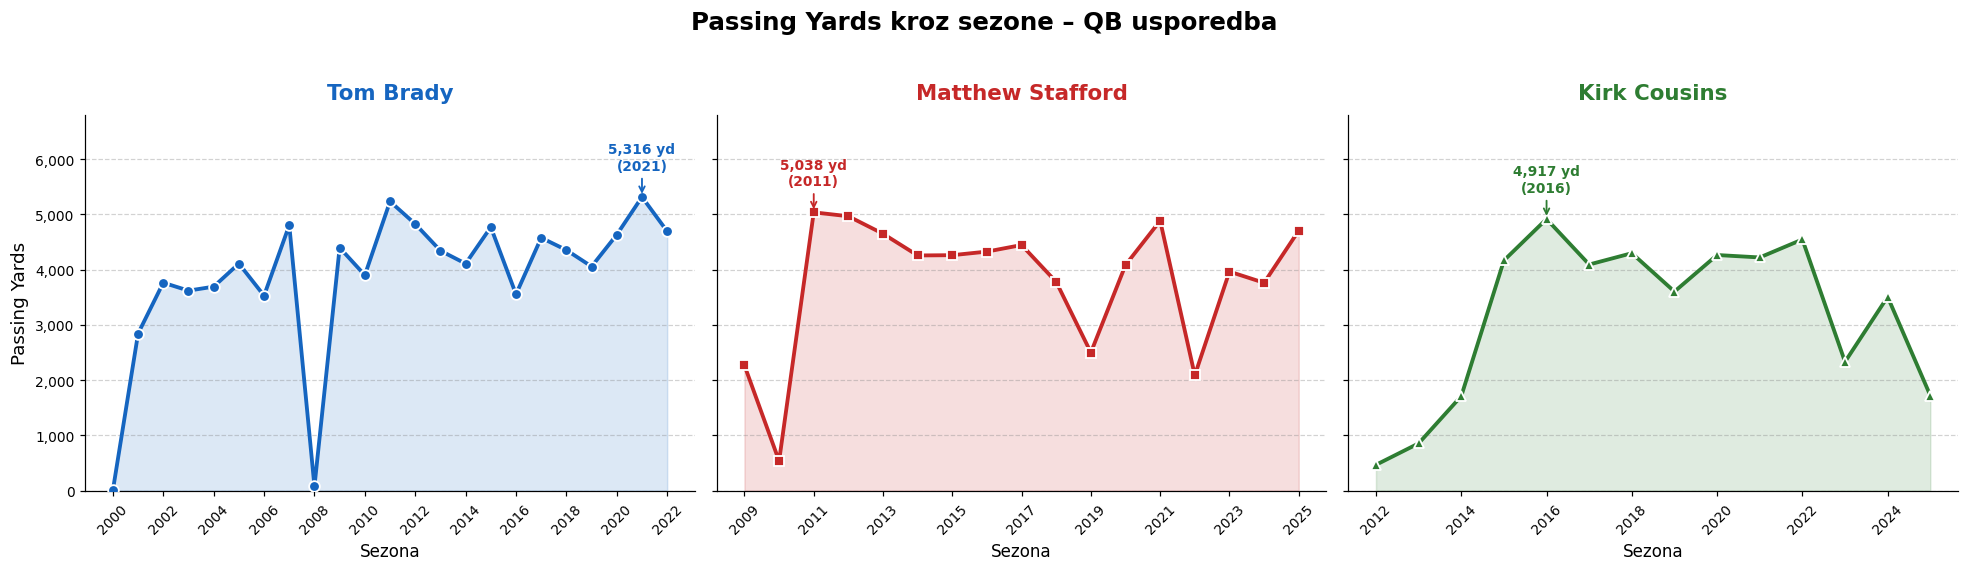

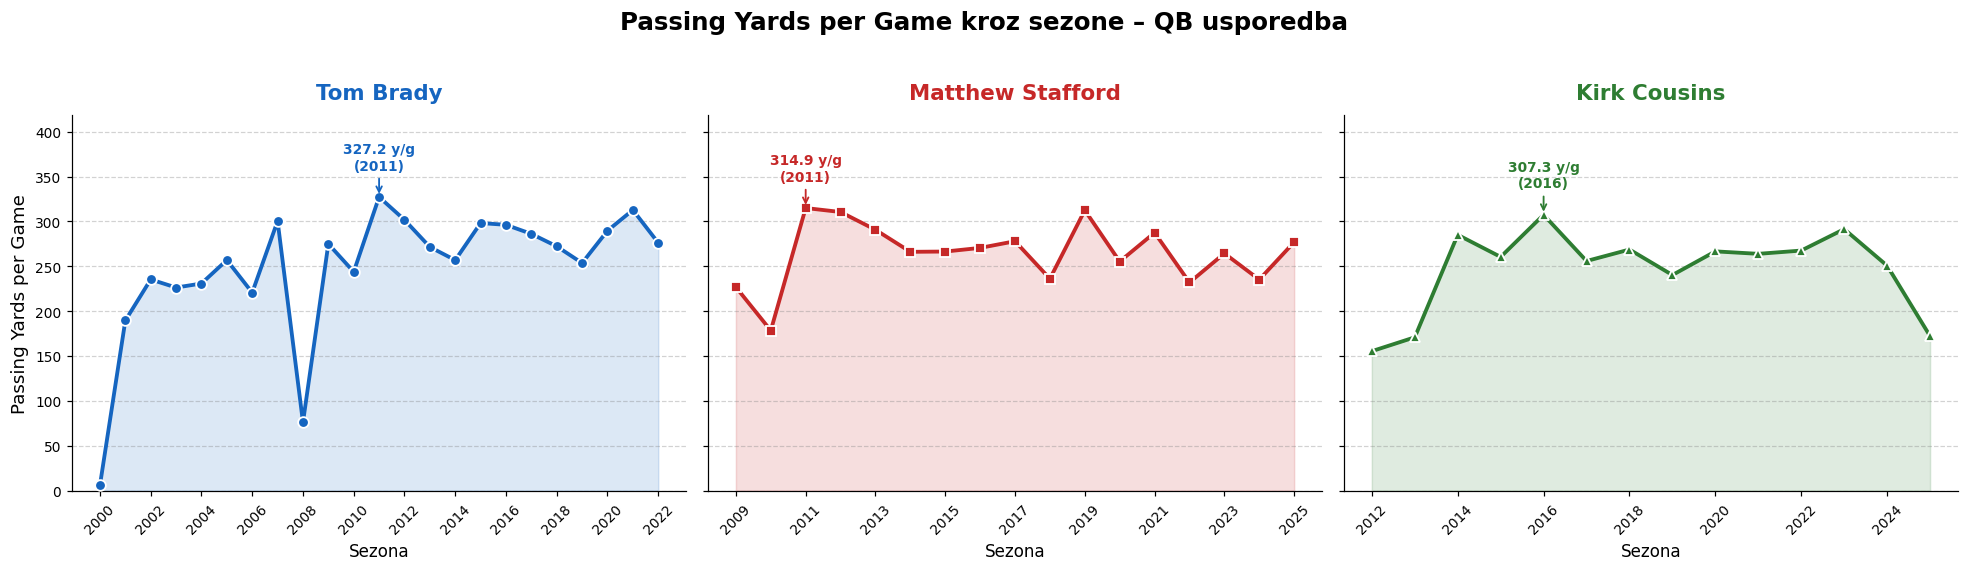

In [35]:
players = ['Tom Brady', 'Matthew Stafford', 'Kirk Cousins']
colors  = {'Tom Brady': '#1565C0', 'Matthew Stafford': '#C62828', 'Kirk Cousins': '#2E7D32'}

plot_qb_career_yards(players, colors)
plot_qb_career_yards_per_game(players, colors)


### Uticaj povreda na QB produkciju:

Ukupna statistika u sezoni često može zavarati jer ne pravi razliku između loše igre i vremena provedenog van terena. Najbolji primer je Tom Brady 2008. godine; nakon teške povrede kolena u prvom kolu, sezonu je završio sa samo 76 jardi. To nije bio odraz pada njegovog kvaliteta, već činjenice da fizički nije bio na terenu.

Slične situacije videli smo kod igrača kao što su Matthew Stafford i Kirk Cousins. Kada solidan kvoterbek propusti polovinu utakmica zbog povrede, na tabeli ukupnih jardi preteći će ga čak i prosečni igrači koji su samo ostali zdravi. Povrede su nepredvidive i drastično "skraćuju" produkciju na papiru, iako igrač možda igra na vrhunskom nivou dok je zdrav.

Ova vizuelizacija je još jedna potvrda naše odluke da yards per game bude naša ciljna varijabla.

### RB – Rushing Yards kroz sezone
 
Pratimo tri running backa i njihove sezonske rushing yarde: Adrian Peterson, Alvin Kamara i Saquon Barkley.

Graf prikazuje ukupne rushing yarde po sezoni za svakog od trojice igrača.

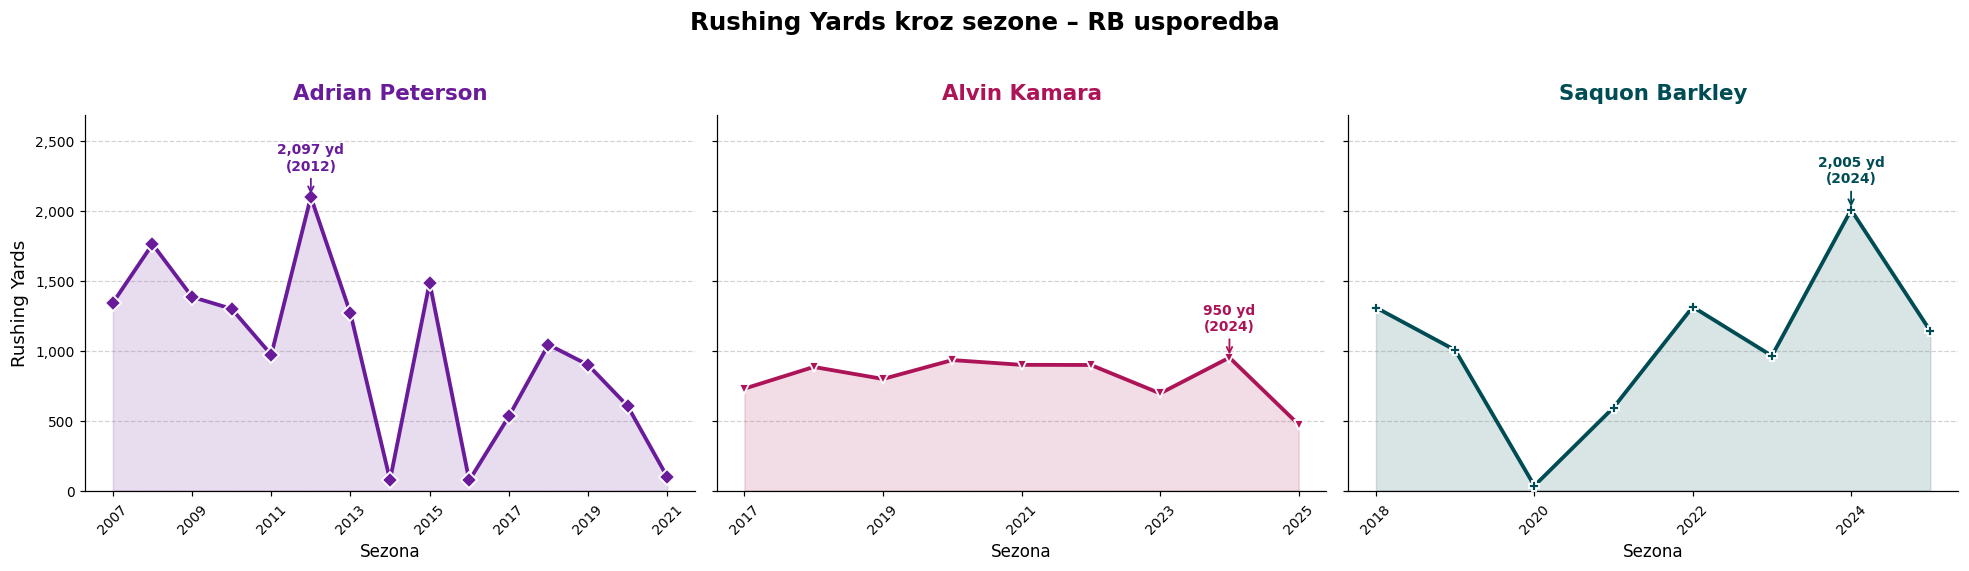

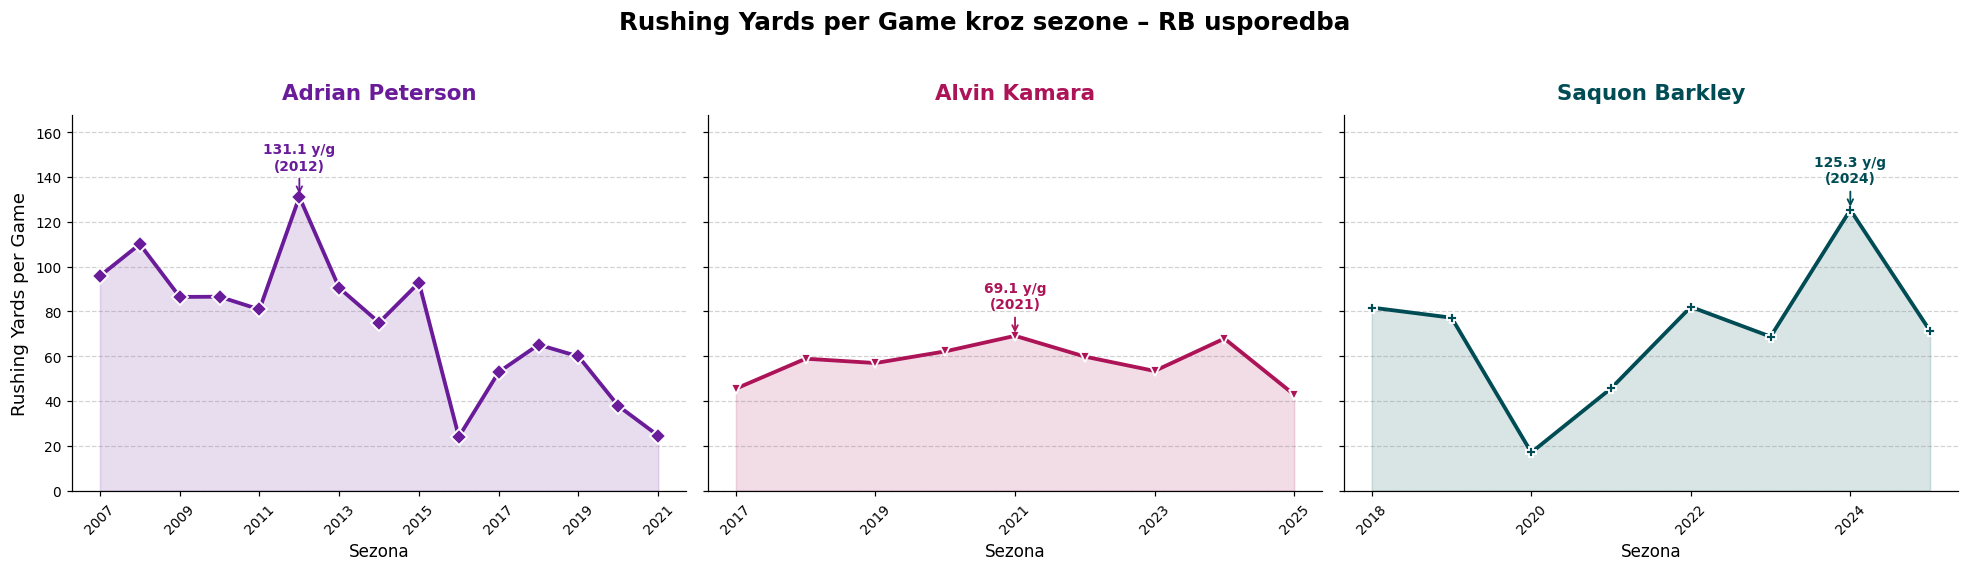

In [36]:
players = ['Adrian Peterson', 'Alvin Kamara', 'Saquon Barkley']
colors  = {'Adrian Peterson': '#6A1B9A', 'Alvin Kamara': '#AD1457', 'Saquon Barkley': '#004C54'}

plot_rb_career_yards(players, colors)
plot_rb_career_yards_per_game(players, colors)


**Uticaj povreda na RB produkciju:**

Kod running backova su povrede još kritičniji faktor nego kod QB-jeva. Drastični padovi u produkciji, poput onih kod Barkleya (2020) ili Petersona (2014), nisu posledica loše igre, već fizičkog odsustva sa terena. Takve "rupe" u podacima model teško može objasniti bez konteksta povreda.

Suprotan primer je Alvin Kamara, čija karijera bez težih povreda pokazuje konstantan i predvidiv put. Njegova statistika nema nagle padove, što je idealno za precizne predikcije.

### Uticaj promene tima na produkciju

Još jedna stvar koja je primetna su nagle promene u performansama nakom promene tima.

#### Tom Brady – Patriots vs. Buccaneers

Tom Brady je proveo 20 sezona u New England Patriotsima pre nego što je 2020. prešao u Tampa Bay Buccaneerse. Grafik ispod prikazuje njegovu produkciju u poslednjim sezonama sa Patriotsima u poređenju sa sezonama u Tampi.

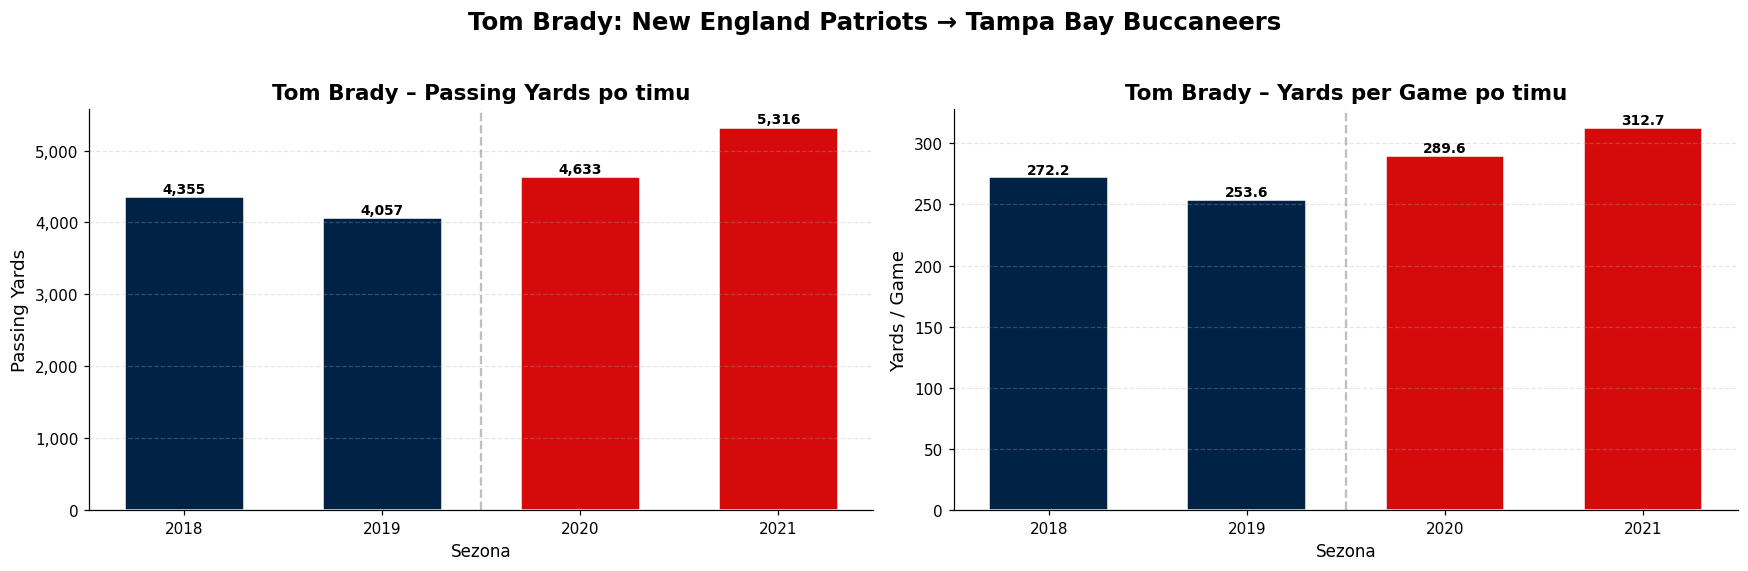

In [37]:
plot_qb_team_comparison(
    player='Tom Brady',
    team_a='NWE', team_b='TAM',
    season_from=2018, season_to=2021,
    colors={'NWE': '#002244', 'TAM': '#D50A0A'},
    title='Tom Brady: New England Patriots → Tampa Bay Buccaneers',
)

Promena sredine često predstavlja ključni faktor za restart ili uspon karijere. Brady-jeva produkcija je doživela značajan skok prelaskom iz New England-a u Tampa Bay. Okružen boljim ofanzivnim arsenalom i modernijim sistemom, Brady je u novom timu beležio drastično veći broj jardi nego u svojim poslednjim sezonama u Patriotsima.

#### Saquon Barkley – Giants vs. Eagles



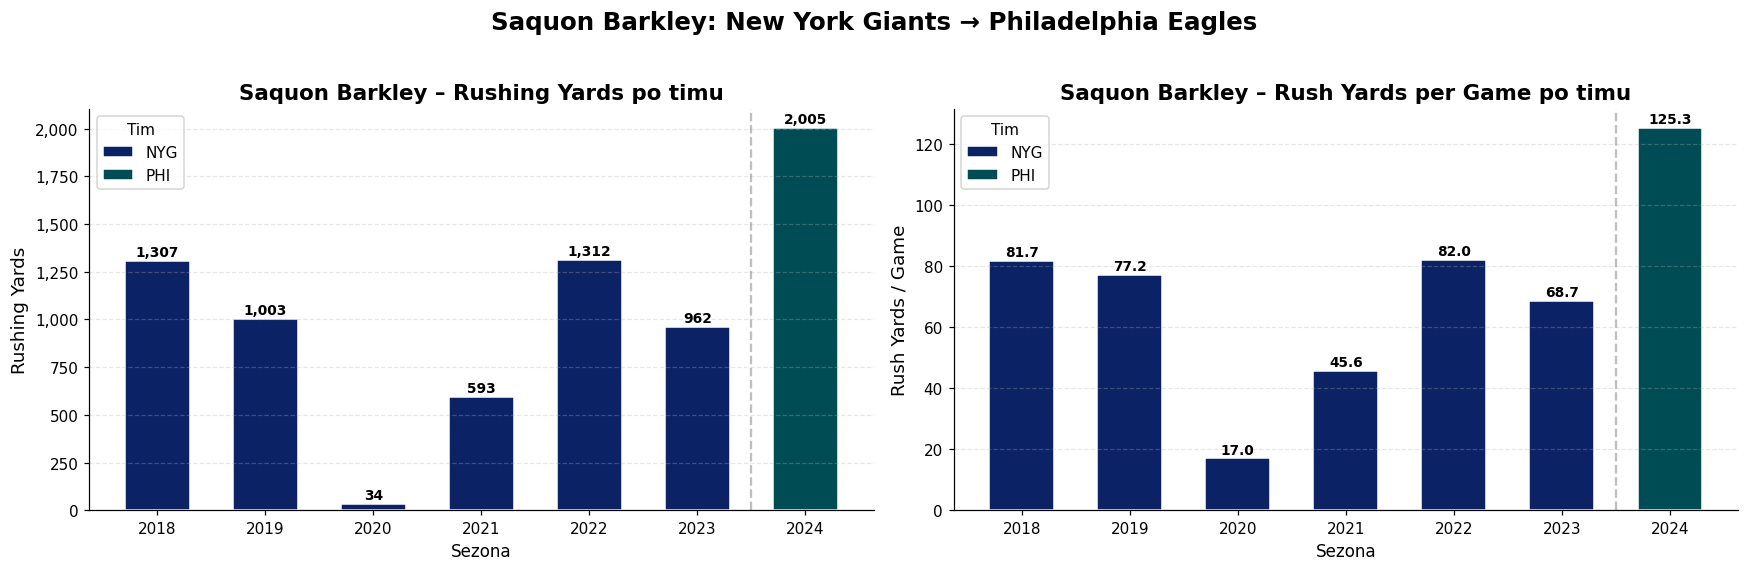

In [38]:
plot_rb_team_comparison(
    player='Saquon Barkley',
    team_a='NYG', team_b='PHI',
    season_from=2018, season_to=2024,
    colors={'NYG': '#0B2265', 'PHI': '#004C54'},
    title='Saquon Barkley: New York Giants → Philadelphia Eagles',
)

Saquon Barkley je proveo 6 sezona u New York Giantsima (2018–2023), gde je uprkos talentima bio ograničen lošom ofanzivnom linijom i povredama. Nakon prelaska u Philadelphia Eagles 2024. on eksplodirao sa 2,005 rushing jardi - najboljom sezonom u karijeri.

### Zakljucak za modelovanje

Upravo zbog ovakvih situacija je odlučeno da se doda kolona Team_Changed, boolean kolona koja ima vrednost 1 ako je igrač promenio tim bas te sezone. Ova kolona pomaže modelu da prepozna situacije gde statistički skok nije slučajan, već je rezultat kvalitetnijeg okruženja i boljeg uklapanja u novi sistem igre.